# METABRIC Survival Analysis with an Edge-Aware Graph Attention Network

This leakage-resistant Kaggle notebook builds a **research prototype for survival-risk stratification**. Patients are graph nodes; edges encode hybrid clinical, transcriptomic, and pathway similarity. The model outputs an unbounded Cox risk score: larger values indicate higher estimated hazard.

## 1. Optional dependency installation
The cell installs missing survival and graph packages. Failures are reported explicitly.

## 2. Imports and environment

In [ ]:
# ============================================================
# 2. Robust CUDA / CPU device selection
# ============================================================

def get_compatible_device() -> torch.device:
    """
    Select CUDA only when it is genuinely usable by the current
    PyTorch build and GPU.

    The function checks:
    1. CUDA availability;
    2. GPU name and compute capability;
    3. architectures embedded in the PyTorch build;
    4. execution of a real CUDA matrix operation.

    Any failure causes a safe fallback to CPU.
    """
    cpu_device = torch.device("cpu")

    if not torch.cuda.is_available():
        print("[DEVICE] CUDA is not available. Using CPU.")
        return cpu_device

    try:
        cuda_device = torch.device("cuda:0")

        gpu_name = torch.cuda.get_device_name(0)
        compute_capability = torch.cuda.get_device_capability(0)
        major, minor = compute_capability
        required_architecture = f"sm_{major}{minor}"

        try:
            supported_architectures = list(torch.cuda.get_arch_list())
        except Exception as exc:
            supported_architectures = []
            print(
                "[DEVICE WARNING] Could not read torch CUDA architecture list:",
                repr(exc),
            )

        print("\n" + "=" * 70)
        print("CUDA COMPATIBILITY CHECK")
        print("=" * 70)
        print("Detected GPU:", gpu_name)
        print("GPU compute capability:", f"{major}.{minor}")
        print("Required CUDA architecture:", required_architecture)
        print(
            "Architectures included in PyTorch:",
            supported_architectures if supported_architectures else "unknown",
        )

        architecture_reported_as_supported = (
            not supported_architectures
            or required_architecture in supported_architectures
        )

        if not architecture_reported_as_supported:
            print(
                "[DEVICE WARNING] The exact GPU architecture is not listed "
                "in torch.cuda.get_arch_list()."
            )
            print(
                "[DEVICE WARNING] A real CUDA operation will determine "
                "whether execution is nevertheless possible."
            )

        # A real matrix multiplication tests actual CUDA kernel execution.
        test_left = torch.randn(
            (32, 32),
            dtype=torch.float32,
            device=cuda_device,
        )
        test_right = torch.randn(
            (32, 32),
            dtype=torch.float32,
            device=cuda_device,
        )
        test_output = torch.matmul(test_left, test_right)

        if not torch.isfinite(test_output).all():
            raise RuntimeError(
                "The CUDA compatibility test produced non-finite values."
            )

        torch.cuda.synchronize(cuda_device)

        del test_left
        del test_right
        del test_output
        torch.cuda.empty_cache()

        print("[DEVICE] CUDA kernel execution test passed.")
        print(f"[DEVICE] Selected device: {cuda_device}")
        return cuda_device

    except Exception as exc:
        print("\n[DEVICE WARNING] CUDA cannot be used safely.")
        print("[DEVICE WARNING] Reason:", repr(exc))
        print("[DEVICE] Falling back to CPU.")

        try:
            gc.collect()
            torch.cuda.empty_cache()
        except Exception:
            pass

        return cpu_device


DEVICE = get_compatible_device()

CUDA_ENABLED = DEVICE.type == "cuda"
DEVICE_NAME = (
    torch.cuda.get_device_name(DEVICE.index or 0)
    if CUDA_ENABLED
    else "CPU"
)

print("\nSelected DEVICE:", DEVICE)
print("Selected device name:", DEVICE_NAME)
print("CUDA enabled:", CUDA_ENABLED)


CUDA COMPATIBILITY CHECK
Detected GPU: Tesla P100-PCIE-16GB
GPU compute capability: 6.0
Required CUDA architecture: sm_60
Architectures included in PyTorch: ['sm_70', 'sm_75', 'sm_80', 'sm_86', 'sm_90', 'sm_100', 'sm_120']
[DEVICE WARNING] The exact GPU architecture is not listed in torch.cuda.get_arch_list().
[DEVICE WARNING] A real CUDA operation will determine whether execution is nevertheless possible.

[DEVICE WARNING] CUDA cannot be used safely.
[DEVICE WARNING] Reason: AcceleratorError("CUDA error: no kernel image is available for execution on the device\nSearch for `cudaErrorNoKernelImageForDevice' in https://docs.nvidia.com/cuda/cuda-runtime-api/group__CUDART__TYPES.html for more information.\nCUDA kernel errors might be asynchronously reported at some other API call, so the stacktrace below might be incorrect.\nFor debugging consider passing CUDA_LAUNCH_BLOCKING=1\nCompile with `TORCH_USE_CUDA_DSA` to enable device-side assertions.\n")
[DEVICE] Falling back to CPU.

Selected

## 3. Central configuration

## 4. Reproducibility and versions

In [ ]:
# ============================================================
# 3. Global configuration, reproducibility and output folders
# ============================================================

CONFIG = {
    # --------------------------------------------------------
    # General
    # --------------------------------------------------------
    "seed": 42,
    "data_path": (
        "/kaggle/input/datasets/raghadalharbi/"
        "breast-cancer-gene-expression-profiles-metabric/"
        "METABRIC_RNA_Mutation.csv"
    ),
    "output_dir": "/kaggle/working/gat_survival_results",

    # Survival columns will be resolved after dataset inspection.
    "survival_time_column": None,
    "event_column": None,

    # --------------------------------------------------------
    # Validation
    # --------------------------------------------------------
    "cv_folds": 5,
    "validation_size_within_train": 0.20,

    # --------------------------------------------------------
    # Molecular feature selection
    # These remain fixed for the current pipeline.
    # Internal validation of K will be introduced when the
    # gene-selection cell is implemented.
    # --------------------------------------------------------
    "top_k_node_genes": 100,
    "top_k_graph_genes": 50,
    "top_k_mutations": 20,
    "minimum_mutation_frequency": 0.01,
    "maximum_mutation_frequency": 0.50,

    # --------------------------------------------------------
    # Expression representation
    # --------------------------------------------------------
    "expression_representation": "selected_genes",
    "pca_variance_threshold": 0.85,
    "max_pca_components": 80,

    # --------------------------------------------------------
    # Pathway features
    # --------------------------------------------------------
    "pathway_features_enabled": True,

    # --------------------------------------------------------
    # Current graph construction
    # The multi-view graph options will be added only when the
    # graph-construction cells are replaced.
    # --------------------------------------------------------
    "knn_neighbors": 12,
    "knn_graph_mode": "symmetric_union",
    "minimum_edge_similarity": -1.0,
    "alpha_clinical": 0.30,
    "alpha_expression": 0.45,
    "alpha_pathway": 0.25,

    # --------------------------------------------------------
    # Current SurvivalGAT architecture
    # --------------------------------------------------------
    "hidden_channels": 32,
    "gat_heads": 4,
    "dropout": 0.30,
    "initial_residual_scale": 0.10,

    # --------------------------------------------------------
    # Optimization
    # --------------------------------------------------------
    "learning_rate": 5e-4,
    "weight_decay": 1e-4,
    "max_epochs": 500,
    "cv_max_epochs": 350,
    "patience": 50,
    "gradient_clip_norm": 2.0,
    "checkpoint_metric": "c_index",

    # --------------------------------------------------------
    # Experiments and reporting
    # --------------------------------------------------------
    "run_cross_validation": True,
    "run_ablation_study": True,
    "print_every": 25,
    "stable_feature_frequency": 0.60,
    "risk_horizons_months": [60.0, 120.0],
}


def validate_config(config: Dict[str, Any]) -> None:
    """
    Validate configuration values before any expensive computation.

    This function validates only parameters already used by the current
    notebook. New configuration fields will be validated when their
    corresponding pipeline components are implemented.
    """
    required_keys = {
        "seed",
        "data_path",
        "output_dir",
        "cv_folds",
        "validation_size_within_train",
        "top_k_node_genes",
        "top_k_graph_genes",
        "top_k_mutations",
        "minimum_mutation_frequency",
        "maximum_mutation_frequency",
        "expression_representation",
        "pca_variance_threshold",
        "max_pca_components",
        "pathway_features_enabled",
        "knn_neighbors",
        "knn_graph_mode",
        "minimum_edge_similarity",
        "alpha_clinical",
        "alpha_expression",
        "alpha_pathway",
        "hidden_channels",
        "gat_heads",
        "dropout",
        "initial_residual_scale",
        "learning_rate",
        "weight_decay",
        "max_epochs",
        "cv_max_epochs",
        "patience",
        "gradient_clip_norm",
        "checkpoint_metric",
        "run_cross_validation",
        "run_ablation_study",
        "print_every",
        "stable_feature_frequency",
        "risk_horizons_months",
    }

    missing_keys = sorted(required_keys.difference(config))
    if missing_keys:
        raise KeyError(
            "CONFIG is missing required keys: "
            + ", ".join(missing_keys)
        )

    if not isinstance(config["seed"], int):
        raise TypeError("CONFIG['seed'] must be an integer.")

    if not isinstance(config["data_path"], str) or not config["data_path"].strip():
        raise ValueError("CONFIG['data_path'] must be a non-empty string.")

    if not isinstance(config["output_dir"], str) or not config["output_dir"].strip():
        raise ValueError("CONFIG['output_dir'] must be a non-empty string.")

    if config["survival_time_column"] is not None and not isinstance(
        config["survival_time_column"],
        str,
    ):
        raise TypeError(
            "CONFIG['survival_time_column'] must be None or a string."
        )

    if config["event_column"] is not None and not isinstance(
        config["event_column"],
        str,
    ):
        raise TypeError(
            "CONFIG['event_column'] must be None or a string."
        )

    if not isinstance(config["cv_folds"], int) or config["cv_folds"] < 2:
        raise ValueError("CONFIG['cv_folds'] must be an integer >= 2.")

    validation_fraction = config["validation_size_within_train"]
    if not 0.0 < validation_fraction < 0.5:
        raise ValueError(
            "CONFIG['validation_size_within_train'] must be between "
            "0 and 0.5."
        )

    positive_integer_keys = [
        "top_k_node_genes",
        "top_k_graph_genes",
        "top_k_mutations",
        "max_pca_components",
        "knn_neighbors",
        "hidden_channels",
        "gat_heads",
        "max_epochs",
        "cv_max_epochs",
        "patience",
        "print_every",
    ]

    for key in positive_integer_keys:
        value = config[key]
        if not isinstance(value, int) or value <= 0:
            raise ValueError(
                f"CONFIG['{key}'] must be a strictly positive integer."
            )

    minimum_mutation_frequency = config["minimum_mutation_frequency"]
    maximum_mutation_frequency = config["maximum_mutation_frequency"]

    if not 0.0 <= minimum_mutation_frequency < maximum_mutation_frequency <= 1.0:
        raise ValueError(
            "Mutation frequencies must satisfy "
            "0 <= minimum < maximum <= 1."
        )

    if config["expression_representation"] not in {
        "selected_genes",
        "pca",
    }:
        raise ValueError(
            "CONFIG['expression_representation'] must be "
            "'selected_genes' or 'pca'."
        )

    if not 0.0 < config["pca_variance_threshold"] <= 1.0:
        raise ValueError(
            "CONFIG['pca_variance_threshold'] must be in (0, 1]."
        )

    if config["knn_graph_mode"] not in {
        "symmetric_union",
        "mutual",
    }:
        raise ValueError(
            "CONFIG['knn_graph_mode'] must be "
            "'symmetric_union' or 'mutual'."
        )

    if config["minimum_edge_similarity"] < -1.0:
        raise ValueError(
            "CONFIG['minimum_edge_similarity'] cannot be lower than -1."
        )

    graph_weights = np.asarray(
        [
            config["alpha_clinical"],
            config["alpha_expression"],
            config["alpha_pathway"],
        ],
        dtype=float,
    )

    if not np.isfinite(graph_weights).all():
        raise ValueError("All graph weights must be finite.")

    if (graph_weights < 0.0).any():
        raise ValueError("All graph weights must be non-negative.")

    if not np.isclose(graph_weights.sum(), 1.0, atol=1e-8):
        raise ValueError(
            "alpha_clinical + alpha_expression + alpha_pathway "
            "must equal 1.0."
        )

    if not config["pathway_features_enabled"] and config["alpha_pathway"] > 0.0:
        warnings.warn(
            "Pathway features are disabled while alpha_pathway is positive. "
            "The future graph-construction cell must renormalize the active "
            "view weights without using held-out data.",
            RuntimeWarning,
        )

    if not 0.0 <= config["dropout"] < 1.0:
        raise ValueError("CONFIG['dropout'] must be in [0, 1).")

    if config["initial_residual_scale"] < 0.0:
        raise ValueError(
            "CONFIG['initial_residual_scale'] must be non-negative."
        )

    positive_float_keys = [
        "learning_rate",
        "gradient_clip_norm",
    ]

    for key in positive_float_keys:
        value = float(config[key])
        if not np.isfinite(value) or value <= 0.0:
            raise ValueError(
                f"CONFIG['{key}'] must be finite and strictly positive."
            )

    weight_decay = float(config["weight_decay"])
    if not np.isfinite(weight_decay) or weight_decay < 0.0:
        raise ValueError(
            "CONFIG['weight_decay'] must be finite and non-negative."
        )

    if config["checkpoint_metric"] not in {
        "c_index",
        "loss",
    }:
        raise ValueError(
            "CONFIG['checkpoint_metric'] must be 'c_index' or 'loss'."
        )

    stable_frequency = float(config["stable_feature_frequency"])
    if not 0.0 < stable_frequency <= 1.0:
        raise ValueError(
            "CONFIG['stable_feature_frequency'] must be in (0, 1]."
        )

    horizons = np.asarray(
        config["risk_horizons_months"],
        dtype=float,
    )

    if horizons.ndim != 1 or horizons.size == 0:
        raise ValueError(
            "CONFIG['risk_horizons_months'] must be a non-empty "
            "one-dimensional sequence."
        )

    if not np.isfinite(horizons).all() or (horizons <= 0.0).any():
        raise ValueError(
            "All survival horizons must be finite and strictly positive."
        )

    if np.any(np.diff(horizons) <= 0.0):
        raise ValueError(
            "CONFIG['risk_horizons_months'] must be strictly increasing."
        )


validate_config(CONFIG)


# ------------------------------------------------------------
# Output directories
# ------------------------------------------------------------

OUT = Path(CONFIG["output_dir"])
PLOTS = OUT / "plots"
CHECKPOINTS = OUT / "checkpoints"
CV = OUT / "cross_validation"
ART = OUT / "artifacts"

for directory in [
    OUT,
    PLOTS,
    CHECKPOINTS,
    CV,
    ART,
]:
    directory.mkdir(
        parents=True,
        exist_ok=True,
    )


# Save only JSON-compatible configuration values.
with (OUT / "config.json").open(
    mode="w",
    encoding="utf-8",
) as file:
    json.dump(
        CONFIG,
        file,
        indent=2,
        ensure_ascii=False,
    )


# ------------------------------------------------------------
# Reproducibility
# ------------------------------------------------------------

def seed_everything(seed: int) -> None:
    """
    Seed Python, NumPy and PyTorch.

    CUDA-specific calls are executed only when the validated global
    DEVICE selected by the previous cell is a CUDA device.

    Some PyTorch Geometric scatter/reduction operations may remain
    nondeterministic on particular CUDA and library versions.
    """
    os.environ["PYTHONHASHSEED"] = str(seed)

    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    if DEVICE.type == "cuda":
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)

        if torch.backends.cudnn.is_available():
            torch.backends.cudnn.deterministic = True
            torch.backends.cudnn.benchmark = False

    try:
        torch.use_deterministic_algorithms(
            True,
            warn_only=True,
        )
    except TypeError:
        # Compatibility fallback for older PyTorch versions.
        torch.use_deterministic_algorithms(True)


seed_everything(CONFIG["seed"])


# ------------------------------------------------------------
# Package-version report
# ------------------------------------------------------------

versions = {
    "python": sys.version.split()[0],
    "platform": platform.platform(),
    "numpy": np.__version__,
    "pandas": pd.__version__,
    "sklearn": sklearn.__version__,
    "torch": torch.__version__,
    "torch_geometric": torch_geometric.__version__,
    "lifelines": (
        lifelines.__version__
        if LIFELINES_AVAILABLE
        else None
    ),
    "sksurv": (
        sksurv.__version__
        if SKSURV_AVAILABLE
        else None
    ),
    "selected_device": str(DEVICE),
    "selected_device_name": DEVICE_NAME,
    "cuda_enabled": DEVICE.type == "cuda",
}

print("\n" + "=" * 70)
print("REPRODUCIBILITY REPORT")
print("=" * 70)
print(json.dumps(versions, indent=2))

with (OUT / "package_versions.json").open(
    mode="w",
    encoding="utf-8",
) as file:
    json.dump(
        versions,
        file,
        indent=2,
        ensure_ascii=False,
    )


REPRODUCIBILITY REPORT
{
  "python": "3.12.13",
  "platform": "Linux-6.12.90+-x86_64-with-glibc2.35",
  "numpy": "2.0.2",
  "pandas": "2.3.3",
  "sklearn": "1.9.0",
  "torch": "2.10.0+cu128",
  "torch_geometric": "2.8.0",
  "lifelines": "0.30.3",
  "sksurv": "0.28.0",
  "selected_device": "cpu",
  "selected_device_name": "CPU",
  "cuda_enabled": false
}


## 5. Load and inspect the CSV

## 6. Automatic survival target construction
Overall survival treats death from any cause as the event. Living patients are right-censored. Censored observations remain in Cox risk sets until their last follow-up.

In [ ]:
# ============================================================
# 4. Dataset loading, column resolution and survival definition
# ============================================================

DATA_PATH = Path(CONFIG["data_path"])

if not DATA_PATH.exists():
    raise FileNotFoundError(f"Missing dataset: {DATA_PATH}")


# ------------------------------------------------------------
# Load dataset
# ------------------------------------------------------------

raw_df = pd.read_csv(
    DATA_PATH,
    low_memory=False,
)

raw_df.columns = [
    str(column).strip()
    for column in raw_df.columns
]

duplicated_column_names = raw_df.columns[
    raw_df.columns.duplicated(keep=False)
].tolist()

if duplicated_column_names:
    raise ValueError(
        "Duplicate column names were found after stripping whitespace: "
        f"{sorted(set(duplicated_column_names))}"
    )

print("=" * 70)
print("RAW DATASET")
print("=" * 70)
print("Path:", DATA_PATH)
print("Shape:", raw_df.shape)
print("\nColumn-type counts:")
print(raw_df.dtypes.value_counts())

display(raw_df.head())


# ------------------------------------------------------------
# Column-name utilities
# ------------------------------------------------------------

def norm(value: Any) -> str:
    """
    Normalize a value for robust column-name and category matching.
    """
    return re.sub(
        r"[^a-z0-9]+",
        "_",
        str(value).strip().lower(),
    ).strip("_")


normalized_to_original: Dict[str, List[str]] = {}

for original_column in raw_df.columns:
    normalized_name = norm(original_column)
    normalized_to_original.setdefault(
        normalized_name,
        [],
    ).append(original_column)


normalized_collisions = {
    normalized_name: original_names
    for normalized_name, original_names in normalized_to_original.items()
    if len(original_names) > 1
}

if normalized_collisions:
    collision_preview = dict(
        list(normalized_collisions.items())[:20]
    )
    raise ValueError(
        "Several original columns produce the same normalized name. "
        "Column resolution would be ambiguous. Examples: "
        f"{collision_preview}"
    )


lookup = {
    normalized_name: original_names[0]
    for normalized_name, original_names
    in normalized_to_original.items()
}


def find_col(
    candidates: Sequence[str],
) -> Optional[str]:
    """
    Return the first dataset column matching one of the candidate names.
    """
    for candidate in candidates:
        normalized_candidate = norm(candidate)

        if normalized_candidate in lookup:
            return lookup[normalized_candidate]

    return None


def resolve_configured_or_detected_column(
    configured_column: Optional[str],
    candidates: Sequence[str],
    role: str,
) -> str:
    """
    Resolve a source column from CONFIG or from a list of candidates.

    A configured column may match either the exact original name or its
    normalized equivalent.
    """
    if configured_column is not None:
        configured_column = str(configured_column).strip()

        if configured_column in raw_df.columns:
            return configured_column

        normalized_configured = norm(configured_column)

        if normalized_configured in lookup:
            resolved_column = lookup[normalized_configured]

            print(
                f"[INFO] CONFIG column '{configured_column}' for {role} "
                f"was resolved to dataset column '{resolved_column}'."
            )
            return resolved_column

        raise KeyError(
            f"Configured {role} column '{configured_column}' "
            "was not found in the dataset."
        )

    detected_column = find_col(candidates)

    if detected_column is None:
        raise KeyError(
            f"Could not detect the {role} column. "
            f"Candidates examined: {list(candidates)}"
        )

    return detected_column


# ------------------------------------------------------------
# Event parsers
# ------------------------------------------------------------

def parse_event(value: Any) -> float:
    """
    Parse an all-cause survival event.

    Returns
    -------
    1.0
        Death/event observed.
    0.0
        Alive/censored.
    np.nan
        Status cannot be determined safely.
    """
    if pd.isna(value):
        return np.nan

    if isinstance(value, (bool, np.bool_)):
        return float(value)

    if isinstance(
        value,
        (int, float, np.integer, np.floating),
    ):
        numeric_value = float(value)

        if np.isfinite(numeric_value) and numeric_value in {0.0, 1.0}:
            return numeric_value

        return np.nan

    raw_text = str(value).strip().lower()

    if not raw_text:
        return np.nan

    # Handle exact numeric strings.
    try:
        numeric_value = float(raw_text)

        if np.isfinite(numeric_value) and numeric_value in {0.0, 1.0}:
            return numeric_value
    except ValueError:
        pass

    normalized_text = norm(raw_text)

    # Common METABRIC/cBioPortal formats:
    # 0:LIVING, 1:DECEASED, 0:ALIVE, 1:DEAD.
    if re.match(r"^1(?:_|$)", normalized_text):
        return 1.0

    if re.match(r"^0(?:_|$)", normalized_text):
        return 0.0

    death_terms = {
        "dead",
        "deceased",
        "died",
        "death",
        "event",
        "event_observed",
        "death_from_disease",
        "died_of_disease",
        "died_of_cancer",
        "died_from_cancer",
    }

    censoring_terms = {
        "alive",
        "living",
        "censored",
        "no_event",
        "event_free",
        "disease_free",
    }

    if normalized_text in death_terms:
        return 1.0

    if normalized_text in censoring_terms:
        return 0.0

    if normalized_text.startswith(
        (
            "dead_",
            "deceased_",
            "died_",
            "death_",
        )
    ):
        return 1.0

    if normalized_text.startswith(
        (
            "alive_",
            "living_",
            "censored_",
        )
    ):
        return 0.0

    return np.nan


def parse_cancer_specific_event(value: Any) -> float:
    """
    Parse a breast-cancer-specific death indicator.

    Death from breast cancer is an event.
    Living patients and deaths from other causes are coded as non-events.

    This produces a cause-specific endpoint. Competing-risk modeling is
    not implemented at this stage.
    """
    if pd.isna(value):
        return np.nan

    if isinstance(value, (bool, np.bool_)):
        return float(value)

    if isinstance(
        value,
        (int, float, np.integer, np.floating),
    ):
        numeric_value = float(value)

        if np.isfinite(numeric_value) and numeric_value in {0.0, 1.0}:
            return numeric_value

        return np.nan

    raw_text = str(value).strip().lower()

    if not raw_text:
        return np.nan

    try:
        numeric_value = float(raw_text)

        if np.isfinite(numeric_value) and numeric_value in {0.0, 1.0}:
            return numeric_value
    except ValueError:
        pass

    normalized_text = norm(raw_text)

    if re.match(r"^1(?:_|$)", normalized_text):
        return 1.0

    if re.match(r"^0(?:_|$)", normalized_text):
        return 0.0

    cancer_death_terms = {
        "died_of_disease",
        "died_from_disease",
        "death_from_disease",
        "died_of_cancer",
        "died_from_cancer",
        "breast_cancer_death",
        "death_from_breast_cancer",
    }

    non_cancer_event_terms = {
        "alive",
        "living",
        "censored",
        "no_event",
        "died_of_other_causes",
        "died_from_other_causes",
        "death_from_other_causes",
        "other_cause_death",
    }

    if normalized_text in cancer_death_terms:
        return 1.0

    if normalized_text in non_cancer_event_terms:
        return 0.0

    if (
        "died" in normalized_text
        and (
            "disease" in normalized_text
            or "cancer" in normalized_text
        )
        and "other" not in normalized_text
    ):
        return 1.0

    if (
        "other" in normalized_text
        and (
            "cause" in normalized_text
            or "death" in normalized_text
            or "died" in normalized_text
        )
    ):
        return 0.0

    return np.nan


# ------------------------------------------------------------
# Resolve outcome columns
# ------------------------------------------------------------

time_col = resolve_configured_or_detected_column(
    configured_column=CONFIG["survival_time_column"],
    candidates=[
        "overall_survival_months",
        "overall_survival_time",
        "os_months",
        "survival_months",
    ],
    role="survival-time",
)

event_col = resolve_configured_or_detected_column(
    configured_column=CONFIG["event_column"],
    candidates=[
        "overall_survival",
        "overall_survival_status",
        "os_status",
        "patient_status",
        "vital_status",
    ],
    role="event",
)

cancer_event_col = find_col(
    [
        "death_from_cancer",
        "breast_cancer_death",
        "disease_specific_survival_status",
        "disease_specific_survival",
        "dss_status",
    ]
)

CONFIG["survival_time_column"] = time_col
CONFIG["event_column"] = event_col


# These columns are outcomes or outcome-derived variables and must never
# enter any clinical, molecular, pathway or graph feature matrix.
SOURCE_OUTCOME_COLUMNS = {
    column
    for column in [
        time_col,
        event_col,
        cancer_event_col,
    ]
    if column is not None
}


# ------------------------------------------------------------
# Construct analysis endpoint
# ------------------------------------------------------------

analysis_df = raw_df.copy()

analysis_df["survival_time"] = pd.to_numeric(
    analysis_df[time_col],
    errors="coerce",
)

analysis_df["event"] = analysis_df[event_col].map(
    parse_event
)


print("\n" + "=" * 70)
print("SURVIVAL ENDPOINT RESOLUTION")
print("=" * 70)
print("Survival-time source:", time_col)
print("Event source:", event_col)
print("Cancer-specific event source:", cancer_event_col)

print("\nRaw event values:")
display(
    raw_df[event_col]
    .value_counts(dropna=False)
    .rename("count")
    .reset_index()
    .rename(columns={"index": "raw_event_value"})
    .head(30)
)

unparsed_event_mask = (
    analysis_df[event_col].notna()
    & analysis_df["event"].isna()
)

if unparsed_event_mask.any():
    print("\n[WARNING] Unrecognized event values:")
    display(
        analysis_df.loc[
            unparsed_event_mask,
            event_col,
        ]
        .value_counts(dropna=False)
        .rename("count")
        .reset_index()
        .rename(columns={"index": "unrecognized_event_value"})
        .head(30)
    )


# ------------------------------------------------------------
# Exclusion audit
# ------------------------------------------------------------

reason = pd.Series(
    "",
    index=analysis_df.index,
    dtype="object",
)

missing_time_mask = analysis_df["survival_time"].isna()
nonfinite_time_mask = (
    analysis_df["survival_time"].notna()
    & ~np.isfinite(analysis_df["survival_time"])
)
nonpositive_time_mask = (
    analysis_df["survival_time"].notna()
    & np.isfinite(analysis_df["survival_time"])
    & (analysis_df["survival_time"] <= 0.0)
)
missing_event_mask = analysis_df["event"].isna()

# Assign exactly one primary exclusion reason without overwriting
# an earlier, more fundamental reason.
reason.loc[
    (reason == "")
    & missing_time_mask
] = "missing_survival_time"

reason.loc[
    (reason == "")
    & nonfinite_time_mask
] = "nonfinite_survival_time"

reason.loc[
    (reason == "")
    & nonpositive_time_mask
] = "nonpositive_survival_time"

reason.loc[
    (reason == "")
    & missing_event_mask
] = "undetermined_event_status"


excluded = analysis_df.loc[
    reason != ""
].copy()

excluded["original_row_index"] = excluded.index
excluded["exclusion_reason"] = reason.loc[
    reason != ""
].values

excluded.to_csv(
    OUT / "excluded_patients.csv",
    index=False,
)


analysis_df = analysis_df.loc[
    reason == ""
].copy()

analysis_df["original_row_index"] = analysis_df.index
analysis_df = analysis_df.reset_index(drop=True)

analysis_df["survival_time"] = analysis_df[
    "survival_time"
].astype(float)

analysis_df["event"] = analysis_df[
    "event"
].astype(np.int64)


# ------------------------------------------------------------
# Optional cancer-specific endpoint
# ------------------------------------------------------------

if cancer_event_col is not None:
    analysis_df["cancer_specific_event"] = analysis_df[
        cancer_event_col
    ].map(parse_cancer_specific_event)

    cancer_event_unparsed = (
        analysis_df[cancer_event_col].notna()
        & analysis_df["cancer_specific_event"].isna()
    )

    print("\nCancer-specific event values:")
    display(
        analysis_df[cancer_event_col]
        .value_counts(dropna=False)
        .rename("count")
        .reset_index()
        .rename(columns={"index": "raw_cancer_event_value"})
        .head(30)
    )

    if cancer_event_unparsed.any():
        print(
            "\n[WARNING] Some cancer-specific event values "
            "could not be interpreted:"
        )
        display(
            analysis_df.loc[
                cancer_event_unparsed,
                cancer_event_col,
            ]
            .value_counts(dropna=False)
            .rename("count")
            .reset_index()
            .rename(
                columns={
                    "index": "unrecognized_cancer_event_value"
                }
            )
            .head(30)
        )


# ------------------------------------------------------------
# Patient identifier and duplicate audit
# ------------------------------------------------------------

patient_id_col = find_col(
    [
        "patient_id",
        "patient_identifier",
        "sample_id",
        "case_id",
    ]
)

if patient_id_col is not None:
    missing_patient_ids = int(
        analysis_df[patient_id_col].isna().sum()
    )
    duplicated_patient_ids = int(
        analysis_df[patient_id_col]
        .astype(str)
        .duplicated(keep=False)
        .sum()
    )

    print("\nPatient identifier column:", patient_id_col)
    print("Missing patient IDs:", missing_patient_ids)
    print(
        "Rows belonging to duplicated patient IDs:",
        duplicated_patient_ids,
    )

    if duplicated_patient_ids > 0:
        warnings.warn(
            "Duplicated patient identifiers were detected. They must be "
            "resolved before cross-validation to prevent the same patient "
            "from appearing in multiple folds.",
            RuntimeWarning,
        )
else:
    print(
        "\n[WARNING] No patient identifier column was detected. "
        "Row-level uniqueness will need to be verified before splitting."
    )


# ------------------------------------------------------------
# Final endpoint summary
# ------------------------------------------------------------

n_included = len(analysis_df)
n_events = int(analysis_df["event"].sum())
n_censored = int(n_included - n_events)

print("\n" + "=" * 70)
print("ANALYSIS DATASET")
print("=" * 70)
print("Included patients:", n_included)
print("Excluded patients:", len(excluded))
print("Observed events:", n_events)
print("Censored observations:", n_censored)
print(
    "Event proportion:",
    round(n_events / n_included, 4)
    if n_included > 0
    else np.nan,
)
print(
    "Survival-time range:",
    (
        float(analysis_df["survival_time"].min()),
        float(analysis_df["survival_time"].max()),
    ),
)

print("\nExclusion reasons:")
display(
    excluded["exclusion_reason"]
    .value_counts(dropna=False)
    .rename("count")
    .reset_index()
    .rename(columns={"index": "exclusion_reason"})
)


if n_included == 0:
    raise ValueError(
        "No patient remains after survival endpoint cleaning."
    )

if n_events == 0:
    raise ValueError(
        "No observed survival event remains after cleaning."
    )

if n_censored == 0:
    warnings.warn(
        "No censored observation remains after cleaning. "
        "Verify the event mapping carefully.",
        RuntimeWarning,
    )


# Update the saved configuration after automatic column resolution.
with (OUT / "config.json").open(
    mode="w",
    encoding="utf-8",
) as file:
    json.dump(
        CONFIG,
        file,
        indent=2,
        ensure_ascii=False,
    )

RAW DATASET
Path: /kaggle/input/datasets/raghadalharbi/breast-cancer-gene-expression-profiles-metabric/METABRIC_RNA_Mutation.csv
Shape: (1904, 693)

Column-type counts:
float64    498
object     190
int64        5
Name: count, dtype: int64


,patient_id,age_at_diagnosis,type_of_breast_surgery,cancer_type,cancer_type_detailed,cellularity,chemotherapy,pam50_+_claudin-low_subtype,cohort,er_status_measured_by_ihc,er_status,neoplasm_histologic_grade,her2_status_measured_by_snp6,her2_status,tumor_other_histologic_subtype,hormone_therapy,inferred_menopausal_state,integrative_cluster,primary_tumor_laterality,lymph_nodes_examined_positive,mutation_count,nottingham_prognostic_index,oncotree_code,overall_survival_months,overall_survival,pr_status,radio_therapy,3-gene_classifier_subtype,tumor_size,tumor_stage,death_from_cancer,brca1,brca2,palb2,pten,tp53,atm,cdh1,chek2,nbn,nf1,stk11,bard1,mlh1,msh2,msh6,pms2,epcam,rad51c,rad51d,rad50,rb1,rbl1,rbl2,ccna1,ccnb1,cdk1,ccne1,cdk2,cdc25a,ccnd1,cdk4,cdk6,ccnd2,cdkn2a,cdkn2b,myc,cdkn1a,cdkn1b,e2f1,e2f2,e2f3,e2f4,e2f5,e2f6,...,agmo_mut,zfp36l1_mut,smad4_mut,sik1_mut,casp8_mut,prkcq_mut,smarcc1_mut,palld_mut,dcaf4l2_mut,bcas3_mut,cdkn1b_mut,gps2_mut,men1_mut,stk11_mut,sik2_mut,ptpn22_mut,brip1_mut,flt3_mut,nrg3_mut,fbxw7_mut,ttyh1_mut,taf4b_mut,or6a2_mut,map3k13_mut,hdac9_mut,prkacg_mut,rpgr_mut,large1_mut,foxp1_mut,clk3_mut,prkcz_mut,lipi_mut,ppp2r2a_mut,prkce_mut,gh1_mut,gpr32_mut,kras_mut,nf2_mut,chek2_mut,ldlrap1_mut,clrn2_mut,acvrl1_mut,agtr2_mut,cdkn2a_mut,ctnna1_mut,magea8_mut,prr16_mut,dtwd2_mut,akt2_mut,braf_mut,foxo1_mut,nt5e_mut,ccnd3_mut,nr3c1_mut,prkg1_mut,tbl1xr1_mut,frmd3_mut,smad2_mut,sgcd_mut,spaca1_mut,rasgef1b_mut,hist1h2bc_mut,nr2f1_mut,klrg1_mut,mbl2_mut,mtap_mut,ppp2cb_mut,smarcd1_mut,nras_mut,ndfip1_mut,hras_mut,prps2_mut,smarcb1_mut,stmn2_mut,siah1_mut
0,0,75.65,MASTECTOMY,Breast Cancer,Breast Invasive Ductal Carcinoma,NaN,0,claudin-low,1.0,Positve,Positive,3.0,NEUTRAL,Negative,Ductal/NST,1,Post,4ER+,Right,10.0,NaN,6.044,IDC,140.500000,1,Negative,1,ER-/HER2-,22.0,2.0,Living,-1.3990,-0.5738,-1.6217,1.4524,0.3504,1.1517,0.0348,0.1266,-0.8361,-0.8578,-0.4294,-1.1201,-0.4844,-0.7483,-1.6660,-0.1250,-0.3721,-0.6508,-0.1278,1.7330,-0.2770,-1.0673,0.0615,0.1034,-1.6635,-2.0649,-1.3388,-0.6208,-1.7309,-0.8059,-1.1037,0.0744,1.4313,-0.5785,1.2180,2.5602,2.3152,-0.2487,0.1601,-1.8799,-1.3629,0.1992,-0.0907,-0.1167,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,2,43.19,BREAST CONSERVING,Breast Cancer,Breast Invasive Ductal Carcinoma,High,0,LumA,1.0,Positve,Positive,3.0,NEUTRAL,Negative,Ductal/NST,1,Pre,4ER+,Right,0.0,2.0,4.020,IDC,84.633333,1,Positive,1,ER+/HER2- High Prolif,10.0,1.0,Living,-1.3800,0.2777,-1.2154,0.5296,-0.0136,-0.2659,1.3594,0.7961,0.5419,-2.6059,0.5120,0.4390,1.2266,0.7612,0.1821,1.0104,0.5600,-0.4018,-0.2909,0.7440,-1.7488,0.4602,0.7835,-0.2690,-0.2715,0.3895,-0.6273,0.1813,-1.2643,1.1057,0.4108,-0.6040,0.0546,0.2754,-0.0952,0.7248,0.4389,1.8759,-1.8984,-0.3327,-1.4560,1.0011,0.0519,-0.3793,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,5,48.87,MASTECTOMY,Breast Cancer,Breast Invasive Ductal Carcinoma,High,1,LumB,1.0,Positve,Positive,2.0,NEUTRAL,Negative,Ductal/NST,1,Pre,3,Right,1.0,2.0,4.030,IDC,163.700000,0,Positive,0,NaN,15.0,2.0,Died of Disease,0.0670,-0.8426,0.2114,-0.3326,0.5141,-0.0803,1.1398,0.4187,-0.4030,-1.1305,0.2362,-0.1721,-1.7910,3.0955,0.6608,2.6127,2.5553,-0.0391,-0.4421,1.4528,1.4142,0.3143,-0.0662,-0.5558,0.6967,1.2949,-0.1245,-0.1109,-0.3923,-1.2747,-0.5312,0.2585,0.8958,-0.2270,1.1899,-0.7207,1.4829,3.0696,2.2248,-1.4859,-0.4127,-0.8333,0.2885,-0.3496,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3,6,47.68,MASTECTOMY,Breast Cancer,Breast Mixed Ductal and Lobular Carcinoma,Moderate,1,LumB,1.0,Positve,Positive,2.0,NEUTRAL,Negative,Mixed,1,Pre,9,Right,3.0,1.0,4.050,MDLC,164.933333,1,Positive,1,NaN,25.0,2.0,Living,0.6744,-0.5428,-1.6592,0.6369,1.6708,-0.8880,1.2491,-


SURVIVAL ENDPOINT RESOLUTION
Survival-time source: overall_survival_months
Event source: overall_survival
Cancer-specific event source: death_from_cancer

Raw event values:


,overall_survival,count
0,0,1103
1,1,801



Cancer-specific event values:


,death_from_cancer,count
0,Living,800
1,Died of Disease,622
2,Died of Other Causes,480
3,NaN,1



Patient identifier column: patient_id
Missing patient IDs: 0
Rows belonging to duplicated patient IDs: 0

ANALYSIS DATASET
Included patients: 1903
Excluded patients: 1
Observed events: 800
Censored observations: 1103
Event proportion: 0.4204
Survival-time range: (0.1, 355.2)

Exclusion reasons:


,exclusion_reason,count
0,nonpositive_survival_time,1


## 7. Strict leakage exclusion

## 8. Exploratory analysis

MODEL-INPUT EXCLUSION AUDIT

Outcome or post-outcome leakage columns:
  - cancer_specific_event
  - death_from_cancer
  - event
  - overall_survival
  - overall_survival_months
  - survival_time

Technical or identifier columns:
  - original_row_index
  - patient_id

All columns excluded from model inputs:
  - cancer_specific_event
  - death_from_cancer
  - event
  - original_row_index
  - overall_survival
  - overall_survival_months
  - patient_id
  - survival_time

MISSINGNESS SUMMARY


,column,dtype,missing_count,missing_fraction,excluded_from_model_input
0,tumor_stage,float64,500,0.262743,False
1,3-gene_classifier_subtype,object,204,0.107199,False
2,primary_tumor_laterality,object,105,0.055176,False
3,neoplasm_histologic_grade,float64,71,0.037310,False
4,cellularity,object,54,0.028376,False
5,mutation_count,float64,45,0.023647,False
6,er_status_measured_by_ihc,object,29,0.015239,False
7,type_of_breast_surgery,object,21,0.011035,False
8,tumor_size,float64,19,0.009984,False
9,cancer_type_detailed,object,15,0.007882,False



Infinite numeric values: 0


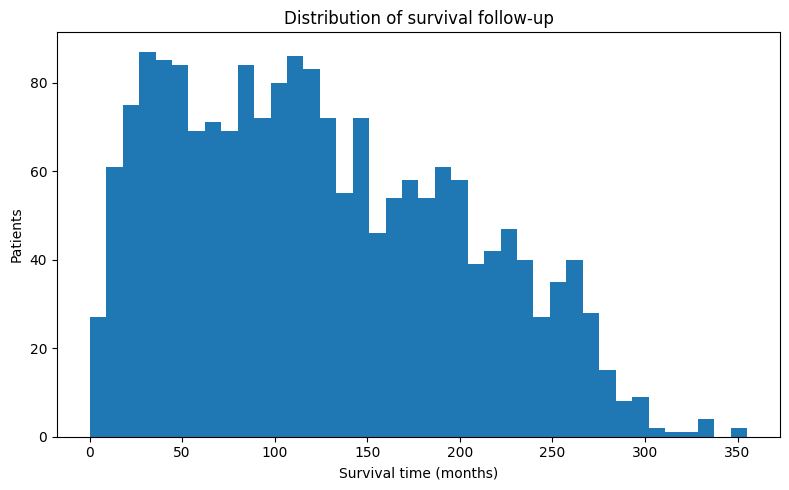

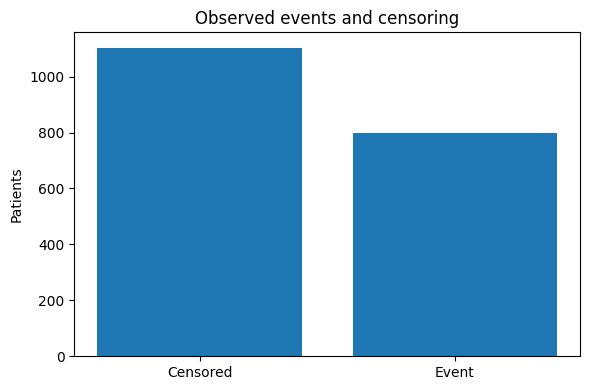

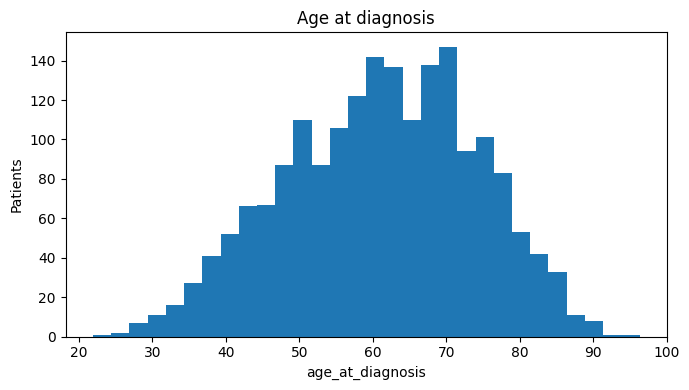

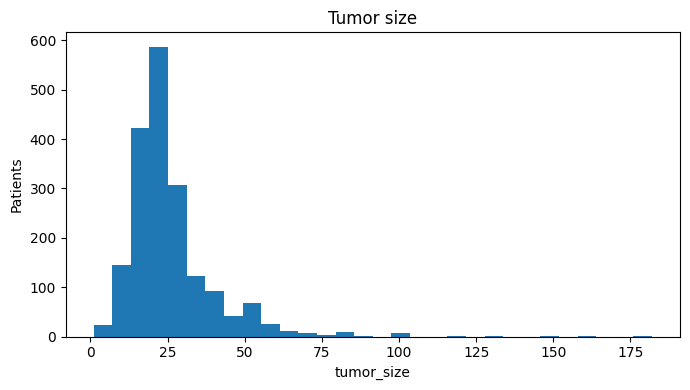

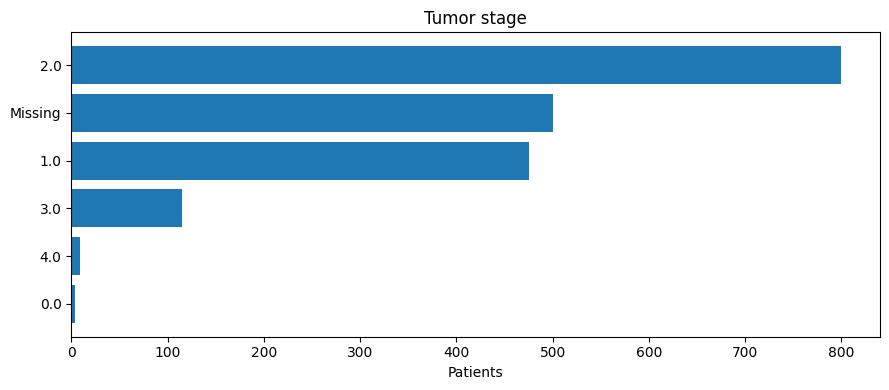

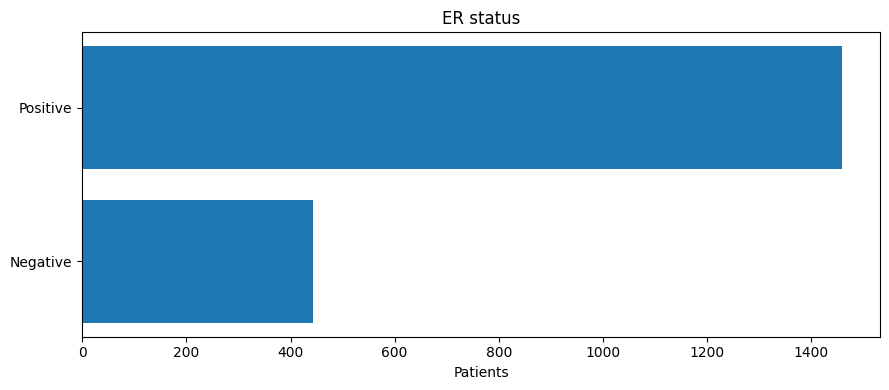

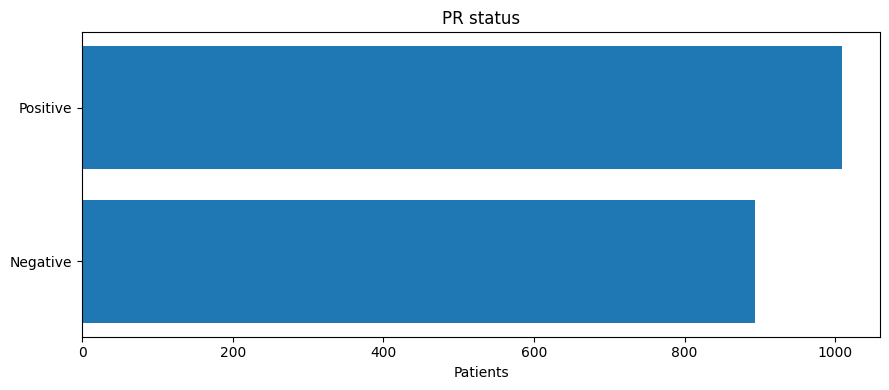

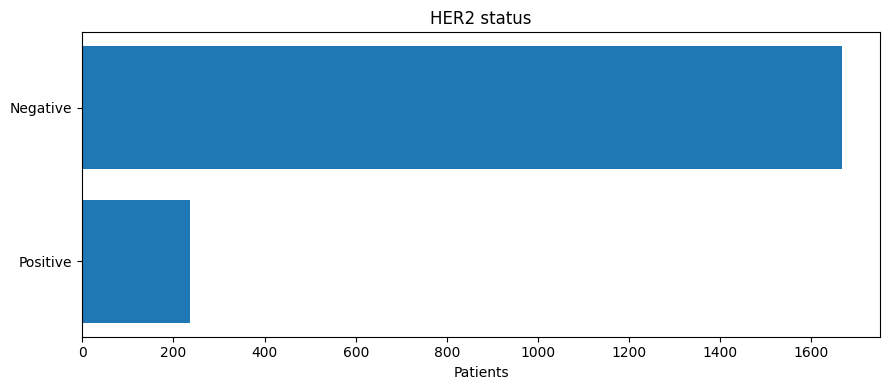

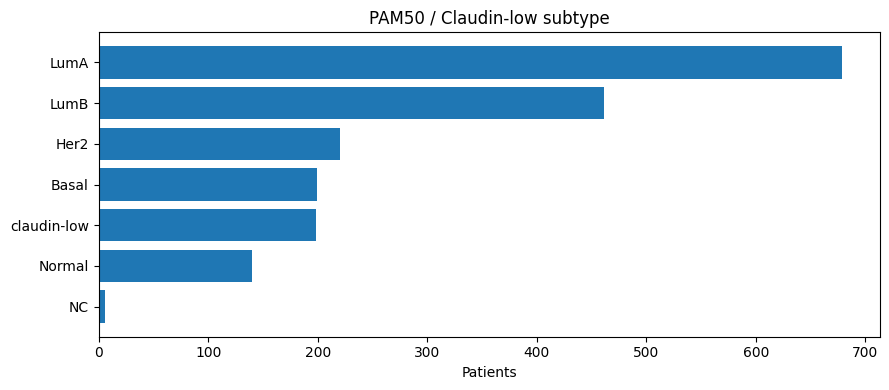


PATIENT IDENTIFIER AUDIT
Patient identifier column: patient_id
Missing patient IDs: 0
Rows with duplicated non-missing patient IDs: 0


In [ ]:
# ============================================================
# 5. Leakage detection, non-feature columns and initial EDA
# ============================================================

# ------------------------------------------------------------
# Leakage terminology
# ------------------------------------------------------------

# Exact or near-exact normalized names known to encode:
# - survival time;
# - survival status;
# - recurrence or relapse outcomes;
# - follow-up information;
# - cause or timing of death.
#
# These columns may be valid outcome sources, but they must never
# enter a model feature matrix or graph similarity calculation.
EXACT_LEAKAGE_NAMES = {
    # Canonical columns created by this notebook
    "survival_time",
    "event",
    "cancer_specific_event",

    # Overall survival
    "overall_survival",
    "overall_survival_status",
    "overall_survival_months",
    "overall_survival_time",
    "os",
    "os_status",
    "os_months",
    "os_time",

    # Disease-specific survival
    "disease_specific_survival",
    "disease_specific_survival_status",
    "disease_specific_survival_months",
    "disease_specific_survival_time",
    "dss",
    "dss_status",
    "dss_months",
    "dss_time",

    # Relapse-free survival
    "relapse_free_status",
    "relapse_free_status_months",
    "relapse_free_survival",
    "relapse_free_survival_status",
    "relapse_free_survival_months",
    "relapse_free_survival_time",
    "rfs",
    "rfs_status",
    "rfs_months",
    "rfs_time",

    # Disease-free survival
    "disease_free_status",
    "disease_free_status_months",
    "disease_free_survival",
    "disease_free_survival_status",
    "disease_free_survival_months",
    "disease_free_survival_time",
    "dfs",
    "dfs_status",
    "dfs_months",
    "dfs_time",

    # Progression and recurrence
    "progression_free_status",
    "progression_free_status_months",
    "progression_free_survival",
    "progression_free_survival_status",
    "progression_free_survival_months",
    "progression_free_survival_time",
    "recurrence",
    "recurrence_status",
    "recurrence_time",
    "recurrence_months",
    "time_to_recurrence",
    "months_to_recurrence",

    # Vital status and cause of death
    "death_from_cancer",
    "breast_cancer_death",
    "patient_status",
    "vital_status",
    "cause_of_death",
    "death_cause",
    "days_to_death",
    "months_to_death",
    "time_to_death",

    # Follow-up variables
    "last_follow_up",
    "last_followup",
    "days_to_last_follow_up",
    "days_to_last_followup",
    "months_to_last_follow_up",
    "months_to_last_followup",
    "follow_up_time",
    "followup_time",
}


# Patterns are used only for clear outcome-derived naming families.
# They intentionally avoid overly broad terms such as a bare "status",
# because ER, PR and HER2 status are legitimate baseline features.
LEAKAGE_PATTERNS = [
    re.compile(r"(^|_)overall_survival($|_)"),
    re.compile(r"(^|_)disease_specific_survival($|_)"),
    re.compile(r"(^|_)relapse_free($|_)"),
    re.compile(r"(^|_)disease_free($|_)"),
    re.compile(r"(^|_)progression_free($|_)"),
    re.compile(r"(^|_)recurrence($|_)"),
    re.compile(r"(^|_)time_to_death($|_)"),
    re.compile(r"(^|_)days_to_death($|_)"),
    re.compile(r"(^|_)months_to_death($|_)"),
    re.compile(r"(^|_)cause_of_death($|_)"),
    re.compile(r"(^|_)death_from_cancer($|_)"),
    re.compile(r"(^|_)last_follow_?up($|_)"),
    re.compile(r"(^|_)days_to_last_follow_?up($|_)"),
    re.compile(r"(^|_)months_to_last_follow_?up($|_)"),
]


def is_leakage_column(column_name: Any) -> bool:
    """
    Return True when a column contains an outcome, censoring time,
    recurrence endpoint, follow-up information or another variable
    derived from survival outcome.

    This function is intended for feature exclusion, not for deciding
    whether a column can be used as the target.
    """
    normalized_column = norm(column_name)

    if normalized_column in EXACT_LEAKAGE_NAMES:
        return True

    return any(
        pattern.search(normalized_column) is not None
        for pattern in LEAKAGE_PATTERNS
    )


# Backward-compatible alias in case a later existing cell calls leakage().
def leakage(column_name: Any) -> bool:
    return is_leakage_column(column_name)


# ------------------------------------------------------------
# Identify leakage and technical non-feature columns
# ------------------------------------------------------------

resolved_outcome_columns = {
    column
    for column in SOURCE_OUTCOME_COLUMNS
    if column is not None
}

created_outcome_columns = {
    column
    for column in [
        "survival_time",
        "event",
        "cancer_specific_event",
    ]
    if column in analysis_df.columns
}

pattern_detected_leakage_columns = {
    column
    for column in analysis_df.columns
    if is_leakage_column(column)
}

leakage_cols = sorted(
    resolved_outcome_columns
    | created_outcome_columns
    | pattern_detected_leakage_columns
)


# Identifiers and audit columns are not outcome leakage, but they must not
# be used as predictive features or graph similarity variables.
NON_FEATURE_TECHNICAL_COLUMNS = {
    "original_row_index",
}

if patient_id_col is not None:
    NON_FEATURE_TECHNICAL_COLUMNS.add(patient_id_col)


# This unified collection can be used by later feature-detection cells.
EXCLUDED_MODEL_INPUT_COLUMNS = sorted(
    set(leakage_cols)
    | NON_FEATURE_TECHNICAL_COLUMNS
)


print("=" * 70)
print("MODEL-INPUT EXCLUSION AUDIT")
print("=" * 70)

print("\nOutcome or post-outcome leakage columns:")
for column in leakage_cols:
    print(f"  - {column}")

print("\nTechnical or identifier columns:")
for column in sorted(NON_FEATURE_TECHNICAL_COLUMNS):
    print(f"  - {column}")

print("\nAll columns excluded from model inputs:")
for column in EXCLUDED_MODEL_INPUT_COLUMNS:
    print(f"  - {column}")


leakage_audit = pd.DataFrame(
    {
        "column": EXCLUDED_MODEL_INPUT_COLUMNS,
    }
)

leakage_audit["exclusion_type"] = leakage_audit["column"].map(
    lambda column: (
        "outcome_or_post_outcome"
        if column in leakage_cols
        else "identifier_or_technical"
    )
)

leakage_audit.to_csv(
    OUT / "excluded_model_input_columns.csv",
    index=False,
)


# ------------------------------------------------------------
# Figure-saving utility
# ------------------------------------------------------------

def savefig(filename: str) -> Path:
    """
    Save the current matplotlib figure, display it and close it.

    Returns
    -------
    Path
        Location of the saved figure.
    """
    if not isinstance(filename, str) or not filename.strip():
        raise ValueError("filename must be a non-empty string.")

    filename = filename.strip()

    if Path(filename).suffix == "":
        filename = f"{filename}.png"

    PLOTS.mkdir(
        parents=True,
        exist_ok=True,
    )

    output_path = PLOTS / filename

    plt.tight_layout()
    plt.savefig(
        output_path,
        dpi=180,
        bbox_inches="tight",
    )
    plt.show()
    plt.close()

    return output_path


# ------------------------------------------------------------
# Missing-values summary
# ------------------------------------------------------------

missing_count = analysis_df.isna().sum()
missing_fraction = analysis_df.isna().mean()

missing_summary = pd.DataFrame(
    {
        "column": analysis_df.columns,
        "dtype": [
            str(dtype)
            for dtype in analysis_df.dtypes
        ],
        "missing_count": [
            int(missing_count[column])
            for column in analysis_df.columns
        ],
        "missing_fraction": [
            float(missing_fraction[column])
            for column in analysis_df.columns
        ],
        "excluded_from_model_input": [
            column in EXCLUDED_MODEL_INPUT_COLUMNS
            for column in analysis_df.columns
        ],
    }
)

missing_summary = (
    missing_summary
    .sort_values(
        by=[
            "missing_fraction",
            "missing_count",
            "column",
        ],
        ascending=[
            False,
            False,
            True,
        ],
    )
    .reset_index(drop=True)
)

missing_summary.to_csv(
    OUT / "missingness_summary.csv",
    index=False,
)

print("\n" + "=" * 70)
print("MISSINGNESS SUMMARY")
print("=" * 70)
display(missing_summary.head(25))


# ------------------------------------------------------------
# Infinite-values inspection
# ------------------------------------------------------------

numeric_df = analysis_df.select_dtypes(
    include=[np.number]
).copy()

if numeric_df.shape[1] > 0:
    numeric_array = numeric_df.to_numpy(
        dtype=float,
        copy=True,
    )

    infinite_mask = np.isinf(numeric_array)

    number_of_infinite_values = int(
        infinite_mask.sum()
    )

    infinite_count_by_column = pd.Series(
        infinite_mask.sum(axis=0),
        index=numeric_df.columns,
        name="infinite_count",
    )

    infinite_summary = (
        infinite_count_by_column[
            infinite_count_by_column > 0
        ]
        .sort_values(ascending=False)
        .reset_index()
        .rename(columns={"index": "column"})
    )
else:
    number_of_infinite_values = 0
    infinite_summary = pd.DataFrame(
        columns=[
            "column",
            "infinite_count",
        ]
    )

print("\nInfinite numeric values:", number_of_infinite_values)

if not infinite_summary.empty:
    print(
        "[WARNING] Infinite values were found. They must be converted "
        "to missing values inside fold-specific preprocessing."
    )
    display(infinite_summary)

infinite_summary.to_csv(
    OUT / "infinite_values_summary.csv",
    index=False,
)


# ------------------------------------------------------------
# Survival-time distribution
# ------------------------------------------------------------

plt.figure(
    figsize=(8, 5),
)

plt.hist(
    analysis_df["survival_time"],
    bins=40,
)

plt.xlabel("Survival time (months)")
plt.ylabel("Patients")
plt.title("Distribution of survival follow-up")

savefig("eda_survival_time.png")


# ------------------------------------------------------------
# Events and censoring
# ------------------------------------------------------------

event_counts = analysis_df["event"].value_counts()

plt.figure(
    figsize=(6, 4),
)

plt.bar(
    [
        "Censored",
        "Event",
    ],
    [
        int(event_counts.get(0, 0)),
        int(event_counts.get(1, 0)),
    ],
)

plt.ylabel("Patients")
plt.title("Observed events and censoring")

savefig("eda_event.png")


# ------------------------------------------------------------
# Numeric-variable plotting utility
# ------------------------------------------------------------

def numplot(
    column_candidates: Sequence[str],
    title: str,
    filename: str,
) -> Optional[Path]:
    """
    Plot the distribution of the first available numeric column.

    This is descriptive EDA only. It must not be used to fit preprocessing
    parameters or choose model features before cross-validation.
    """
    column = find_col(column_candidates)

    if column is None:
        print(
            f"[EDA] Skipped '{title}': "
            "no matching column was detected."
        )
        return None

    if column not in analysis_df.columns:
        print(
            f"[EDA] Skipped '{title}': "
            f"column '{column}' is unavailable in analysis_df."
        )
        return None

    values = pd.to_numeric(
        analysis_df[column],
        errors="coerce",
    )

    values = (
        values
        .replace(
            [
                np.inf,
                -np.inf,
            ],
            np.nan,
        )
        .dropna()
    )

    if values.empty:
        print(
            f"[EDA] Skipped '{title}': "
            "no valid finite numeric values."
        )
        return None

    plt.figure(
        figsize=(7, 4),
    )

    plt.hist(
        values,
        bins=30,
    )

    plt.xlabel(column)
    plt.ylabel("Patients")
    plt.title(title)

    return savefig(filename)


# ------------------------------------------------------------
# Categorical-variable plotting utility
# ------------------------------------------------------------

def catplot(
    column_candidates: Sequence[str],
    title: str,
    filename: str,
    top_n: int = 15,
) -> Optional[Path]:
    """
    Plot the most frequent categories of the first available column.
    """
    if not isinstance(top_n, int) or top_n <= 0:
        raise ValueError("top_n must be a strictly positive integer.")

    column = find_col(column_candidates)

    if column is None:
        print(
            f"[EDA] Skipped '{title}': "
            "no matching column was detected."
        )
        return None

    if column not in analysis_df.columns:
        print(
            f"[EDA] Skipped '{title}': "
            f"column '{column}' is unavailable in analysis_df."
        )
        return None

    values = (
        analysis_df[column]
        .astype("string")
        .fillna("Missing")
        .str.strip()
        .replace("", "Missing")
    )

    value_counts = (
        values
        .value_counts(dropna=False)
        .head(top_n)
        .sort_values()
    )

    if value_counts.empty:
        print(
            f"[EDA] Skipped '{title}': "
            "no categorical values."
        )
        return None

    plt.figure(
        figsize=(
            9,
            max(
                4.0,
                len(value_counts) * 0.35,
            ),
        ),
    )

    plt.barh(
        value_counts.index.astype(str),
        value_counts.values,
    )

    plt.xlabel("Patients")
    plt.title(title)

    return savefig(filename)


# ------------------------------------------------------------
# Numeric EDA
# ------------------------------------------------------------

numplot(
    ["age_at_diagnosis"],
    "Age at diagnosis",
    "eda_age.png",
)

numplot(
    ["tumor_size"],
    "Tumor size",
    "eda_tumor_size.png",
)


# ------------------------------------------------------------
# Categorical EDA
# ------------------------------------------------------------

categorical_plots = [
    (
        ["tumor_stage"],
        "Tumor stage",
        "eda_stage.png",
    ),
    (
        ["er_status"],
        "ER status",
        "eda_er.png",
    ),
    (
        ["pr_status"],
        "PR status",
        "eda_pr.png",
    ),
    (
        ["her2_status"],
        "HER2 status",
        "eda_her2.png",
    ),
    (
        [
            "pam50_+_claudin-low_subtype",
            "pam50_claudin_low_subtype",
        ],
        "PAM50 / Claudin-low subtype",
        "eda_pam50.png",
    ),
]

for (
    column_candidates,
    title,
    filename,
) in categorical_plots:
    catplot(
        column_candidates=column_candidates,
        title=title,
        filename=filename,
    )


# ------------------------------------------------------------
# Patient-ID duplicate inspection
# ------------------------------------------------------------

if (
    patient_id_col is not None
    and patient_id_col in analysis_df.columns
):
    patient_id_values = analysis_df[
        patient_id_col
    ]

    missing_patient_id_mask = patient_id_values.isna()

    normalized_patient_ids = (
        patient_id_values
        .astype("string")
        .str.strip()
    )

    missing_patient_id_mask = (
        missing_patient_id_mask
        | normalized_patient_ids.isna()
        | normalized_patient_ids.eq("")
    )

    nonmissing_patient_ids = normalized_patient_ids.loc[
        ~missing_patient_id_mask
    ]

    duplicated_nonmissing_mask = nonmissing_patient_ids.duplicated(
        keep=False
    )

    duplicate_patient_ids = int(
        duplicated_nonmissing_mask.sum()
    )

    number_of_missing_patient_ids = int(
        missing_patient_id_mask.sum()
    )

    print("\n" + "=" * 70)
    print("PATIENT IDENTIFIER AUDIT")
    print("=" * 70)
    print("Patient identifier column:", patient_id_col)
    print("Missing patient IDs:", number_of_missing_patient_ids)
    print(
        "Rows with duplicated non-missing patient IDs:",
        duplicate_patient_ids,
    )

    if duplicate_patient_ids > 0:
        duplicate_patient_id_summary = (
            nonmissing_patient_ids.loc[
                duplicated_nonmissing_mask
            ]
            .value_counts()
            .rename("row_count")
            .reset_index()
            .rename(columns={"index": patient_id_col})
        )

        duplicate_patient_id_summary.to_csv(
            OUT / "duplicate_patient_ids.csv",
            index=False,
        )

        display(duplicate_patient_id_summary.head(30))

        raise ValueError(
            "Duplicated patient identifiers were detected. "
            "They must be resolved before creating cross-validation "
            "splits, otherwise the same patient may leak across folds."
        )

    if number_of_missing_patient_ids > 0:
        warnings.warn(
            "Some included rows have missing patient identifiers. "
            "They can remain only if each row is confirmed to represent "
            "a unique patient.",
            RuntimeWarning,
        )

else:
    duplicate_patient_ids = 0
    number_of_missing_patient_ids = len(analysis_df)

    print(
        "\n[WARNING] Patient-ID duplicate inspection was not possible "
        "because no patient identifier column is available."
    )

## 9. Automatic modality detection

## 10. Mutation encoding and pathway definitions

In [ ]:
# ============================================================
# 6. Feature-type detection, clinical configurations,
#    mutation encoding and pathway definitions
# ============================================================

# ------------------------------------------------------------
# Activate only configuration fields implemented in this cell
# ------------------------------------------------------------

CONFIG.setdefault(
    "clinical_feature_mode",
    "components_without_npi",
)

CONFIG.setdefault(
    "include_treatment_features",
    True,
)

CONFIG.setdefault(
    "minimum_genes_per_pathway",
    3,
)

VALID_CLINICAL_FEATURE_MODES = {
    "npi_without_components",
    "components_without_npi",
    "all_with_npi_secondary",
}

if CONFIG["clinical_feature_mode"] not in VALID_CLINICAL_FEATURE_MODES:
    raise ValueError(
        "CONFIG['clinical_feature_mode'] must be one of: "
        f"{sorted(VALID_CLINICAL_FEATURE_MODES)}"
    )

if not isinstance(
    CONFIG["include_treatment_features"],
    bool,
):
    raise TypeError(
        "CONFIG['include_treatment_features'] must be boolean."
    )

if (
    not isinstance(CONFIG["minimum_genes_per_pathway"], int)
    or CONFIG["minimum_genes_per_pathway"] < 2
):
    raise ValueError(
        "CONFIG['minimum_genes_per_pathway'] must be an integer >= 2."
    )


# ------------------------------------------------------------
# Known METABRIC baseline variables
# ------------------------------------------------------------

# These are candidate baseline predictors only.
# Outcome-derived and technical columns remain excluded separately.
KNOWN_CLINICAL_FEATURE_NAMES = {
    # Demographic and diagnostic variables
    "age_at_diagnosis",
    "menopausal_state",
    "inferred_menopausal_state",

    # Tumor anatomy and pathology
    "tumor_size",
    "tumor_stage",
    "neoplasm_histologic_grade",
    "lymph_nodes_examined_positive",
    "cellularity",
    "primary_tumor_laterality",
    "type_of_breast_surgery",
    "cancer_type",
    "cancer_type_detailed",
    "histological_subtype",

    # Receptor and molecular subtype information available at baseline
    "er_status",
    "pr_status",
    "her2_status",
    "er_status_measured_by_ihc",
    "pam50_+_claudin-low_subtype",
    "pam50_claudin_low_subtype",
    "3-gene_classifier_subtype",
    "integrative_cluster",

    # Composite prognostic score
    "nottingham_prognostic_index",

    # Treatment variables
    "chemotherapy",
    "hormone_therapy",
    "radio_therapy",
}

KNOWN = {
    norm(column_name)
    for column_name in KNOWN_CLINICAL_FEATURE_NAMES
}


NPI_COLUMN_NAMES = {
    norm("nottingham_prognostic_index"),
}

NPI_COMPONENT_NAMES = {
    norm("tumor_size"),
    norm("neoplasm_histologic_grade"),
    norm("lymph_nodes_examined_positive"),
}

TREATMENT_FEATURE_NAMES = {
    norm("chemotherapy"),
    norm("hormone_therapy"),
    norm("radio_therapy"),
}


# Cohort is retained as metadata for cohort-based validation.
# It is excluded from model inputs by default.
cohort_col = find_col(
    [
        "cohort",
        "study_cohort",
        "metabric_cohort",
    ]
)

if cohort_col is not None:
    NON_FEATURE_TECHNICAL_COLUMNS.add(cohort_col)

EXCLUDED_MODEL_INPUT_COLUMNS = sorted(
    set(leakage_cols)
    | NON_FEATURE_TECHNICAL_COLUMNS
)


# ------------------------------------------------------------
# Mutation-column detection
# ------------------------------------------------------------

def is_mutation_column(column_name: Any) -> bool:
    """
    Detect explicit mutation columns.

    METABRIC mutation variables generally end in '_mut'.
    """
    normalized_column = norm(column_name)

    return (
        normalized_column.endswith("_mut")
        or normalized_column.endswith("_mutation")
        or normalized_column.endswith("_mutation_status")
    )


mutation_cols = [
    column
    for column in analysis_df.columns
    if (
        column not in EXCLUDED_MODEL_INPUT_COLUMNS
        and is_mutation_column(column)
    )
]


# ------------------------------------------------------------
# Conservative CNA-column detection
# ------------------------------------------------------------

CNA_EXACT_NAMES = {
    "cna",
    "cnv",
    "copy_number",
    "copy_number_alteration",
    "copy_number_status",
    "gistic",
    "gistic_score",
}


def is_cna_column(column_name: Any) -> bool:
    """
    Conservatively detect explicit CNA/CNV columns.

    Broad searches for terms such as 'gain' or 'loss' are intentionally
    avoided because they can misclassify unrelated feature names.
    """
    normalized_column = norm(column_name)

    if normalized_column in CNA_EXACT_NAMES:
        return True

    explicit_suffixes = (
        "_cna",
        "_cnv",
        "_copy_number",
        "_copy_number_status",
        "_gistic",
        "_gistic_score",
    )

    explicit_prefixes = (
        "cna_",
        "cnv_",
        "copy_number_",
        "gistic_",
    )

    return (
        normalized_column.endswith(explicit_suffixes)
        or normalized_column.startswith(explicit_prefixes)
    )


cna_cols = [
    column
    for column in analysis_df.columns
    if (
        column not in EXCLUDED_MODEL_INPUT_COLUMNS
        and column not in mutation_cols
        and is_cna_column(column)
    )
]


# ------------------------------------------------------------
# Candidate columns remaining after strict exclusions
# ------------------------------------------------------------

excluded_for_feature_detection = (
    set(EXCLUDED_MODEL_INPUT_COLUMNS)
    | set(mutation_cols)
    | set(cna_cols)
)

candidates = [
    column
    for column in analysis_df.columns
    if column not in excluded_for_feature_detection
]


# ------------------------------------------------------------
# Clinical-feature detection
# ------------------------------------------------------------

all_detected_clinical_cols = [
    column
    for column in candidates
    if norm(column) in KNOWN
]


def apply_clinical_feature_configuration(
    columns: Sequence[str],
    clinical_feature_mode: str,
    include_treatment_features: bool,
) -> List[str]:
    """
    Apply the pre-specified NPI/components and treatment configuration.

    No data values or outcomes are inspected by this function.
    """
    selected_columns: List[str] = []

    for column in columns:
        normalized_column = norm(column)

        if (
            not include_treatment_features
            and normalized_column in TREATMENT_FEATURE_NAMES
        ):
            continue

        if clinical_feature_mode == "npi_without_components":
            if normalized_column in NPI_COMPONENT_NAMES:
                continue

        elif clinical_feature_mode == "components_without_npi":
            if normalized_column in NPI_COLUMN_NAMES:
                continue

        elif clinical_feature_mode == "all_with_npi_secondary":
            pass

        else:
            raise ValueError(
                f"Unsupported clinical feature mode: "
                f"{clinical_feature_mode}"
            )

        selected_columns.append(column)

    return selected_columns


clinical_cols = apply_clinical_feature_configuration(
    columns=all_detected_clinical_cols,
    clinical_feature_mode=CONFIG["clinical_feature_mode"],
    include_treatment_features=CONFIG[
        "include_treatment_features"
    ],
)


clinical_numeric_cols = [
    column
    for column in clinical_cols
    if pd.api.types.is_numeric_dtype(
        analysis_df[column]
    )
]


clinical_categorical_cols = [
    column
    for column in clinical_cols
    if column not in clinical_numeric_cols
]


# Some clinically numeric variables may have been read as object because
# of malformed or missing strings. Report them for later preprocessing,
# but do not inspect outcomes or globally impute them here.
EXPECTED_NUMERIC_CLINICAL_NAMES = {
    norm("age_at_diagnosis"),
    norm("tumor_size"),
    norm("tumor_stage"),
    norm("neoplasm_histologic_grade"),
    norm("lymph_nodes_examined_positive"),
    norm("nottingham_prognostic_index"),
}


object_clinical_numeric_candidates = [
    column
    for column in clinical_categorical_cols
    if norm(column) in EXPECTED_NUMERIC_CLINICAL_NAMES
]

for column in object_clinical_numeric_candidates:
    converted = pd.to_numeric(
        analysis_df[column],
        errors="coerce",
    )

    # This check is used only to correct the semantic type of a known
    # clinical variable. It does not select a variable based on outcome.
    if converted.notna().any():
        clinical_categorical_cols.remove(column)
        clinical_numeric_cols.append(column)


clinical_numeric_cols = sorted(
    clinical_numeric_cols
)

clinical_categorical_cols = sorted(
    clinical_categorical_cols
)

clinical_cols = (
    clinical_numeric_cols
    + clinical_categorical_cols
)


# ------------------------------------------------------------
# Expression-column detection
# ------------------------------------------------------------

def is_numeric_or_numeric_like(
    series: pd.Series,
) -> bool:
    """
    Identify columns that can represent continuous measurements.

    Numeric dtypes are accepted directly. For object columns, this only
    determines semantic compatibility; missingness and variance filtering
    will be learned separately inside each training fold.
    """
    if pd.api.types.is_numeric_dtype(series):
        return True

    nonmissing_series = series.dropna()

    if nonmissing_series.empty:
        return False

    converted = pd.to_numeric(
        nonmissing_series,
        errors="coerce",
    )

    # A very high threshold prevents ordinary categorical metadata from
    # being classified as expression. This is schema detection only.
    return float(converted.notna().mean()) >= 0.98


remaining_nonclinical_candidates = [
    column
    for column in candidates
    if column not in all_detected_clinical_cols
]


expression_cols = [
    column
    for column in remaining_nonclinical_candidates
    if is_numeric_or_numeric_like(
        analysis_df[column]
    )
]


unclassified_cols = [
    column
    for column in remaining_nonclinical_candidates
    if column not in expression_cols
]


# No global missingness, variance, correlation or outcome-based filter is
# applied here. Such filters must be fitted using each training fold only.


# ------------------------------------------------------------
# Feature-group audit
# ------------------------------------------------------------

feature_group_counts = {
    "clinical_all_detected": len(
        all_detected_clinical_cols
    ),
    "clinical_selected": len(clinical_cols),
    "clinical_numeric": len(
        clinical_numeric_cols
    ),
    "clinical_categorical": len(
        clinical_categorical_cols
    ),
    "expression_candidates": len(
        expression_cols
    ),
    "mutation": len(mutation_cols),
    "cna": len(cna_cols),
    "unclassified": len(unclassified_cols),
}

print("=" * 70)
print("FEATURE-TYPE DETECTION")
print("=" * 70)
print(
    json.dumps(
        feature_group_counts,
        indent=2,
    )
)

print(
    "\nClinical feature mode:",
    CONFIG["clinical_feature_mode"],
)
print(
    "Treatment features included:",
    CONFIG["include_treatment_features"],
)
print("Cohort metadata column:", cohort_col)

print("\nSelected numeric clinical columns:")
print(clinical_numeric_cols)

print("\nSelected categorical clinical columns:")
print(clinical_categorical_cols)

if unclassified_cols:
    print(
        "\n[WARNING] Columns not assigned to a feature modality:"
    )
    print(unclassified_cols)


detected_feature_groups = {
    "clinical_feature_mode": CONFIG[
        "clinical_feature_mode"
    ],
    "include_treatment_features": CONFIG[
        "include_treatment_features"
    ],
    "cohort_col": cohort_col,
    "all_detected_clinical_cols": (
        all_detected_clinical_cols
    ),
    "clinical_cols": clinical_cols,
    "clinical_numeric_cols": (
        clinical_numeric_cols
    ),
    "clinical_categorical_cols": (
        clinical_categorical_cols
    ),
    "expression_cols": expression_cols,
    "mutation_cols": mutation_cols,
    "cna_cols": cna_cols,
    "unclassified_cols": unclassified_cols,
    "excluded_model_input_columns": (
        EXCLUDED_MODEL_INPUT_COLUMNS
    ),
}

with (
    ART / "detected_feature_groups.json"
).open(
    mode="w",
    encoding="utf-8",
) as file:
    json.dump(
        detected_feature_groups,
        file,
        indent=2,
        ensure_ascii=False,
    )


# Update saved CONFIG now that clinical options are implemented.
with (OUT / "config.json").open(
    mode="w",
    encoding="utf-8",
) as file:
    json.dump(
        CONFIG,
        file,
        indent=2,
        ensure_ascii=False,
    )


# ------------------------------------------------------------
# Mutation encoding utilities
# ------------------------------------------------------------

# Explicit values representing absence of mutation.
# Truly missing values remain missing.
ABSENT = {
    "",
    "0",
    "0_0",
    "none",
    "no",
    "no_mutation",
    "wild_type",
    "wildtype",
    "wt",
    "false",
    "negative",
    "not_mutated",
    "unmutated",
}


def mutbin(value: Any) -> float:
    """
    Encode a mutation value.

    Returns
    -------
    1.0
        A mutation is reported.
    0.0
        Explicit absence/wild type is reported.
    np.nan
        The mutation status is missing or cannot safely be determined.

    Missing values are deliberately not treated as wild type.
    """
    if pd.isna(value):
        return np.nan

    if isinstance(value, (bool, np.bool_)):
        return float(value)

    if isinstance(
        value,
        (int, float, np.integer, np.floating),
    ):
        numeric_value = float(value)

        if not np.isfinite(numeric_value):
            return np.nan

        return float(numeric_value != 0.0)

    raw_text = str(value).strip()

    if raw_text == "":
        return 0.0

    normalized_value = norm(raw_text)

    if normalized_value in {
        "nan",
        "na",
        "n_a",
        "null",
        "missing",
        "unknown",
        "not_available",
    }:
        return np.nan

    if normalized_value in ABSENT:
        return 0.0

    return 1.0


def encode_mut(
    frame: pd.DataFrame,
    cols: Sequence[str],
) -> pd.DataFrame:
    """
    Encode mutation columns while preserving unknown values as NaN.

    Mutation selection and imputation must subsequently be fitted using
    training patients only.
    """
    missing_columns = [
        column
        for column in cols
        if column not in frame.columns
    ]

    if missing_columns:
        raise KeyError(
            "Mutation columns missing from input frame: "
            f"{missing_columns[:20]}"
        )

    encoded_columns: Dict[str, pd.Series] = {}

    for column in cols:
        encoded_columns[column] = (
            frame[column]
            .map(mutbin)
            .astype(np.float32)
        )

    return pd.DataFrame(
        encoded_columns,
        index=frame.index,
    )


# ------------------------------------------------------------
# Breast-cancer-relevant pathway signatures
# ------------------------------------------------------------

# The signatures are embedded locally so notebook execution does not
# require downloading external gene sets.
#
# They are compact biological signatures, not complete MSigDB gene sets.
# Their purpose and limitations must be reported explicitly.
PATHWAYS = {
    "e2f_targets": [
        "E2F1", "E2F2", "E2F3", "TFDP1", "CCNE1", "CCNE2",
        "CDK2", "MCM2", "MCM3", "MCM4", "MCM5", "MCM6",
        "MCM7", "PCNA", "CDC6", "CDC25A", "RRM2", "TK1",
        "TYMS", "DHFR",
    ],

    "g2m_checkpoint": [
        "CDK1", "CCNA2", "CCNB1", "CCNB2", "CDC20", "CDC25C",
        "PLK1", "AURKA", "AURKB", "BUB1", "BUB1B", "MAD2L1",
        "NDC80", "CENPE", "CENPF", "KIF11", "KIF2C", "TOP2A",
        "UBE2C", "BIRC5",
    ],

    "estrogen_response_early": [
        "ESR1", "PGR", "GATA3", "FOXA1", "TFF1", "GREB1",
        "XBP1", "MYB", "CCND1", "IGF1R", "RARA", "KRT18",
        "KRT19", "SLC39A6", "CA12",
    ],

    "estrogen_response_late": [
        "ESR1", "PGR", "GATA3", "FOXA1", "TFF1", "GREB1",
        "BCL2", "NAT1", "SCUBE2", "MAPT", "AGR2", "MUC1",
        "KRT8", "KRT18", "KRT19",
    ],

    "p53_pathway": [
        "TP53", "CDKN1A", "MDM2", "GADD45A", "BAX", "BBC3",
        "PMAIP1", "FAS", "SESN1", "SESN2", "DDB2", "RRM2B",
        "ZMAT3", "SFN", "CCNG1",
    ],

    "pi3k_akt_mtor": [
        "PIK3CA", "PIK3CB", "PIK3R1", "AKT1", "AKT2", "AKT3",
        "MTOR", "PTEN", "TSC1", "TSC2", "RHEB", "RPTOR",
        "RICTOR", "FOXO1", "FOXO3", "GSK3B", "RPS6KB1",
        "EIF4EBP1",
    ],

    "dna_repair": [
        "BRCA1", "BRCA2", "RAD51", "RAD51C", "RAD51D", "ATM",
        "ATR", "CHEK1", "CHEK2", "PALB2", "BARD1", "MRE11",
        "NBN", "MLH1", "MSH2", "MSH6", "PMS2", "ERCC1",
        "PARP1", "FANCD2",
    ],

    "apoptosis": [
        "BAX", "BAK1", "BCL2", "BCL2L1", "MCL1", "BAD",
        "BID", "BBC3", "PMAIP1", "CASP3", "CASP7", "CASP8",
        "CASP9", "APAF1", "FAS", "FADD", "XIAP", "DIABLO",
    ],

    "hypoxia": [
        "HIF1A", "EPAS1", "VEGFA", "CA9", "SLC2A1", "LDHA",
        "BNIP3", "BNIP3L", "ENO1", "PGK1", "ALDOA", "HK2",
        "PDK1", "ADM", "EGLN1",
    ],

    "angiogenesis": [
        "VEGFA", "VEGFB", "VEGFC", "KDR", "FLT1", "FLT4",
        "ANGPT1", "ANGPT2", "TEK", "PECAM1", "VWF", "ENG",
        "CDH5", "ROBO4", "ESM1",
    ],

    "epithelial_mesenchymal_transition": [
        "VIM", "CDH2", "CDH1", "SNAI1", "SNAI2", "TWIST1",
        "TWIST2", "ZEB1", "ZEB2", "FN1", "COL1A1", "COL1A2",
        "COL3A1", "MMP2", "MMP9", "ITGA5", "SPARC",
    ],

    "inflammatory_response": [
        "IL1B", "IL6", "TNF", "NFKB1", "RELA", "CXCL8",
        "CXCL10", "CCL2", "CCL5", "PTGS2", "TLR2", "TLR4",
        "STAT3", "ICAM1", "VCAM1",
    ],

    "interferon_gamma_response": [
        "IFNG", "IFNGR1", "IFNGR2", "STAT1", "IRF1", "IRF7",
        "JAK1", "JAK2", "CXCL9", "CXCL10", "CXCL11", "GBP1",
        "GBP2", "IDO1", "HLA-DRA", "B2M", "TAP1",
    ],

    "proliferation": [
        "MKI67", "PCNA", "TOP2A", "BIRC5", "AURKA", "AURKB",
        "UBE2C", "CCNA2", "CCNB1", "CDK1", "CDC20", "MCM2",
        "MCM4", "MCM6", "MCM7", "TYMS",
    ],

    "immune_response": [
        "CD3D", "CD3E", "CD3G", "CD4", "CD8A", "CD8B",
        "PDCD1", "CD274", "CTLA4", "LAG3", "TIGIT", "GZMB",
        "PRF1", "IFNG", "CXCL9", "CXCL10", "HLA-DRA",
        "MS4A1", "CD68",
    ],

    "cell_cycle": [
        "CDK1", "CDK2", "CDK4", "CDK6", "CCNA2", "CCNB1",
        "CCNB2", "CCND1", "CCNE1", "E2F1", "RB1", "CDC20",
        "CDC25A", "CDC25C", "PLK1",
    ],
}


# ------------------------------------------------------------
# Expression-column to gene-symbol lookup
# ------------------------------------------------------------

def canonical_gene_symbol(value: Any) -> str:
    """
    Produce a conservative uppercase gene-symbol representation.

    Exact symbols are preferred. Common separators used by expression
    datasets are supported without silently overwriting collisions.
    """
    text = str(value).strip().upper()

    if not text:
        return ""

    # Common formats:
    # TP53
    # TP53|7157
    # TP53 (probe)
    # TP53_expression
    for separator in [
        "|",
        " ",
        "(",
        ":",
    ]:
        if separator in text:
            text = text.split(separator, 1)[0].strip()

    known_suffixes = [
        "_EXPRESSION",
        "_EXPR",
        "_RNA",
        "_MRNA",
    ]

    for suffix in known_suffixes:
        if text.endswith(suffix):
            text = text[: -len(suffix)].strip()

    return text


def symbol_lookup(
    cols: Sequence[str],
) -> Dict[str, str]:
    """
    Map unique gene symbols to expression-column names.

    Ambiguous aliases are excluded instead of being overwritten.
    """
    symbol_to_columns: Dict[str, List[str]] = {}

    for column in cols:
        exact_symbol = str(column).strip().upper()
        canonical_symbol = canonical_gene_symbol(
            column
        )

        aliases = {
            alias
            for alias in [
                exact_symbol,
                canonical_symbol,
            ]
            if alias
        }

        for alias in aliases:
            symbol_to_columns.setdefault(
                alias,
                [],
            ).append(column)

    return {
        symbol: columns[0]
        for symbol, columns in symbol_to_columns.items()
        if len(set(columns)) == 1
    }


expr_lookup = symbol_lookup(
    expression_cols
)


# ------------------------------------------------------------
# Pathway availability audit
# ------------------------------------------------------------

pathway_availability_records: List[
    Dict[str, Any]
] = []

for pathway_name, requested_genes in PATHWAYS.items():
    available_genes = [
        gene
        for gene in requested_genes
        if gene.upper() in expr_lookup
    ]

    missing_genes = [
        gene
        for gene in requested_genes
        if gene.upper() not in expr_lookup
    ]

    pathway_availability_records.append(
        {
            "pathway": pathway_name,
            "available_genes": len(
                available_genes
            ),
            "requested_genes": len(
                requested_genes
            ),
            "availability_fraction": (
                len(available_genes)
                / len(requested_genes)
                if requested_genes
                else np.nan
            ),
            "meets_minimum_gene_requirement": (
                len(available_genes)
                >= CONFIG[
                    "minimum_genes_per_pathway"
                ]
            ),
            "available_gene_symbols": ";".join(
                available_genes
            ),
            "missing_gene_symbols": ";".join(
                missing_genes
            ),
        }
    )


avail = pd.DataFrame(
    pathway_availability_records
).sort_values(
    by=[
        "meets_minimum_gene_requirement",
        "available_genes",
        "pathway",
    ],
    ascending=[
        False,
        False,
        True,
    ],
).reset_index(drop=True)


print("\n" + "=" * 70)
print("PATHWAY AVAILABILITY")
print("=" * 70)
display(avail)


avail.to_csv(
    ART / "pathway_availability.csv",
    index=False,
)


AVAILABLE_PATHWAY_GENES = {
    pathway_name: [
        gene
        for gene in requested_genes
        if gene.upper() in expr_lookup
    ]
    for pathway_name, requested_genes in PATHWAYS.items()
    if sum(
        gene.upper() in expr_lookup
        for gene in requested_genes
    )
    >= CONFIG["minimum_genes_per_pathway"]
}


print(
    "Pathways meeting the minimum gene requirement:",
    len(AVAILABLE_PATHWAY_GENES),
    "/",
    len(PATHWAYS),
)

FEATURE-TYPE DETECTION
{
  "clinical_all_detected": 22,
  "clinical_selected": 21,
  "clinical_numeric": 8,
  "clinical_categorical": 13,
  "expression_candidates": 490,
  "mutation": 173,
  "cna": 0,
  "unclassified": 3
}

Clinical feature mode: components_without_npi
Treatment features included: True
Cohort metadata column: cohort

Selected numeric clinical columns:
['age_at_diagnosis', 'chemotherapy', 'hormone_therapy', 'lymph_nodes_examined_positive', 'neoplasm_histologic_grade', 'radio_therapy', 'tumor_size', 'tumor_stage']

Selected categorical clinical columns:
['3-gene_classifier_subtype', 'cancer_type', 'cancer_type_detailed', 'cellularity', 'er_status', 'er_status_measured_by_ihc', 'her2_status', 'inferred_menopausal_state', 'integrative_cluster', 'pam50_+_claudin-low_subtype', 'pr_status', 'primary_tumor_laterality', 'type_of_breast_surgery']

[WARNING] Columns not assigned to a feature modality:
['her2_status_measured_by_snp6', 'tumor_other_histologic_subtype', 'oncotree_co

,pathway,available_genes,requested_genes,availability_fraction,meets_minimum_gene_requirement,available_gene_symbols,missing_gene_symbols
0,dna_repair,17,20,0.850000,True,BRCA1;BRCA2;RAD51;RAD51C;RAD51D;ATM;ATR;CHEK1;...,MRE11;ERCC1;PARP1
1,pi3k_akt_mtor,17,18,0.944444,True,PIK3CA;PIK3R1;AKT1;AKT2;AKT3;MTOR;PTEN;TSC1;TS...,PIK3CB
2,apoptosis,10,18,0.555556,True,BCL2;BCL2L1;BAD;BBC3;CASP3;CASP7;CASP8;CASP9;A...,BAX;BAK1;MCL1;BID;PMAIP1;FADD;XIAP;DIABLO
3,cell_cycle,10,15,0.666667,True,CDK1;CDK2;CDK4;CDK6;CCNB1;CCND1;CCNE1;E2F1;RB1...,CCNA2;CCNB2;CDC20;CDC25C;PLK1
4,e2f_targets,6,20,0.300000,True,E2F1;E2F2;E2F3;CCNE1;CDK2;CDC25A,TFDP1;CCNE2;MCM2;MCM3;MCM4;MCM5;MCM6;MCM7;PCNA...
5,epithelial_mesenchymal_transition,5,17,0.294118,True,CDH1;TWIST1;FN1;MMP2;MMP9,VIM;CDH2;SNAI1;SNAI2;TWIST2;ZEB1;ZEB2;COL1A1;C...
6,p53_pathway,5,15,0.333333,True,TP53;CDKN1A;MDM2;BBC3;FAS,GADD45A;BAX;PMAIP1;SESN1;SESN2;DDB2;RRM2B;ZMAT...
7,angiogenesis,3,15,0.200000,True,VEGFA;VEGFB;KDR,VEGFC;FLT1;FLT4;ANGPT1;ANGPT2;TEK;PECAM1;VWF;E...
8,estrogen_response_early,3,15,0.200000,True,GATA3;CCND1;IGF1R,ESR1;PGR;FOXA1;TFF1;GREB1;XBP1;MYB;RARA;KRT18;...
9,estrogen_response_late,3,15,0.200000,True,GATA3;BCL2;MAPT,ESR1;PGR;FOXA1;TFF1;GREB1;NAT1;SCUBE2;AGR2;MUC...


Pathways meeting the minimum gene requirement: 14 / 16


## 11. Preprocessing and pickle-safe feature selection

## 12. Expression, pathway, mutation and CNA transformations

In [ ]:
# ============================================================
# 7. Fold-specific preprocessing and molecular feature selection
# ============================================================

from sklearn.base import BaseEstimator, TransformerMixin

if SKSURV_AVAILABLE:
    try:
        from sksurv.linear_model import CoxnetSurvivalAnalysis

        COXNET_AVAILABLE = True
    except Exception as exc:
        COXNET_AVAILABLE = False
        print(
            "[WARNING] CoxnetSurvivalAnalysis is unavailable:",
            repr(exc),
        )
else:
    COXNET_AVAILABLE = False


# ------------------------------------------------------------
# Activate only configuration options implemented in this cell
# ------------------------------------------------------------

CONFIG.setdefault(
    "gene_selection_method",
    "univariate_cox",
)

CONFIG.setdefault(
    "top_k_gene_candidates",
    [30, 50, 75, 100, 150, 200],
)

CONFIG.setdefault(
    "pathway_score_method",
    "mean_zscore",
)

CONFIG.setdefault(
    "cox_elastic_net_l1_ratio",
    0.50,
)

CONFIG.setdefault(
    "cox_elastic_net_alpha",
    None,
)


VALID_GENE_SELECTION_METHODS = {
    "mutual_information",
    "univariate_cox",
    "cox_elastic_net",
}

VALID_PATHWAY_SCORE_METHODS = {
    "mean_zscore",
    "pathway_pca",
}


if (
    CONFIG["gene_selection_method"]
    not in VALID_GENE_SELECTION_METHODS
):
    raise ValueError(
        "CONFIG['gene_selection_method'] must be one of: "
        f"{sorted(VALID_GENE_SELECTION_METHODS)}"
    )

if (
    CONFIG["pathway_score_method"]
    not in VALID_PATHWAY_SCORE_METHODS
):
    raise ValueError(
        "CONFIG['pathway_score_method'] must be one of: "
        f"{sorted(VALID_PATHWAY_SCORE_METHODS)}"
    )

top_k_gene_candidates = sorted(
    {
        int(value)
        for value in CONFIG["top_k_gene_candidates"]
        if int(value) > 0
    }
)

if not top_k_gene_candidates:
    raise ValueError(
        "CONFIG['top_k_gene_candidates'] must contain "
        "at least one positive integer."
    )

CONFIG["top_k_gene_candidates"] = top_k_gene_candidates

coxnet_l1_ratio = float(
    CONFIG["cox_elastic_net_l1_ratio"]
)

if not 0.0 < coxnet_l1_ratio <= 1.0:
    raise ValueError(
        "CONFIG['cox_elastic_net_l1_ratio'] must be in (0, 1]."
    )

if CONFIG["cox_elastic_net_alpha"] is not None:
    configured_coxnet_alpha = float(
        CONFIG["cox_elastic_net_alpha"]
    )

    if (
        not np.isfinite(configured_coxnet_alpha)
        or configured_coxnet_alpha <= 0.0
    ):
        raise ValueError(
            "CONFIG['cox_elastic_net_alpha'] must be None "
            "or a strictly positive finite value."
        )


with (OUT / "config.json").open(
    mode="w",
    encoding="utf-8",
) as file:
    json.dump(
        CONFIG,
        file,
        indent=2,
        ensure_ascii=False,
    )


# ------------------------------------------------------------
# sklearn compatibility helpers
# ------------------------------------------------------------

def make_ohe() -> OneHotEncoder:
    """
    Create a dense OneHotEncoder compatible with older and newer
    scikit-learn versions.
    """
    try:
        return OneHotEncoder(
            handle_unknown="ignore",
            sparse_output=False,
            dtype=np.float32,
        )
    except TypeError:
        return OneHotEncoder(
            handle_unknown="ignore",
            sparse=False,
            dtype=np.float32,
        )


class NumericCoercer(
    BaseEstimator,
    TransformerMixin,
):
    """
    Convert a 2D tabular input to numeric values.

    The class is defined at module level and is therefore pickle-compatible.
    """

    def fit(
        self,
        X: Any,
        y: Optional[Any] = None,
    ) -> "NumericCoercer":
        return self

    def transform(
        self,
        X: Any,
    ) -> np.ndarray:
        if isinstance(X, pd.DataFrame):
            converted = X.apply(
                pd.to_numeric,
                errors="coerce",
            )
            return converted.to_numpy(
                dtype=np.float64,
            )

        array = np.asarray(X)

        if array.ndim == 1:
            array = array.reshape(-1, 1)

        converted_frame = pd.DataFrame(array).apply(
            pd.to_numeric,
            errors="coerce",
        )

        return converted_frame.to_numpy(
            dtype=np.float64,
        )


def clinical_pipeline() -> ColumnTransformer:
    """
    Build a clinical preprocessor.

    The returned object must be fitted only on the training subset of
    each split. Medians, category frequencies, scaling parameters and
    one-hot categories are therefore learned without held-out patients.
    """
    transformers = []

    if clinical_numeric_cols:
        numeric_pipeline = Pipeline(
            steps=[
                (
                    "numeric_coercion",
                    NumericCoercer(),
                ),
                (
                    "imputer",
                    SimpleImputer(
                        strategy="median",
                    ),
                ),
                (
                    "scaler",
                    StandardScaler(),
                ),
            ]
        )

        transformers.append(
            (
                "num",
                numeric_pipeline,
                list(clinical_numeric_cols),
            )
        )

    if clinical_categorical_cols:
        categorical_pipeline = Pipeline(
            steps=[
                (
                    "imputer",
                    SimpleImputer(
                        strategy="most_frequent",
                    ),
                ),
                (
                    "encoder",
                    make_ohe(),
                ),
            ]
        )

        transformers.append(
            (
                "cat",
                categorical_pipeline,
                list(clinical_categorical_cols),
            )
        )

    if not transformers:
        raise ValueError(
            "No clinical feature is available for preprocessing."
        )

    return ColumnTransformer(
        transformers=transformers,
        remainder="drop",
        verbose_feature_names_out=True,
    )


# ------------------------------------------------------------
# Saved preprocessing artifacts
# ------------------------------------------------------------

@dataclass
class ExprArt:
    input_columns: List[str]
    imputer: Any
    variance: Any
    scaler: Any
    representation: str
    selection_method: str
    indices: np.ndarray
    names: List[str]
    scores: np.ndarray
    pca: Any
    kept: List[str]
    selection_table: pd.DataFrame
    coxnet_model: Any = None
    coxnet_alpha: Optional[float] = None


@dataclass
class PathwayArt:
    method: str
    pathway_names: List[str]
    pathway_columns: Dict[str, List[str]]
    pathway_indices: Dict[str, np.ndarray]
    pathway_pca_models: Dict[str, Any]
    metadata: pd.DataFrame


@dataclass
class MutArt:
    columns: List[str]
    candidate_columns: List[str]
    imputer: Any
    frequencies: Dict[str, float]
    missing_fractions: Dict[str, float]
    scores: Dict[str, float]


@dataclass
class CNAArt:
    columns: List[str]
    candidate_columns: List[str]
    imputer: Any
    variance: Any
    scaler: Any


@dataclass
class Preprocessor:
    clinical: Any
    expr: ExprArt
    graph_expr: ExprArt
    mutation: MutArt
    cna: CNAArt
    pathway: PathwayArt
    node_names: List[str]
    graph_names: List[str]
    pathway_names: List[str]
    graph_clinical_cols: List[str]
    graph_clinical_pipe: Any
    pathway_metadata: pd.DataFrame


# ------------------------------------------------------------
# Generic survival validation
# ------------------------------------------------------------

def validate_survival_arrays(
    times: Sequence[float],
    events: Sequence[int],
) -> Tuple[np.ndarray, np.ndarray]:
    """
    Validate survival arrays and return standardized NumPy arrays.
    """
    time_array = np.asarray(
        times,
        dtype=np.float64,
    ).reshape(-1)

    event_array = np.asarray(
        events,
        dtype=np.int64,
    ).reshape(-1)

    if time_array.shape[0] != event_array.shape[0]:
        raise ValueError(
            "times and events must contain the same number of rows."
        )

    if time_array.size == 0:
        raise ValueError(
            "Survival arrays cannot be empty."
        )

    if not np.isfinite(time_array).all():
        raise ValueError(
            "Survival times must all be finite."
        )

    if (time_array <= 0.0).any():
        raise ValueError(
            "Survival times must be strictly positive."
        )

    unique_events = set(
        np.unique(event_array).tolist()
    )

    if not unique_events.issubset({0, 1}):
        raise ValueError(
            "Event indicators must contain only 0 and 1."
        )

    if int(event_array.sum()) == 0:
        raise ValueError(
            "At least one observed event is required."
        )

    return time_array, event_array


# ------------------------------------------------------------
# Mutual-information option
# ------------------------------------------------------------

def _normalize_nonnegative_scores(
    scores: np.ndarray,
) -> np.ndarray:
    """
    Normalize non-negative scores to [0, 1].
    """
    score_array = np.asarray(
        scores,
        dtype=np.float64,
    )

    score_array = np.nan_to_num(
        score_array,
        nan=0.0,
        posinf=0.0,
        neginf=0.0,
    )

    maximum = float(score_array.max()) if score_array.size else 0.0

    if maximum <= 0.0:
        return np.zeros_like(
            score_array,
            dtype=np.float64,
        )

    return score_array / maximum


def survival_mutual_information_score(
    X: np.ndarray,
    times: Sequence[float],
    events: Sequence[int],
) -> np.ndarray:
    """
    Compute a pragmatic training-only mutual-information ranking.

    The method combines:
    1. mutual information with the event indicator;
    2. mutual information with negative log survival time among patients
       with observed events.

    This is retained only as an optional feature-ranking baseline. It is
    not a full censoring-aware survival estimator. The Cox-based methods
    are preferred for the main analysis.
    """
    time_array, event_array = validate_survival_arrays(
        times,
        events,
    )

    feature_matrix = np.asarray(
        X,
        dtype=np.float64,
    )

    if feature_matrix.ndim != 2:
        raise ValueError(
            "X must be a two-dimensional matrix."
        )

    if feature_matrix.shape[0] != time_array.shape[0]:
        raise ValueError(
            "X, times and events must contain the same rows."
        )

    if np.unique(event_array).size >= 2:
        event_scores = mutual_info_classif(
            feature_matrix,
            event_array,
            discrete_features=False,
            random_state=CONFIG["seed"],
        )
    else:
        event_scores = np.zeros(
            feature_matrix.shape[1],
            dtype=np.float64,
        )

    observed_mask = event_array == 1

    if int(observed_mask.sum()) >= 5:
        observed_target = -np.log1p(
            time_array[observed_mask]
        )

        time_scores = mutual_info_regression(
            feature_matrix[observed_mask],
            observed_target,
            random_state=CONFIG["seed"],
        )
    else:
        time_scores = np.zeros(
            feature_matrix.shape[1],
            dtype=np.float64,
        )

    return (
        _normalize_nonnegative_scores(event_scores)
        + _normalize_nonnegative_scores(time_scores)
    ) / 2.0


def continuous_mutual_information_score(
    X: np.ndarray,
    y: Sequence[float],
) -> np.ndarray:
    """
    Backward-compatible generic continuous MI helper.

    It should not be used with an arbitrary survival proxy.
    """
    return mutual_info_regression(
        np.asarray(X),
        np.asarray(y),
        random_state=CONFIG["seed"],
    )


def discrete_mutual_information_score(
    X: np.ndarray,
    y: Sequence[int],
) -> np.ndarray:
    """
    Mutual information for discrete binary features.
    """
    return mutual_info_classif(
        np.asarray(X),
        np.asarray(y).astype(int),
        discrete_features=True,
        random_state=CONFIG["seed"],
    )


# ------------------------------------------------------------
# Vectorized univariate Cox score test
# ------------------------------------------------------------

def univariate_cox_score_table(
    X: np.ndarray,
    times: Sequence[float],
    events: Sequence[int],
    feature_names: Sequence[str],
) -> pd.DataFrame:
    """
    Rank standardized features using a univariate Cox score test.

    The statistic is evaluated at beta=0 using Breslow handling of ties.
    For each feature, the function reports:
    - score statistic U;
    - information I;
    - one-step coefficient estimate U / I;
    - approximate standard error;
    - Wald/score z statistic;
    - two-sided p-value;
    - absolute ranking score.

    The method is vectorized over features and is considerably faster
    than fitting thousands of separate lifelines models.
    """
    time_array, event_array = validate_survival_arrays(
        times,
        events,
    )

    feature_matrix = np.asarray(
        X,
        dtype=np.float64,
    )

    names = list(feature_names)

    if feature_matrix.ndim != 2:
        raise ValueError(
            "X must be a two-dimensional matrix."
        )

    if feature_matrix.shape[0] != time_array.shape[0]:
        raise ValueError(
            "X, times and events must have matching rows."
        )

    if feature_matrix.shape[1] != len(names):
        raise ValueError(
            "feature_names must match the number of X columns."
        )

    if not np.isfinite(feature_matrix).all():
        raise ValueError(
            "X contains non-finite values after preprocessing."
        )

    # Ascending time order allows reverse cumulative risk-set sums.
    order = np.argsort(
        time_array,
        kind="mergesort",
    )

    sorted_times = time_array[order]
    sorted_events = event_array[order]
    sorted_X = feature_matrix[order]

    risk_count = np.arange(
        feature_matrix.shape[0],
        0,
        -1,
        dtype=np.float64,
    )

    reverse_sum_X = np.cumsum(
        sorted_X[::-1],
        axis=0,
        dtype=np.float64,
    )[::-1]

    reverse_sum_X2 = np.cumsum(
        np.square(sorted_X[::-1]),
        axis=0,
        dtype=np.float64,
    )[::-1]

    score_u = np.zeros(
        feature_matrix.shape[1],
        dtype=np.float64,
    )

    information = np.zeros(
        feature_matrix.shape[1],
        dtype=np.float64,
    )

    unique_times, first_indices = np.unique(
        sorted_times,
        return_index=True,
    )

    for group_position, start_index in enumerate(first_indices):
        if group_position + 1 < len(first_indices):
            end_index = first_indices[group_position + 1]
        else:
            end_index = len(sorted_times)

        event_mask = (
            sorted_events[start_index:end_index] == 1
        )

        number_of_events = int(
            event_mask.sum()
        )

        if number_of_events == 0:
            continue

        risk_n = risk_count[start_index]
        risk_mean = reverse_sum_X[start_index] / risk_n
        risk_second_moment = (
            reverse_sum_X2[start_index] / risk_n
        )

        event_sum = sorted_X[
            start_index:end_index
        ][event_mask].sum(axis=0)

        score_u += (
            event_sum
            - number_of_events * risk_mean
        )

        information += number_of_events * np.maximum(
            risk_second_moment
            - np.square(risk_mean),
            0.0,
        )

    valid_information = (
        np.isfinite(information)
        & (information > 1e-12)
    )

    coefficient = np.full(
        feature_matrix.shape[1],
        np.nan,
        dtype=np.float64,
    )

    standard_error = np.full(
        feature_matrix.shape[1],
        np.nan,
        dtype=np.float64,
    )

    z_score = np.full(
        feature_matrix.shape[1],
        np.nan,
        dtype=np.float64,
    )

    coefficient[valid_information] = (
        score_u[valid_information]
        / information[valid_information]
    )

    standard_error[valid_information] = (
        1.0
        / np.sqrt(information[valid_information])
    )

    z_score[valid_information] = (
        score_u[valid_information]
        / np.sqrt(information[valid_information])
    )

    p_value = np.full(
        feature_matrix.shape[1],
        np.nan,
        dtype=np.float64,
    )

    valid_z = np.isfinite(z_score)

    p_value[valid_z] = np.fromiter(
        (
            math.erfc(
                abs(float(value)) / math.sqrt(2.0)
            )
            for value in z_score[valid_z]
        ),
        dtype=np.float64,
        count=int(valid_z.sum()),
    )

    absolute_score = np.abs(z_score)

    result = pd.DataFrame(
        {
            "feature": names,
            "score_u": score_u,
            "information": information,
            "coefficient": coefficient,
            "standard_error": standard_error,
            "z_score": z_score,
            "p_value": p_value,
            "absolute_score": absolute_score,
        }
    )

    result = result.sort_values(
        by=[
            "absolute_score",
            "p_value",
            "feature",
        ],
        ascending=[
            False,
            True,
            True,
        ],
        na_position="last",
    ).reset_index(drop=True)

    result["rank"] = np.arange(
        1,
        len(result) + 1,
        dtype=int,
    )

    return result


# ------------------------------------------------------------
# Cox Elastic Net feature selection
# ------------------------------------------------------------

def fit_cox_elastic_net_selector(
    X: np.ndarray,
    times: Sequence[float],
    events: Sequence[int],
    feature_names: Sequence[str],
    top_k: int,
    alpha: Optional[float] = None,
) -> Tuple[
    np.ndarray,
    pd.DataFrame,
    Any,
    float,
]:
    """
    Fit a Cox Elastic Net selector using training data only.

    When alpha is supplied, that alpha should have been selected using
    the internal validation split. When alpha is None, a conservative
    training-only fallback chooses a point on the regularization path
    with at most top_k non-zero coefficients.

    The held-out fold must never be used to choose alpha.
    """
    if not COXNET_AVAILABLE:
        raise RuntimeError(
            "gene_selection_method='cox_elastic_net' requires "
            "scikit-survival with CoxnetSurvivalAnalysis. "
            "Install a compatible scikit-survival build or use "
            "'univariate_cox' as the explicit fallback."
        )

    time_array, event_array = validate_survival_arrays(
        times,
        events,
    )

    feature_matrix = np.asarray(
        X,
        dtype=np.float64,
    )

    feature_names = list(feature_names)

    survival_target = Surv.from_arrays(
        event=event_array.astype(bool),
        time=time_array,
    )

    model_kwargs = {
        "l1_ratio": float(
            CONFIG["cox_elastic_net_l1_ratio"]
        ),
        "fit_baseline_model": False,
        "max_iter": 100000,
        "tol": 1e-7,
    }

    if alpha is not None:
        selected_alpha = float(alpha)

        model = CoxnetSurvivalAnalysis(
            alphas=np.asarray(
                [selected_alpha],
                dtype=np.float64,
            ),
            **model_kwargs,
        )

        model.fit(
            feature_matrix,
            survival_target,
        )

        coefficient_matrix = np.asarray(
            model.coef_,
            dtype=np.float64,
        )

        if coefficient_matrix.ndim == 1:
            coefficient_vector = coefficient_matrix
        else:
            coefficient_vector = coefficient_matrix[:, 0]

    else:
        model = CoxnetSurvivalAnalysis(
            n_alphas=50,
            alpha_min_ratio="auto",
            **model_kwargs,
        )

        model.fit(
            feature_matrix,
            survival_target,
        )

        coefficient_path = np.asarray(
            model.coef_,
            dtype=np.float64,
        )

        if coefficient_path.ndim == 1:
            coefficient_path = coefficient_path.reshape(-1, 1)

        nonzero_counts = np.sum(
            np.abs(coefficient_path) > 1e-10,
            axis=0,
        )

        valid_path_indices = np.flatnonzero(
            (nonzero_counts > 0)
            & (nonzero_counts <= top_k)
        )

        if valid_path_indices.size > 0:
            # Among models respecting the maximum number of genes,
            # retain the least regularized one.
            path_index = int(
                valid_path_indices[-1]
            )
        else:
            nonempty_indices = np.flatnonzero(
                nonzero_counts > 0
            )

            if nonempty_indices.size == 0:
                raise RuntimeError(
                    "Cox Elastic Net selected no non-zero gene."
                )

            path_index = int(
                nonempty_indices[
                    np.argmin(
                        np.abs(
                            nonzero_counts[nonempty_indices]
                            - top_k
                        )
                    )
                ]
            )

        coefficient_vector = coefficient_path[
            :,
            path_index,
        ]

        selected_alpha = float(
            np.asarray(model.alphas_)[path_index]
        )

    nonzero_indices = np.flatnonzero(
        np.abs(coefficient_vector) > 1e-10
    )

    if nonzero_indices.size == 0:
        raise RuntimeError(
            "Cox Elastic Net selected no non-zero coefficient."
        )

    nonzero_indices = nonzero_indices[
        np.argsort(
            np.abs(
                coefficient_vector[nonzero_indices]
            )
        )[::-1]
    ]

    nonzero_indices = nonzero_indices[
        :min(top_k, nonzero_indices.size)
    ]

    selection_table = pd.DataFrame(
        {
            "feature": feature_names,
            "coefficient": coefficient_vector,
            "absolute_score": np.abs(
                coefficient_vector
            ),
            "selected": False,
        }
    )

    selection_table.loc[
        nonzero_indices,
        "selected",
    ] = True

    selection_table = selection_table.sort_values(
        by=[
            "absolute_score",
            "feature",
        ],
        ascending=[
            False,
            True,
        ],
    ).reset_index(drop=True)

    selection_table["rank"] = np.arange(
        1,
        len(selection_table) + 1,
        dtype=int,
    )

    return (
        np.asarray(
            nonzero_indices,
            dtype=int,
        ),
        selection_table,
        model,
        selected_alpha,
    )


# ------------------------------------------------------------
# Expression preprocessing and feature selection
# ------------------------------------------------------------

def fit_expr(
    frame: pd.DataFrame,
    cols: Sequence[str],
    times: Sequence[float],
    events: Sequence[int],
    representation: str,
    topk: int,
    selection_method: Optional[str] = None,
    coxnet_alpha: Optional[float] = None,
) -> Tuple[ExprArt, np.ndarray]:
    """
    Fit expression preprocessing and representation on training data.

    Parameters
    ----------
    frame:
        Training patients only.
    cols:
        Candidate expression columns.
    times, events:
        Training survival endpoint.
    representation:
        'selected_genes' or 'pca'.
    topk:
        Number of genes already chosen through the internal validation
        procedure. This function does not inspect the held-out fold.
    selection_method:
        Optional override for CONFIG['gene_selection_method'].
    coxnet_alpha:
        Optional Coxnet alpha selected on internal validation.
    """
    time_array, event_array = validate_survival_arrays(
        times,
        events,
    )

    if len(frame) != len(time_array):
        raise ValueError(
            "frame, times and events must contain the same rows."
        )

    if representation not in {
        "selected_genes",
        "pca",
    }:
        raise ValueError(
            "representation must be 'selected_genes' or 'pca'."
        )

    if not isinstance(topk, int) or topk <= 0:
        raise ValueError(
            "topk must be a strictly positive integer."
        )

    method = (
        selection_method
        if selection_method is not None
        else CONFIG["gene_selection_method"]
    )

    if method not in VALID_GENE_SELECTION_METHODS:
        raise ValueError(
            f"Unsupported gene selection method: {method}"
        )

    requested_columns = list(cols)

    missing_columns = [
        column
        for column in requested_columns
        if column not in frame.columns
    ]

    if missing_columns:
        raise KeyError(
            "Expression columns missing from frame: "
            f"{missing_columns[:20]}"
        )

    numeric_frame = (
        frame[requested_columns]
        .apply(
            pd.to_numeric,
            errors="coerce",
        )
        .replace(
            [
                np.inf,
                -np.inf,
            ],
            np.nan,
        )
    )

    # Columns with no finite training value cannot be imputed reliably.
    input_columns = [
        column
        for column in requested_columns
        if numeric_frame[column].notna().any()
    ]

    if not input_columns:
        raise ValueError(
            "No expression column contains a finite training value."
        )

    numeric_frame = numeric_frame[
        input_columns
    ]

    imputer = SimpleImputer(
        strategy="median",
    )

    imputed_X = imputer.fit_transform(
        numeric_frame
    )

    if imputed_X.shape[1] != len(input_columns):
        raise RuntimeError(
            "The expression imputer changed the number of columns. "
            "This usually indicates an unsupported all-missing column."
        )

    variance = VarianceThreshold(
        threshold=1e-8,
    )

    try:
        variable_X = variance.fit_transform(
            imputed_X
        )
    except ValueError as exc:
        raise ValueError(
            "No non-constant expression feature remains "
            "after training-only variance filtering."
        ) from exc

    kept = np.asarray(
        input_columns,
        dtype=object,
    )[variance.get_support()].tolist()

    if not kept:
        raise ValueError(
            "No expression feature remains after variance filtering."
        )

    scaler = StandardScaler()

    scaled_X = scaler.fit_transform(
        variable_X
    )

    scaled_X = np.asarray(
        scaled_X,
        dtype=np.float64,
    )

    pca_model = None
    coxnet_model = None
    selected_coxnet_alpha = None

    if representation == "pca":
        maximum_components = min(
            int(CONFIG["max_pca_components"]),
            scaled_X.shape[1],
            max(1, scaled_X.shape[0] - 1),
        )

        exploratory_pca = PCA(
            n_components=maximum_components,
            random_state=CONFIG["seed"],
        )

        exploratory_pca.fit(
            scaled_X
        )

        cumulative_variance = np.cumsum(
            exploratory_pca.explained_variance_ratio_
        )

        number_of_components = int(
            np.searchsorted(
                cumulative_variance,
                CONFIG["pca_variance_threshold"],
            )
            + 1
        )

        number_of_components = max(
            1,
            min(
                number_of_components,
                maximum_components,
            ),
        )

        pca_model = PCA(
            n_components=number_of_components,
            random_state=CONFIG["seed"],
        )

        transformed_X = pca_model.fit_transform(
            scaled_X
        ).astype(np.float32)

        indices = np.arange(
            number_of_components,
            dtype=int,
        )

        names = [
            f"expression_pc_{index + 1}"
            for index in range(number_of_components)
        ]

        scores = np.asarray(
            pca_model.explained_variance_ratio_,
            dtype=np.float64,
        )

        selection_table = pd.DataFrame(
            {
                "feature": names,
                "explained_variance_ratio": scores,
                "cumulative_explained_variance": (
                    np.cumsum(scores)
                ),
                "rank": np.arange(
                    1,
                    number_of_components + 1,
                    dtype=int,
                ),
            }
        )

        effective_selection_method = "pca"

    elif method == "mutual_information":
        scores = survival_mutual_information_score(
            scaled_X,
            time_array,
            event_array,
        )

        ranking = np.argsort(
            np.nan_to_num(
                scores,
                nan=-np.inf,
            )
        )[::-1]

        indices = ranking[
            :min(topk, len(ranking))
        ]

        names = [
            kept[index]
            for index in indices
        ]

        transformed_X = scaled_X[
            :,
            indices,
        ].astype(np.float32)

        selection_table = pd.DataFrame(
            {
                "feature": kept,
                "mutual_information_score": scores,
            }
        ).sort_values(
            by=[
                "mutual_information_score",
                "feature",
            ],
            ascending=[
                False,
                True,
            ],
        ).reset_index(drop=True)

        selection_table["rank"] = np.arange(
            1,
            len(selection_table) + 1,
            dtype=int,
        )

        selection_table["selected"] = (
            selection_table["feature"].isin(names)
        )

        effective_selection_method = method

    elif method == "univariate_cox":
        selection_table = univariate_cox_score_table(
            X=scaled_X,
            times=time_array,
            events=event_array,
            feature_names=kept,
        )

        finite_table = selection_table.loc[
            np.isfinite(
                selection_table["absolute_score"]
            )
        ]

        names = finite_table[
            "feature"
        ].head(topk).tolist()

        if not names:
            raise RuntimeError(
                "Univariate Cox selection produced no valid gene."
            )

        kept_index_lookup = {
            feature_name: index
            for index, feature_name in enumerate(kept)
        }

        indices = np.asarray(
            [
                kept_index_lookup[name]
                for name in names
            ],
            dtype=int,
        )

        transformed_X = scaled_X[
            :,
            indices,
        ].astype(np.float32)

        selection_table["selected"] = (
            selection_table["feature"].isin(names)
        )

        scores = selection_table.set_index(
            "feature"
        ).reindex(
            kept
        )["absolute_score"].to_numpy(
            dtype=np.float64
        )

        effective_selection_method = method

    elif method == "cox_elastic_net":
        (
            indices,
            selection_table,
            coxnet_model,
            selected_coxnet_alpha,
        ) = fit_cox_elastic_net_selector(
            X=scaled_X,
            times=time_array,
            events=event_array,
            feature_names=kept,
            top_k=topk,
            alpha=coxnet_alpha,
        )

        names = [
            kept[index]
            for index in indices
        ]

        transformed_X = scaled_X[
            :,
            indices,
        ].astype(np.float32)

        scores = selection_table.set_index(
            "feature"
        ).reindex(
            kept
        )["absolute_score"].to_numpy(
            dtype=np.float64
        )

        effective_selection_method = method

    else:
        raise RuntimeError(
            f"Unhandled selection method: {method}"
        )

    artifact = ExprArt(
        input_columns=input_columns,
        imputer=imputer,
        variance=variance,
        scaler=scaler,
        representation=representation,
        selection_method=effective_selection_method,
        indices=np.asarray(
            indices,
            dtype=int,
        ),
        names=list(names),
        scores=np.asarray(
            scores,
            dtype=np.float64,
        ),
        pca=pca_model,
        kept=list(kept),
        selection_table=selection_table.copy(),
        coxnet_model=coxnet_model,
        coxnet_alpha=selected_coxnet_alpha,
    )

    return artifact, transformed_X


def _prepare_expression_input(
    frame: pd.DataFrame,
    artifact: ExprArt,
) -> np.ndarray:
    """
    Apply the fitted imputer, variance filter and scaler.
    """
    missing_columns = [
        column
        for column in artifact.input_columns
        if column not in frame.columns
    ]

    if missing_columns:
        raise KeyError(
            "Expression columns required by the fitted artifact "
            f"are missing: {missing_columns[:20]}"
        )

    numeric_frame = (
        frame[artifact.input_columns]
        .apply(
            pd.to_numeric,
            errors="coerce",
        )
        .replace(
            [
                np.inf,
                -np.inf,
            ],
            np.nan,
        )
    )

    imputed_X = artifact.imputer.transform(
        numeric_frame
    )

    variable_X = artifact.variance.transform(
        imputed_X
    )

    scaled_X = artifact.scaler.transform(
        variable_X
    )

    return np.asarray(
        scaled_X,
        dtype=np.float32,
    )


def transform_expr(
    frame: pd.DataFrame,
    cols: Sequence[str],
    artifact: ExprArt,
) -> np.ndarray:
    """
    Transform validation or test expression data.

    The cols argument is retained for compatibility, but the exact fitted
    column order stored in artifact.input_columns is authoritative.
    """
    scaled_X = _prepare_expression_input(
        frame,
        artifact,
    )

    if artifact.representation == "pca":
        if artifact.pca is None:
            raise RuntimeError(
                "PCA artifact is missing."
            )

        return artifact.pca.transform(
            scaled_X
        ).astype(np.float32)

    return scaled_X[
        :,
        artifact.indices,
    ].astype(np.float32)


def full_expr(
    frame: pd.DataFrame,
    cols: Sequence[str],
    artifact: ExprArt,
) -> np.ndarray:
    """
    Return all training-filtered and standardized expression genes.

    This representation is used for pathway construction and can also be
    used by graph-specific preprocessing.
    """
    return _prepare_expression_input(
        frame,
        artifact,
    )


# ------------------------------------------------------------
# Pathway preprocessing
# ------------------------------------------------------------

def fit_pathway_scores(
    standardized_expression: np.ndarray,
    kept_expression_columns: Sequence[str],
    method: Optional[str] = None,
) -> Tuple[
    PathwayArt,
    np.ndarray,
    List[str],
    pd.DataFrame,
]:
    """
    Fit pathway representations using standardized training expression.

    For mean_zscore:
        the score is the mean of training-standardized genes.

    For pathway_pca:
        a separate one-component PCA is fitted for each pathway using
        training patients only.
    """
    pathway_method = (
        method
        if method is not None
        else CONFIG["pathway_score_method"]
    )

    if pathway_method not in VALID_PATHWAY_SCORE_METHODS:
        raise ValueError(
            f"Unsupported pathway method: {pathway_method}"
        )

    X = np.asarray(
        standardized_expression,
        dtype=np.float32,
    )

    kept_columns = list(
        kept_expression_columns
    )

    if X.ndim != 2:
        raise ValueError(
            "standardized_expression must be two-dimensional."
        )

    if X.shape[1] != len(kept_columns):
        raise ValueError(
            "kept_expression_columns does not match "
            "the expression matrix width."
        )

    expression_lookup = symbol_lookup(
        kept_columns
    )

    column_to_index = {
        column: index
        for index, column in enumerate(kept_columns)
    }

    pathway_names: List[str] = []
    pathway_columns: Dict[str, List[str]] = {}
    pathway_indices: Dict[str, np.ndarray] = {}
    pathway_pca_models: Dict[str, Any] = {}
    pathway_arrays: List[np.ndarray] = []
    metadata_records: List[Dict[str, Any]] = []

    for pathway, genes in PATHWAYS.items():
        matched_columns = []

        for gene in genes:
            expression_column = expression_lookup.get(
                gene.upper()
            )

            if (
                expression_column is not None
                and expression_column not in matched_columns
            ):
                matched_columns.append(
                    expression_column
                )

        indices = np.asarray(
            [
                column_to_index[column]
                for column in matched_columns
            ],
            dtype=int,
        )

        calculated = (
            len(indices)
            >= CONFIG["minimum_genes_per_pathway"]
        )

        metadata_record = {
            "pathway": pathway,
            "method": pathway_method,
            "n_available": int(len(indices)),
            "minimum_required": int(
                CONFIG["minimum_genes_per_pathway"]
            ),
            "calculated": bool(calculated),
            "available_columns": ";".join(
                matched_columns
            ),
        }

        if not calculated:
            metadata_records.append(
                metadata_record
            )
            continue

        pathway_feature_name = (
            f"pathway_{pathway}"
        )

        pathway_matrix = X[
            :,
            indices,
        ]

        if pathway_method == "mean_zscore":
            pathway_values = pathway_matrix.mean(
                axis=1,
            )

        elif pathway_method == "pathway_pca":
            pathway_pca = PCA(
                n_components=1,
                random_state=CONFIG["seed"],
            )

            pathway_values = pathway_pca.fit_transform(
                pathway_matrix
            ).reshape(-1)

            pathway_pca_models[pathway] = pathway_pca

            metadata_record[
                "explained_variance_ratio"
            ] = float(
                pathway_pca.explained_variance_ratio_[0]
            )

        else:
            raise RuntimeError(
                f"Unhandled pathway method: {pathway_method}"
            )

        pathway_names.append(
            pathway_feature_name
        )

        pathway_columns[pathway] = (
            matched_columns
        )

        pathway_indices[pathway] = indices

        pathway_arrays.append(
            pathway_values.astype(
                np.float32
            )
        )

        metadata_records.append(
            metadata_record
        )

    if pathway_arrays:
        pathway_X = np.column_stack(
            pathway_arrays
        ).astype(np.float32)
    else:
        pathway_X = np.empty(
            (X.shape[0], 0),
            dtype=np.float32,
        )

    metadata = pd.DataFrame(
        metadata_records
    )

    artifact = PathwayArt(
        method=pathway_method,
        pathway_names=pathway_names,
        pathway_columns=pathway_columns,
        pathway_indices=pathway_indices,
        pathway_pca_models=pathway_pca_models,
        metadata=metadata.copy(),
    )

    return (
        artifact,
        pathway_X,
        pathway_names,
        metadata,
    )


def transform_pathway_scores(
    standardized_expression: np.ndarray,
    artifact: PathwayArt,
) -> np.ndarray:
    """
    Apply fitted pathway transformations to validation or test patients.
    """
    X = np.asarray(
        standardized_expression,
        dtype=np.float32,
    )

    pathway_arrays: List[np.ndarray] = []

    for feature_name in artifact.pathway_names:
        pathway = feature_name.replace(
            "pathway_",
            "",
            1,
        )

        indices = artifact.pathway_indices[
            pathway
        ]

        pathway_matrix = X[
            :,
            indices,
        ]

        if artifact.method == "mean_zscore":
            pathway_values = pathway_matrix.mean(
                axis=1,
            )

        elif artifact.method == "pathway_pca":
            pathway_pca = artifact.pathway_pca_models[
                pathway
            ]

            pathway_values = pathway_pca.transform(
                pathway_matrix
            ).reshape(-1)

        else:
            raise RuntimeError(
                f"Unsupported fitted pathway method: "
                f"{artifact.method}"
            )

        pathway_arrays.append(
            pathway_values.astype(
                np.float32
            )
        )

    if not pathway_arrays:
        return np.empty(
            (X.shape[0], 0),
            dtype=np.float32,
        )

    return np.column_stack(
        pathway_arrays
    ).astype(np.float32)


def pathway_scores(
    X: np.ndarray,
    kept: Sequence[str],
) -> Tuple[
    np.ndarray,
    List[str],
    pd.DataFrame,
]:
    """
    Backward-compatible training wrapper.

    Future validation/test transformations must use the returned fitted
    PathwayArt through transform_pathway_scores().
    """
    (
        _pathway_artifact,
        pathway_X,
        pathway_names,
        metadata,
    ) = fit_pathway_scores(
        standardized_expression=X,
        kept_expression_columns=kept,
        method=CONFIG["pathway_score_method"],
    )

    return (
        pathway_X,
        pathway_names,
        metadata,
    )


# ------------------------------------------------------------
# Mutation preprocessing and selection
# ------------------------------------------------------------

def fit_mut(
    frame: pd.DataFrame,
    times: Sequence[float],
    events: Sequence[int],
) -> Tuple[MutArt, np.ndarray]:
    """
    Select mutation features using training patients only.

    Missing mutation states are preserved by encode_mut() and imputed
    from the training subset before mutual-information ranking.
    """
    _, event_array = validate_survival_arrays(
        times,
        events,
    )

    if len(frame) != len(event_array):
        raise ValueError(
            "frame, times and events must contain the same rows."
        )

    if not mutation_cols:
        empty_artifact = MutArt(
            columns=[],
            candidate_columns=[],
            imputer=None,
            frequencies={},
            missing_fractions={},
            scores={},
        )

        return (
            empty_artifact,
            np.empty(
                (len(frame), 0),
                dtype=np.float32,
            ),
        )

    encoded = encode_mut(
        frame,
        mutation_cols,
    )

    frequencies = encoded.mean(
        axis=0,
        skipna=True,
    )

    missing_fractions = encoded.isna().mean(
        axis=0,
    )

    observed_counts = encoded.notna().sum(
        axis=0,
    )

    eligible = [
        column
        for column in mutation_cols
        if (
            observed_counts[column] > 0
            and np.isfinite(frequencies[column])
            and frequencies[column]
            >= CONFIG["minimum_mutation_frequency"]
            and frequencies[column]
            <= CONFIG["maximum_mutation_frequency"]
        )
    ]

    if not eligible:
        empty_artifact = MutArt(
            columns=[],
            candidate_columns=[],
            imputer=None,
            frequencies={
                key: float(value)
                for key, value in frequencies.items()
                if np.isfinite(value)
            },
            missing_fractions={
                key: float(value)
                for key, value in missing_fractions.items()
            },
            scores={},
        )

        return (
            empty_artifact,
            np.empty(
                (len(frame), 0),
                dtype=np.float32,
            ),
        )

    imputer = SimpleImputer(
        strategy="most_frequent",
    )

    imputed_binary = imputer.fit_transform(
        encoded[eligible]
    )

    imputed_binary = np.asarray(
        imputed_binary,
        dtype=np.float32,
    )

    # Remove mutation columns that are constant after training imputation.
    nonconstant_mask = (
        np.ptp(
            imputed_binary,
            axis=0,
        )
        > 0.0
    )

    eligible_nonconstant = np.asarray(
        eligible,
        dtype=object,
    )[nonconstant_mask].tolist()

    imputed_binary = imputed_binary[
        :,
        nonconstant_mask,
    ]

    if not eligible_nonconstant:
        empty_artifact = MutArt(
            columns=[],
            candidate_columns=[],
            imputer=None,
            frequencies={
                key: float(value)
                for key, value in frequencies.items()
                if np.isfinite(value)
            },
            missing_fractions={
                key: float(value)
                for key, value in missing_fractions.items()
            },
            scores={},
        )

        return (
            empty_artifact,
            np.empty(
                (len(frame), 0),
                dtype=np.float32,
            ),
        )

    # Refit the imputer on the final eligible set so its feature count
    # exactly matches future transform_mut() calls.
    imputer = SimpleImputer(
        strategy="most_frequent",
    )

    imputed_binary = imputer.fit_transform(
        encoded[eligible_nonconstant]
    ).astype(np.float32)

    scores = discrete_mutual_information_score(
        imputed_binary,
        event_array,
    )

    ranking = np.argsort(
        np.nan_to_num(
            scores,
            nan=-np.inf,
        )
    )[::-1]

    selected_indices = ranking[
        :min(
            CONFIG["top_k_mutations"],
            len(ranking),
        )
    ]

    selected_columns = [
        eligible_nonconstant[index]
        for index in selected_indices
    ]

    selected_X = imputed_binary[
        :,
        selected_indices,
    ].astype(np.float32)

    score_mapping = {
        eligible_nonconstant[index]: float(
            scores[index]
        )
        for index in range(
            len(eligible_nonconstant)
        )
    }

    artifact = MutArt(
        columns=selected_columns,
        candidate_columns=eligible_nonconstant,
        imputer=imputer,
        frequencies={
            key: float(value)
            for key, value in frequencies.items()
            if np.isfinite(value)
        },
        missing_fractions={
            key: float(value)
            for key, value in missing_fractions.items()
        },
        scores=score_mapping,
    )

    return artifact, selected_X


def transform_mut(
    frame: pd.DataFrame,
    artifact: MutArt,
) -> np.ndarray:
    """
    Transform mutation data using a fitted training artifact.
    """
    if not artifact.columns:
        return np.empty(
            (len(frame), 0),
            dtype=np.float32,
        )

    if artifact.imputer is None:
        raise RuntimeError(
            "Mutation artifact contains columns but no imputer."
        )

    encoded = encode_mut(
        frame,
        artifact.candidate_columns,
    )

    imputed_binary = artifact.imputer.transform(
        encoded[artifact.candidate_columns]
    ).astype(np.float32)

    candidate_index = {
        column: index
        for index, column
        in enumerate(artifact.candidate_columns)
    }

    selected_indices = [
        candidate_index[column]
        for column in artifact.columns
    ]

    return imputed_binary[
        :,
        selected_indices,
    ].astype(np.float32)


# ------------------------------------------------------------
# CNA preprocessing
# ------------------------------------------------------------

def fit_cna(
    frame: pd.DataFrame,
) -> Tuple[CNAArt, np.ndarray]:
    """
    Fit CNA preprocessing using training patients only.
    """
    if not cna_cols:
        empty_artifact = CNAArt(
            columns=[],
            candidate_columns=[],
            imputer=None,
            variance=None,
            scaler=None,
        )

        return (
            empty_artifact,
            np.empty(
                (len(frame), 0),
                dtype=np.float32,
            ),
        )

    numeric_cna = (
        frame[cna_cols]
        .apply(
            pd.to_numeric,
            errors="coerce",
        )
        .replace(
            [
                np.inf,
                -np.inf,
            ],
            np.nan,
        )
    )

    usable = [
        column
        for column in cna_cols
        if numeric_cna[column].notna().mean() >= 0.20
    ]

    if not usable:
        empty_artifact = CNAArt(
            columns=[],
            candidate_columns=[],
            imputer=None,
            variance=None,
            scaler=None,
        )

        return (
            empty_artifact,
            np.empty(
                (len(frame), 0),
                dtype=np.float32,
            ),
        )

    imputer = SimpleImputer(
        strategy="median",
    )

    imputed_X = imputer.fit_transform(
        numeric_cna[usable]
    )

    variance = VarianceThreshold(
        threshold=1e-8,
    )

    try:
        variable_X = variance.fit_transform(
            imputed_X
        )
    except ValueError:
        empty_artifact = CNAArt(
            columns=[],
            candidate_columns=[],
            imputer=None,
            variance=None,
            scaler=None,
        )

        return (
            empty_artifact,
            np.empty(
                (len(frame), 0),
                dtype=np.float32,
            ),
        )

    selected_columns = np.asarray(
        usable,
        dtype=object,
    )[variance.get_support()].tolist()

    if not selected_columns:
        empty_artifact = CNAArt(
            columns=[],
            candidate_columns=[],
            imputer=None,
            variance=None,
            scaler=None,
        )

        return (
            empty_artifact,
            np.empty(
                (len(frame), 0),
                dtype=np.float32,
            ),
        )

    scaler = StandardScaler()

    transformed_X = scaler.fit_transform(
        variable_X
    ).astype(np.float32)

    artifact = CNAArt(
        columns=selected_columns,
        candidate_columns=usable,
        imputer=imputer,
        variance=variance,
        scaler=scaler,
    )

    return artifact, transformed_X


def transform_cna(
    frame: pd.DataFrame,
    artifact: CNAArt,
) -> np.ndarray:
    """
    Transform validation or test CNA data with training-fitted objects.
    """
    if not artifact.columns:
        return np.empty(
            (len(frame), 0),
            dtype=np.float32,
        )

    if (
        artifact.imputer is None
        or artifact.variance is None
        or artifact.scaler is None
    ):
        raise RuntimeError(
            "Incomplete CNA preprocessing artifact."
        )

    missing_columns = [
        column
        for column in artifact.candidate_columns
        if column not in frame.columns
    ]

    if missing_columns:
        raise KeyError(
            "CNA columns required by the fitted artifact are missing: "
            f"{missing_columns[:20]}"
        )

    numeric_cna = (
        frame[artifact.candidate_columns]
        .apply(
            pd.to_numeric,
            errors="coerce",
        )
        .replace(
            [
                np.inf,
                -np.inf,
            ],
            np.nan,
        )
    )

    imputed_X = artifact.imputer.transform(
        numeric_cna
    )

    variable_X = artifact.variance.transform(
        imputed_X
    )

    return artifact.scaler.transform(
        variable_X
    ).astype(np.float32)

## 13. Fit/apply a fold-specific preprocessor

## 14. Sparse hybrid KNN graph

In [ ]:
# ============================================================
# 8. Complete fold-specific multimodal preprocessing
# ============================================================

# This redefinition extends the previous artifact with modality slices.
# The class remains top-level and pickle-compatible.
@dataclass
class Preprocessor:
    clinical: Any
    expr: ExprArt
    graph_expr: ExprArt
    mutation: MutArt
    cna: CNAArt
    pathway: PathwayArt
    node_names: List[str]
    graph_names: List[str]
    pathway_names: List[str]
    graph_clinical_cols: List[str]
    graph_clinical_pipe: Any
    pathway_metadata: pd.DataFrame
    modality_slices: Dict[str, Tuple[int, int]]


def get_clinical_feature_names(
    fitted_column_transformer: ColumnTransformer,
) -> List[str]:
    """
    Recover clinical feature names across scikit-learn versions.

    A manual fallback is used because custom transformers such as
    NumericCoercer may not implement get_feature_names_out().
    """
    try:
        return fitted_column_transformer.get_feature_names_out().tolist()
    except Exception:
        feature_names: List[str] = []

        if "num" in fitted_column_transformer.named_transformers_:
            numeric_transformer = (
                fitted_column_transformer.named_transformers_["num"]
            )

            if numeric_transformer != "drop":
                feature_names.extend(
                    [
                        f"num__{column}"
                        for column in clinical_numeric_cols
                    ]
                )

        if "cat" in fitted_column_transformer.named_transformers_:
            categorical_transformer = (
                fitted_column_transformer.named_transformers_["cat"]
            )

            if categorical_transformer != "drop":
                encoder = categorical_transformer.named_steps[
                    "encoder"
                ]

                try:
                    encoded_names = encoder.get_feature_names_out(
                        clinical_categorical_cols
                    ).tolist()
                except Exception:
                    encoded_names = []

                    for column, categories in zip(
                        clinical_categorical_cols,
                        encoder.categories_,
                    ):
                        encoded_names.extend(
                            [
                                f"{column}_{category}"
                                for category in categories
                            ]
                        )

                feature_names.extend(
                    [
                        f"cat__{name}"
                        for name in encoded_names
                    ]
                )

        return feature_names


def make_graph_clinical_pipeline() -> Pipeline:
    """
    Build the preprocessing pipeline used by the clinical graph view.

    It must be fitted only on the current training subset.
    """
    return Pipeline(
        steps=[
            (
                "numeric_coercion",
                NumericCoercer(),
            ),
            (
                "imputer",
                SimpleImputer(
                    strategy="median",
                ),
            ),
            (
                "scaler",
                StandardScaler(),
            ),
        ]
    )


def concatenate_modalities(
    modality_matrices: Dict[str, np.ndarray],
) -> Tuple[
    np.ndarray,
    Dict[str, Tuple[int, int]],
    List[str],
]:
    """
    Concatenate modality matrices and record exact column boundaries.

    Empty modalities receive an empty interval where start == end.
    """
    expected_order = [
        "clinical",
        "expression",
        "pathway",
        "mutation",
        "cna",
    ]

    missing_modalities = [
        modality
        for modality in expected_order
        if modality not in modality_matrices
    ]

    if missing_modalities:
        raise KeyError(
            "Missing modality matrices: "
            f"{missing_modalities}"
        )

    row_counts = {
        matrix.shape[0]
        for matrix in modality_matrices.values()
    }

    if len(row_counts) != 1:
        raise ValueError(
            "All modality matrices must contain the same patients."
        )

    matrices: List[np.ndarray] = []
    modality_slices: Dict[str, Tuple[int, int]] = {}
    active_modalities: List[str] = []

    current_start = 0

    for modality in expected_order:
        matrix = np.asarray(
            modality_matrices[modality],
            dtype=np.float32,
        )

        if matrix.ndim != 2:
            raise ValueError(
                f"Modality '{modality}' must be a 2D matrix."
            )

        current_end = current_start + matrix.shape[1]

        modality_slices[modality] = (
            current_start,
            current_end,
        )

        if matrix.shape[1] > 0:
            active_modalities.append(modality)

        matrices.append(matrix)
        current_start = current_end

    if not matrices:
        raise ValueError(
            "No modality matrix is available."
        )

    concatenated = np.concatenate(
        matrices,
        axis=1,
    ).astype(np.float32)

    return (
        concatenated,
        modality_slices,
        active_modalities,
    )


def validate_matrix(
    matrix: np.ndarray,
    expected_rows: int,
    name: str,
) -> None:
    """
    Validate a final model or graph matrix.
    """
    if not isinstance(matrix, np.ndarray):
        raise TypeError(
            f"{name} must be a NumPy array."
        )

    if matrix.ndim != 2:
        raise ValueError(
            f"{name} must be two-dimensional."
        )

    if matrix.shape[0] != expected_rows:
        raise ValueError(
            f"{name} contains {matrix.shape[0]} rows; "
            f"expected {expected_rows}."
        )

    if matrix.dtype != np.float32:
        raise TypeError(
            f"{name} must have dtype float32, "
            f"not {matrix.dtype}."
        )

    if not np.isfinite(matrix).all():
        raise ValueError(
            f"{name} contains NaN or infinite values."
        )


# Backward-compatible name for existing later cells.
def validate(
    X: np.ndarray,
    n: int,
    name: str,
) -> None:
    validate_matrix(
        matrix=X,
        expected_rows=n,
        name=name,
    )


def fit_preprocessor(
    train: pd.DataFrame,
    times: Sequence[float],
    events: Sequence[int],
    top_k_node_genes: Optional[int] = None,
    top_k_graph_genes: Optional[int] = None,
    coxnet_alpha: Optional[float] = None,
) -> Tuple[
    Preprocessor,
    Dict[str, Any],
]:
    """
    Fit every preprocessing object using training patients only.

    Parameters selected using an internal validation split can be supplied
    explicitly. No held-out data should be passed to this function.
    """
    time_array, event_array = validate_survival_arrays(
        times,
        events,
    )

    if len(train) != len(time_array):
        raise ValueError(
            "train, times and events must contain the same rows."
        )

    selected_top_k_node_genes = int(
        CONFIG["top_k_node_genes"]
        if top_k_node_genes is None
        else top_k_node_genes
    )

    selected_top_k_graph_genes = int(
        CONFIG["top_k_graph_genes"]
        if top_k_graph_genes is None
        else top_k_graph_genes
    )

    if selected_top_k_node_genes <= 0:
        raise ValueError(
            "top_k_node_genes must be strictly positive."
        )

    if selected_top_k_graph_genes <= 0:
        raise ValueError(
            "top_k_graph_genes must be strictly positive."
        )

    # --------------------------------------------------------
    # Clinical node features
    # --------------------------------------------------------

    clinical_artifact = clinical_pipeline()

    X_clinical = clinical_artifact.fit_transform(
        train
    )

    X_clinical = np.asarray(
        X_clinical,
        dtype=np.float32,
    )

    clinical_feature_names = get_clinical_feature_names(
        clinical_artifact
    )

    if len(clinical_feature_names) != X_clinical.shape[1]:
        clinical_feature_names = [
            f"clinical_feature_{index + 1}"
            for index in range(
                X_clinical.shape[1]
            )
        ]

    # --------------------------------------------------------
    # Expression node representation
    # --------------------------------------------------------

    expression_artifact, X_expression = fit_expr(
        frame=train,
        cols=expression_cols,
        times=time_array,
        events=event_array,
        representation=CONFIG[
            "expression_representation"
        ],
        topk=selected_top_k_node_genes,
        selection_method=CONFIG[
            "gene_selection_method"
        ],
        coxnet_alpha=coxnet_alpha,
    )

    # --------------------------------------------------------
    # Expression graph representation
    # --------------------------------------------------------

    graph_expression_artifact, X_graph_expression = fit_expr(
        frame=train,
        cols=expression_cols,
        times=time_array,
        events=event_array,
        representation="selected_genes",
        topk=selected_top_k_graph_genes,
        selection_method=CONFIG[
            "gene_selection_method"
        ],
        coxnet_alpha=coxnet_alpha,
    )

    # --------------------------------------------------------
    # Pathway representation
    # --------------------------------------------------------

    full_standardized_expression = full_expr(
        frame=train,
        cols=expression_cols,
        artifact=expression_artifact,
    )

    if CONFIG["pathway_features_enabled"]:
        (
            pathway_artifact,
            X_pathway,
            pathway_names,
            pathway_metadata,
        ) = fit_pathway_scores(
            standardized_expression=(
                full_standardized_expression
            ),
            kept_expression_columns=(
                expression_artifact.kept
            ),
            method=CONFIG[
                "pathway_score_method"
            ],
        )
    else:
        pathway_artifact = PathwayArt(
            method=CONFIG[
                "pathway_score_method"
            ],
            pathway_names=[],
            pathway_columns={},
            pathway_indices={},
            pathway_pca_models={},
            metadata=pd.DataFrame(),
        )

        X_pathway = np.empty(
            (len(train), 0),
            dtype=np.float32,
        )

        pathway_names = []
        pathway_metadata = pd.DataFrame()

    # --------------------------------------------------------
    # Mutation representation
    # --------------------------------------------------------

    mutation_artifact, X_mutation = fit_mut(
        frame=train,
        times=time_array,
        events=event_array,
    )

    # --------------------------------------------------------
    # CNA representation
    # --------------------------------------------------------

    cna_artifact, X_cna = fit_cna(
        frame=train,
    )

    # --------------------------------------------------------
    # Clinical graph representation
    # --------------------------------------------------------

    graph_clinical_candidates = [
        find_col([candidate])
        for candidate in [
            "age_at_diagnosis",
            "tumor_size",
            "tumor_stage",
            "neoplasm_histologic_grade",
            "lymph_nodes_examined_positive",
            "nottingham_prognostic_index",
        ]
    ]

    graph_clinical_cols = [
        column
        for column in graph_clinical_candidates
        if (
            column is not None
            and column in clinical_numeric_cols
            and column in train.columns
        )
    ]

    graph_clinical_pipe = (
        make_graph_clinical_pipeline()
    )

    if graph_clinical_cols:
        X_graph_clinical = (
            graph_clinical_pipe
            .fit_transform(
                train[graph_clinical_cols]
            )
            .astype(np.float32)
        )
    else:
        X_graph_clinical = np.empty(
            (len(train), 0),
            dtype=np.float32,
        )

    # --------------------------------------------------------
    # Final node feature matrix
    # --------------------------------------------------------

    modality_matrices = {
        "clinical": X_clinical,
        "expression": X_expression,
        "pathway": X_pathway,
        "mutation": X_mutation,
        "cna": X_cna,
    }

    (
        X_node,
        modality_slices,
        active_modalities,
    ) = concatenate_modalities(
        modality_matrices
    )

    node_names = (
        [
            f"clinical::{name}"
            for name in clinical_feature_names
        ]
        + [
            f"expression::{name}"
            for name in expression_artifact.names
        ]
        + list(pathway_names)
        + [
            f"mutation::{column}"
            for column in mutation_artifact.columns
        ]
        + [
            f"cna::{column}"
            for column in cna_artifact.columns
        ]
    )

    if len(node_names) != X_node.shape[1]:
        raise RuntimeError(
            "Node feature-name count does not match X_node width: "
            f"{len(node_names)} names versus "
            f"{X_node.shape[1]} columns."
        )

    graph_names = (
        [
            f"graph_clinical::{column}"
            for column in graph_clinical_cols
        ]
        + [
            f"graph_expression::{name}"
            for name in graph_expression_artifact.names
        ]
        + list(pathway_names)
    )

    artifact = Preprocessor(
        clinical=clinical_artifact,
        expr=expression_artifact,
        graph_expr=graph_expression_artifact,
        mutation=mutation_artifact,
        cna=cna_artifact,
        pathway=pathway_artifact,
        node_names=node_names,
        graph_names=graph_names,
        pathway_names=list(pathway_names),
        graph_clinical_cols=graph_clinical_cols,
        graph_clinical_pipe=graph_clinical_pipe,
        pathway_metadata=pathway_metadata.copy(),
        modality_slices=modality_slices,
    )

    matrices = {
        "X_node": X_node,
        "X_graph_clinical": X_graph_clinical,
        "X_graph_expression": (
            X_graph_expression.astype(
                np.float32
            )
        ),
        "X_graph_pathway": X_pathway,
        "modality_slices": modality_slices,
        "active_modalities": active_modalities,
    }

    for matrix_name in [
        "X_node",
        "X_graph_clinical",
        "X_graph_expression",
        "X_graph_pathway",
    ]:
        validate_matrix(
            matrix=matrices[matrix_name],
            expected_rows=len(train),
            name=matrix_name,
        )

    return artifact, matrices


def transform_preprocessor(
    frame: pd.DataFrame,
    artifact: Preprocessor,
) -> Dict[str, Any]:
    """
    Transform validation or held-out patients using only training-fitted
    preprocessing objects.
    """
    X_clinical = artifact.clinical.transform(
        frame
    )

    X_clinical = np.asarray(
        X_clinical,
        dtype=np.float32,
    )

    X_expression = transform_expr(
        frame=frame,
        cols=expression_cols,
        artifact=artifact.expr,
    )

    full_standardized_expression = full_expr(
        frame=frame,
        cols=expression_cols,
        artifact=artifact.expr,
    )

    if artifact.pathway_names:
        X_pathway = transform_pathway_scores(
            standardized_expression=(
                full_standardized_expression
            ),
            artifact=artifact.pathway,
        )
    else:
        X_pathway = np.empty(
            (len(frame), 0),
            dtype=np.float32,
        )

    if (
        X_pathway.shape[1]
        != len(artifact.pathway_names)
    ):
        raise RuntimeError(
            "Pathway matrix width does not match "
            "the fitted pathway names."
        )

    X_mutation = transform_mut(
        frame=frame,
        artifact=artifact.mutation,
    )

    X_cna = transform_cna(
        frame=frame,
        artifact=artifact.cna,
    )

    if artifact.graph_clinical_cols:
        X_graph_clinical = (
            artifact.graph_clinical_pipe
            .transform(
                frame[
                    artifact.graph_clinical_cols
                ]
            )
            .astype(np.float32)
        )
    else:
        X_graph_clinical = np.empty(
            (len(frame), 0),
            dtype=np.float32,
        )

    X_graph_expression = transform_expr(
        frame=frame,
        cols=expression_cols,
        artifact=artifact.graph_expr,
    )

    modality_matrices = {
        "clinical": X_clinical,
        "expression": X_expression,
        "pathway": X_pathway,
        "mutation": X_mutation,
        "cna": X_cna,
    }

    (
        X_node,
        transformed_slices,
        active_modalities,
    ) = concatenate_modalities(
        modality_matrices
    )

    if transformed_slices != artifact.modality_slices:
        raise RuntimeError(
            "Transformed modality boundaries differ from "
            "the fitted training artifact."
        )

    matrices = {
        "X_node": X_node,
        "X_graph_clinical": X_graph_clinical,
        "X_graph_expression": (
            X_graph_expression.astype(
                np.float32
            )
        ),
        "X_graph_pathway": X_pathway,
        "modality_slices": transformed_slices,
        "active_modalities": active_modalities,
    }

    for matrix_name in [
        "X_node",
        "X_graph_clinical",
        "X_graph_expression",
        "X_graph_pathway",
    ]:
        validate_matrix(
            matrix=matrices[matrix_name],
            expected_rows=len(frame),
            name=matrix_name,
        )

    if X_node.shape[1] != len(
        artifact.node_names
    ):
        raise RuntimeError(
            "Transformed X_node width does not match "
            "the fitted node feature names."
        )

    return matrices

In [ ]:
# ============================================================
# Multi-view graph construction with dynamic edge attributes
# ============================================================

CONFIG.setdefault(
    "graph_mode",
    "multi_view_consensus",
)

CONFIG.setdefault(
    "minimum_agreeing_views",
    2,
)

CONFIG.setdefault(
    "use_multidimensional_edge_attr",
    True,
)

CONFIG.setdefault(
    "include_same_pam50_edge_feature",
    True,
)

CONFIG.setdefault(
    "include_same_er_edge_feature",
    True,
)

CONFIG.setdefault(
    "include_same_her2_edge_feature",
    True,
)


VALID_GRAPH_MODES = {
    "weighted_union",
    "multi_view_consensus",
    "clinical_knn",
    "expression_knn",
    "pathway_knn",
}


if CONFIG["graph_mode"] not in VALID_GRAPH_MODES:
    raise ValueError(
        "CONFIG['graph_mode'] must be one of: "
        f"{sorted(VALID_GRAPH_MODES)}"
    )


if (
    not isinstance(
        CONFIG["minimum_agreeing_views"],
        int,
    )
    or not 1
    <= CONFIG["minimum_agreeing_views"]
    <= 3
):
    raise ValueError(
        "CONFIG['minimum_agreeing_views'] "
        "must be an integer between 1 and 3."
    )


def normalize_rows_for_cosine(
    X: np.ndarray,
) -> np.ndarray:
    """
    Normalize each patient vector for cosine similarity.
    """
    matrix = np.asarray(
        X,
        dtype=np.float32,
    )

    if matrix.ndim != 2:
        raise ValueError(
            "Graph-view matrix must be two-dimensional."
        )

    if not np.isfinite(matrix).all():
        raise ValueError(
            "Graph-view matrix contains NaN or infinite values."
        )

    norms = np.linalg.norm(
        matrix,
        axis=1,
        keepdims=True,
    )

    norms = np.clip(
        norms,
        1e-8,
        None,
    )

    return (
        matrix / norms
    ).astype(np.float32)


def view_edges(
    X: np.ndarray,
    k: int,
) -> Dict[Tuple[int, int], float]:
    """
    Create directed KNN edges for one data view.

    No dense NxN similarity matrix is created.
    """
    matrix = np.asarray(
        X,
        dtype=np.float32,
    )

    if matrix.ndim != 2:
        raise ValueError(
            "X must be a two-dimensional matrix."
        )

    n_nodes = matrix.shape[0]

    if (
        n_nodes <= 1
        or matrix.shape[1] == 0
    ):
        return {}

    if not isinstance(k, int) or k <= 0:
        raise ValueError(
            "k must be a strictly positive integer."
        )

    normalized_matrix = normalize_rows_for_cosine(
        matrix
    )

    effective_neighbors = min(
        k + 1,
        n_nodes,
    )

    knn_model = NearestNeighbors(
        n_neighbors=effective_neighbors,
        metric="cosine",
        algorithm="auto",
    )

    knn_model.fit(
        normalized_matrix
    )

    distances, neighbor_indices = (
        knn_model.kneighbors(
            normalized_matrix,
            return_distance=True,
        )
    )

    edge_map: Dict[
        Tuple[int, int],
        float,
    ] = {}

    for source_index in range(n_nodes):
        for distance, target_index in zip(
            distances[source_index],
            neighbor_indices[source_index],
        ):
            target_index = int(
                target_index
            )

            if source_index == target_index:
                continue

            similarity = float(
                np.clip(
                    1.0 - float(distance),
                    -1.0,
                    1.0,
                )
            )

            edge_map[
                (
                    source_index,
                    target_index,
                )
            ] = similarity

    return edge_map


def resolve_graph_metadata_column(
    frame: Optional[pd.DataFrame],
    candidates: Sequence[str],
) -> Optional[str]:
    """
    Resolve a metadata column inside the supplied frame.
    """
    if frame is None:
        return None

    frame_lookup = {
        norm(column): column
        for column in frame.columns
    }

    for candidate in candidates:
        normalized_candidate = norm(
            candidate
        )

        if normalized_candidate in frame_lookup:
            return frame_lookup[
                normalized_candidate
            ]

    return None


def prepare_graph_status_values(
    frame: pd.DataFrame,
    column: str,
) -> np.ndarray:
    """
    Normalize categorical status values used by edge attributes.
    """
    return (
        frame[column]
        .astype("string")
        .fillna("")
        .str.strip()
        .str.lower()
        .map(norm)
        .to_numpy(
            dtype=object
        )
    )


def graph_categorical_match(
    values: np.ndarray,
    source_index: int,
    target_index: int,
) -> float:
    """
    Return 1 when two known category values are identical.
    """
    source_value = values[
        source_index
    ]

    target_value = values[
        target_index
    ]

    if (
        source_value == ""
        or target_value == ""
    ):
        return 0.0

    return float(
        source_value == target_value
    )


def graph_pair_cosine_similarity(
    normalized_matrix: np.ndarray,
    source_index: int,
    target_index: int,
) -> float:
    """
    Calculate cosine similarity for a single pair.
    """
    return float(
        np.clip(
            np.dot(
                normalized_matrix[
                    source_index
                ],
                normalized_matrix[
                    target_index
                ],
            ),
            -1.0,
            1.0,
        )
    )


def build_multiview_graph(
    Xc: np.ndarray,
    Xe: np.ndarray,
    Xp: np.ndarray,
    events: Optional[Sequence[int]] = None,
    metadata_frame: Optional[pd.DataFrame] = None,
    graph_mode: Optional[str] = None,
    knn_neighbors: Optional[int] = None,
    minimum_agreeing_views: Optional[int] = None,
) -> Tuple[
    np.ndarray,
    np.ndarray,
    List[str],
    pd.DataFrame,
]:
    """
    Build a symmetric multi-view patient graph.

    Events are never used to create edges. They are accepted only for
    descriptive homophily diagnostics after graph construction.
    """
    selected_graph_mode = (
        CONFIG["graph_mode"]
        if graph_mode is None
        else graph_mode
    )

    selected_k = int(
        CONFIG["knn_neighbors"]
        if knn_neighbors is None
        else knn_neighbors
    )

    selected_minimum_views = int(
        CONFIG["minimum_agreeing_views"]
        if minimum_agreeing_views is None
        else minimum_agreeing_views
    )

    if selected_graph_mode not in VALID_GRAPH_MODES:
        raise ValueError(
            f"Unsupported graph mode: "
            f"{selected_graph_mode}"
        )

    matrices = {
        "clinical": np.asarray(
            Xc,
            dtype=np.float32,
        ),
        "expression": np.asarray(
            Xe,
            dtype=np.float32,
        ),
        "pathway": np.asarray(
            Xp,
            dtype=np.float32,
        ),
    }

    for view_name, matrix in matrices.items():
        if matrix.ndim != 2:
            raise ValueError(
                f"{view_name} graph matrix "
                "must be two-dimensional."
            )

        if not np.isfinite(matrix).all():
            raise ValueError(
                f"{view_name} graph matrix "
                "contains non-finite values."
            )

    row_counts = {
        matrix.shape[0]
        for matrix in matrices.values()
    }

    if len(row_counts) != 1:
        raise ValueError(
            "All graph views must contain "
            "the same patients."
        )

    n_nodes = next(
        iter(row_counts)
    )

    if n_nodes == 0:
        raise ValueError(
            "Cannot construct a graph with zero nodes."
        )

    active_views = {
        view_name: matrix
        for view_name, matrix
        in matrices.items()
        if matrix.shape[1] > 0
    }

    if not active_views:
        raise ValueError(
            "No non-empty graph view is available."
        )

    required_view = {
        "clinical_knn": "clinical",
        "expression_knn": "expression",
        "pathway_knn": "pathway",
    }.get(
        selected_graph_mode
    )

    if (
        required_view is not None
        and required_view
        not in active_views
    ):
        raise ValueError(
            f"graph_mode='{selected_graph_mode}' "
            f"requires a non-empty {required_view} view."
        )

    if (
        selected_graph_mode
        == "multi_view_consensus"
        and selected_minimum_views
        > len(active_views)
    ):
        raise ValueError(
            "minimum_agreeing_views exceeds "
            "the number of active graph views."
        )

    view_maps = {
        view_name: view_edges(
            matrix,
            selected_k,
        )
        for view_name, matrix
        in active_views.items()
    }

    normalized_views = {
        view_name: normalize_rows_for_cosine(
            matrix
        )
        for view_name, matrix
        in active_views.items()
    }

    all_directed_pairs = set()

    for edge_map in view_maps.values():
        all_directed_pairs.update(
            edge_map.keys()
        )

    selected_directed_pairs = set()

    for pair in all_directed_pairs:
        agreeing_views = sum(
            pair in edge_map
            for edge_map in view_maps.values()
        )

        if selected_graph_mode == "weighted_union":
            keep_pair = agreeing_views >= 1

        elif (
            selected_graph_mode
            == "multi_view_consensus"
        ):
            keep_pair = (
                agreeing_views
                >= selected_minimum_views
            )

        elif selected_graph_mode == "clinical_knn":
            keep_pair = pair in view_maps.get(
                "clinical",
                {},
            )

        elif selected_graph_mode == "expression_knn":
            keep_pair = pair in view_maps.get(
                "expression",
                {},
            )

        elif selected_graph_mode == "pathway_knn":
            keep_pair = pair in view_maps.get(
                "pathway",
                {},
            )

        else:
            raise RuntimeError(
                f"Unhandled graph mode: "
                f"{selected_graph_mode}"
            )

        if keep_pair:
            selected_directed_pairs.add(
                pair
            )

    unordered_pairs = {
        (
            min(source, target),
            max(source, target),
        )
        for source, target
        in selected_directed_pairs
        if source != target
    }

    symmetric_pairs: List[
        Tuple[int, int]
    ] = []

    for source, target in sorted(
        unordered_pairs
    ):
        forward_exists = (
            source,
            target,
        ) in selected_directed_pairs

        reverse_exists = (
            target,
            source,
        ) in selected_directed_pairs

        if (
            CONFIG["knn_graph_mode"]
            == "mutual"
            and not (
                forward_exists
                and reverse_exists
            )
        ):
            continue

        symmetric_pairs.append(
            (
                source,
                target,
            )
        )

    edge_feature_names = [
        f"{view_name}_similarity"
        for view_name in [
            "clinical",
            "expression",
            "pathway",
        ]
        if view_name in active_views
    ]

    if metadata_frame is not None:
        if len(metadata_frame) != n_nodes:
            raise ValueError(
                "metadata_frame must contain "
                "one row per graph node."
            )

    pam50_col = resolve_graph_metadata_column(
        metadata_frame,
        [
            "pam50_+_claudin-low_subtype",
            "pam50_claudin_low_subtype",
        ],
    )

    er_col = resolve_graph_metadata_column(
        metadata_frame,
        [
            "er_status",
            "er_status_measured_by_ihc",
        ],
    )

    her2_col = resolve_graph_metadata_column(
        metadata_frame,
        [
            "her2_status",
        ],
    )

    status_values: Dict[
        str,
        np.ndarray,
    ] = {}

    if (
        CONFIG[
            "include_same_pam50_edge_feature"
        ]
        and pam50_col is not None
    ):
        edge_feature_names.append(
            "same_pam50"
        )

        status_values[
            "same_pam50"
        ] = prepare_graph_status_values(
            metadata_frame,
            pam50_col,
        )

    if (
        CONFIG[
            "include_same_er_edge_feature"
        ]
        and er_col is not None
    ):
        edge_feature_names.append(
            "same_er_status"
        )

        status_values[
            "same_er_status"
        ] = prepare_graph_status_values(
            metadata_frame,
            er_col,
        )

    if (
        CONFIG[
            "include_same_her2_edge_feature"
        ]
        and her2_col is not None
    ):
        edge_feature_names.append(
            "same_her2_status"
        )

        status_values[
            "same_her2_status"
        ] = prepare_graph_status_values(
            metadata_frame,
            her2_col,
        )

    if not edge_feature_names:
        raise RuntimeError(
            "No edge feature could be created."
        )

    graph_weights = {
        "clinical": float(
            CONFIG["alpha_clinical"]
        ),
        "expression": float(
            CONFIG["alpha_expression"]
        ),
        "pathway": float(
            CONFIG["alpha_pathway"]
        ),
    }

    active_weight_sum = sum(
        graph_weights[view_name]
        for view_name in active_views
    )

    if active_weight_sum <= 0.0:
        raise ValueError(
            "Active graph weights must sum "
            "to a positive value."
        )

    active_weights = {
        view_name: (
            graph_weights[view_name]
            / active_weight_sum
        )
        for view_name in active_views
    }

    final_edges: List[
        Tuple[int, int]
    ] = []

    final_attributes: List[
        List[float]
    ] = []

    weighted_edge_scores: List[
        float
    ] = []

    for source, target in symmetric_pairs:
        similarities = {
            view_name: (
                graph_pair_cosine_similarity(
                    normalized_matrix,
                    source,
                    target,
                )
            )
            for view_name, normalized_matrix
            in normalized_views.items()
        }

        weighted_similarity = sum(
            active_weights[view_name]
            * similarities[view_name]
            for view_name in active_views
        )

        if (
            weighted_similarity
            < CONFIG[
                "minimum_edge_similarity"
            ]
        ):
            continue

        edge_vector: List[float] = []

        for feature_name in edge_feature_names:
            if feature_name.endswith(
                "_similarity"
            ):
                view_name = feature_name.replace(
                    "_similarity",
                    "",
                )

                edge_vector.append(
                    similarities[
                        view_name
                    ]
                )

            else:
                edge_vector.append(
                    graph_categorical_match(
                        status_values[
                            feature_name
                        ],
                        source,
                        target,
                    )
                )

        final_edges.extend(
            [
                (
                    source,
                    target,
                ),
                (
                    target,
                    source,
                ),
            ]
        )

        final_attributes.extend(
            [
                edge_vector.copy(),
                edge_vector.copy(),
            ]
        )

        weighted_edge_scores.extend(
            [
                weighted_similarity,
                weighted_similarity,
            ]
        )

    self_loop_vector = [
        1.0
        for _ in edge_feature_names
    ]

    for node_index in range(n_nodes):
        final_edges.append(
            (
                node_index,
                node_index,
            )
        )

        final_attributes.append(
            self_loop_vector.copy()
        )

    edge_index = np.asarray(
        final_edges,
        dtype=np.int64,
    ).T

    edge_attr = np.asarray(
        final_attributes,
        dtype=np.float32,
    )

    sorting_order = np.lexsort(
        (
            edge_index[1],
            edge_index[0],
        )
    )

    edge_index = edge_index[
        :,
        sorting_order,
    ]

    edge_attr = edge_attr[
        sorting_order,
    ]

    if edge_index.shape[1] != edge_attr.shape[0]:
        raise RuntimeError(
            "edge_index and edge_attr "
            "have incompatible sizes."
        )

    if edge_attr.shape[1] != len(
        edge_feature_names
    ):
        raise RuntimeError(
            "edge_attr width does not match "
            "edge_feature_names."
        )

    if not np.isfinite(
        edge_attr
    ).all():
        raise ValueError(
            "edge_attr contains non-finite values."
        )

    self_loop_mask = (
        edge_index[0]
        == edge_index[1]
    )

    self_loop_counts = np.bincount(
        edge_index[0][self_loop_mask],
        minlength=n_nodes,
    )

    if not np.all(
        self_loop_counts == 1
    ):
        raise RuntimeError(
            "Each patient must receive "
            "exactly one self-loop."
        )

    non_self_loop_mask = (
        ~self_loop_mask
    )

    non_self_degrees = np.bincount(
        edge_index[
            0,
            non_self_loop_mask,
        ],
        minlength=n_nodes,
    )

    total_degrees = np.bincount(
        edge_index[0],
        minlength=n_nodes,
    )

    diagnostics = {
        "graph_mode": selected_graph_mode,
        "knn_graph_mode": CONFIG[
            "knn_graph_mode"
        ],
        "knn_neighbors": selected_k,
        "minimum_agreeing_views": (
            selected_minimum_views
            if selected_graph_mode
            == "multi_view_consensus"
            else np.nan
        ),
        "n_nodes": int(n_nodes),
        "n_edges_including_self_loops": int(
            edge_index.shape[1]
        ),
        "n_non_self_edges": int(
            non_self_loop_mask.sum()
        ),
        "edge_dim": int(
            edge_attr.shape[1]
        ),
        "edge_feature_names": ";".join(
            edge_feature_names
        ),
        "mean_degree_including_self_loop": float(
            total_degrees.mean()
        ),
        "mean_non_self_degree": float(
            non_self_degrees.mean()
        ),
        "min_non_self_degree": int(
            non_self_degrees.min()
        ),
        "max_non_self_degree": int(
            non_self_degrees.max()
        ),
        "isolated_nodes_without_self_loop": int(
            np.sum(
                non_self_degrees == 0
            )
        ),
        "density_without_self_loops": float(
            non_self_loop_mask.sum()
            / max(
                n_nodes
                * (n_nodes - 1),
                1,
            )
        ),
        "mean_weighted_similarity": (
            float(
                np.mean(
                    weighted_edge_scores
                )
            )
            if weighted_edge_scores
            else np.nan
        ),
    }

    if events is not None:
        event_array = np.asarray(
            events,
            dtype=np.int64,
        ).reshape(-1)

        if event_array.shape[0] != n_nodes:
            raise ValueError(
                "events must contain one value "
                "per graph node."
            )

        if non_self_loop_mask.any():
            source_nodes = edge_index[
                0,
                non_self_loop_mask,
            ]

            target_nodes = edge_index[
                1,
                non_self_loop_mask,
            ]

            diagnostics[
                "event_homophily_descriptive"
            ] = float(
                np.mean(
                    event_array[
                        source_nodes
                    ]
                    == event_array[
                        target_nodes
                    ]
                )
            )

        else:
            diagnostics[
                "event_homophily_descriptive"
            ] = np.nan

    diagnostics_df = pd.DataFrame(
        [diagnostics]
    )

    return (
        edge_index,
        edge_attr,
        edge_feature_names,
        diagnostics_df,
    )


print(
    "[OK] build_multiview_graph is ready."
)

[OK] build_multiview_graph is ready.


## 15. PyG Data construction

## 16. Cox partial likelihood
The loss sorts times in descending order and uses `logcumsumexp`, so censored patients correctly remain in risk sets until censoring.

In [ ]:
# ============================================================
# Masks, PyTorch Geometric Data object and Cox loss
# ============================================================

def masks(
    n: int,
    tr: Sequence[int],
    va: Sequence[int],
    te: Sequence[int],
) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:
    if not isinstance(n, int) or n <= 0:
        raise ValueError("n must be a strictly positive integer.")

    train_indices = np.asarray(tr, dtype=np.int64).reshape(-1)
    val_indices = np.asarray(va, dtype=np.int64).reshape(-1)
    test_indices = np.asarray(te, dtype=np.int64).reshape(-1)

    for name, indices in [
        ("train", train_indices),
        ("validation", val_indices),
        ("test", test_indices),
    ]:
        if indices.size > 0:
            if indices.min() < 0 or indices.max() >= n:
                raise IndexError(
                    f"{name} indices must be between 0 and {n - 1}."
                )

            if np.unique(indices).size != indices.size:
                raise ValueError(
                    f"{name} indices contain duplicates."
                )

    train_mask = np.zeros(n, dtype=bool)
    val_mask = np.zeros(n, dtype=bool)
    test_mask = np.zeros(n, dtype=bool)

    train_mask[train_indices] = True
    val_mask[val_indices] = True
    test_mask[test_indices] = True

    overlap = (
        (train_mask & val_mask)
        | (train_mask & test_mask)
        | (val_mask & test_mask)
    )

    if overlap.any():
        raise ValueError(
            "Train, validation and test masks must be disjoint."
        )

    assigned_mask = (
        train_mask
        | val_mask
        | test_mask
    )

    if not assigned_mask.all():
        missing_indices = np.flatnonzero(
            ~assigned_mask
        )

        raise ValueError(
            "Every node must belong to exactly one split. "
            f"Unassigned indices: {missing_indices[:20].tolist()}"
        )

    return (
        train_mask,
        val_mask,
        test_mask,
    )


def make_data(
    X: np.ndarray,
    ei: np.ndarray,
    ea: np.ndarray,
    t: Sequence[float],
    e: Sequence[int],
    tr: Sequence[bool],
    va: Sequence[bool],
    te: Sequence[bool],
    edge_feature_names: Optional[Sequence[str]] = None,
) -> Data:
    X = np.asarray(
        X,
        dtype=np.float32,
    )

    ei = np.asarray(
        ei,
        dtype=np.int64,
    )

    ea = np.asarray(
        ea,
        dtype=np.float32,
    )

    survival_time = np.asarray(
        t,
        dtype=np.float32,
    ).reshape(-1)

    event = np.asarray(
        e,
        dtype=np.float32,
    ).reshape(-1)

    train_mask = np.asarray(
        tr,
        dtype=bool,
    ).reshape(-1)

    val_mask = np.asarray(
        va,
        dtype=bool,
    ).reshape(-1)

    test_mask = np.asarray(
        te,
        dtype=bool,
    ).reshape(-1)

    n_nodes = len(survival_time)

    validate(
        X,
        n_nodes,
        "X_node",
    )

    if event.shape[0] != n_nodes:
        raise ValueError(
            "event must contain one value per node."
        )

    if not np.isfinite(survival_time).all():
        raise ValueError(
            "survival_time contains non-finite values."
        )

    if (survival_time <= 0.0).any():
        raise ValueError(
            "survival_time must be strictly positive."
        )

    if not set(np.unique(event).tolist()).issubset(
        {0.0, 1.0}
    ):
        raise ValueError(
            "event must contain only 0 and 1."
        )

    for name, split_mask in [
        ("train_mask", train_mask),
        ("val_mask", val_mask),
        ("test_mask", test_mask),
    ]:
        if split_mask.shape[0] != n_nodes:
            raise ValueError(
                f"{name} must contain one value per node."
            )

    overlap = (
        (train_mask & val_mask)
        | (train_mask & test_mask)
        | (val_mask & test_mask)
    )

    if overlap.any():
        raise ValueError(
            "Train, validation and test masks overlap."
        )

    if not (
        train_mask
        | val_mask
        | test_mask
    ).all():
        raise ValueError(
            "Every node must belong to exactly one split."
        )

    if ei.ndim != 2 or ei.shape[0] != 2:
        raise ValueError(
            "edge_index must have shape [2, n_edges]."
        )

    if ea.ndim == 1:
        ea = ea.reshape(-1, 1)

    if ea.ndim != 2:
        raise ValueError(
            "edge_attr must have shape [n_edges, edge_dim]."
        )

    if ea.shape[0] != ei.shape[1]:
        raise ValueError(
            "edge_attr must contain one row per edge."
        )

    if ea.shape[1] < 1:
        raise ValueError(
            "edge_attr must contain at least one feature."
        )

    if not np.isfinite(ea).all():
        raise ValueError(
            "edge_attr contains non-finite values."
        )

    if ei.shape[1] > 0:
        if ei.min() < 0 or ei.max() >= n_nodes:
            raise IndexError(
                "edge_index contains an invalid node index."
            )

    if edge_feature_names is not None:
        edge_feature_names = list(
            edge_feature_names
        )

        if len(edge_feature_names) != ea.shape[1]:
            raise ValueError(
                "edge_feature_names must match edge_attr width."
            )

    graph_data = Data(
        x=torch.as_tensor(
            X,
            dtype=torch.float32,
        ),
        edge_index=torch.as_tensor(
            ei,
            dtype=torch.long,
        ),
        edge_attr=torch.as_tensor(
            ea,
            dtype=torch.float32,
        ),
        survival_time=torch.as_tensor(
            survival_time,
            dtype=torch.float32,
        ),
        event=torch.as_tensor(
            event,
            dtype=torch.float32,
        ),
        train_mask=torch.as_tensor(
            train_mask,
            dtype=torch.bool,
        ),
        val_mask=torch.as_tensor(
            val_mask,
            dtype=torch.bool,
        ),
        test_mask=torch.as_tensor(
            test_mask,
            dtype=torch.bool,
        ),
    )

    graph_data.edge_feature_names = (
        edge_feature_names
        if edge_feature_names is not None
        else [
            f"edge_feature_{index + 1}"
            for index in range(
                ea.shape[1]
            )
        ]
    )

    graph_data.edge_dim = int(
        ea.shape[1]
    )

    return graph_data


def cox_loss(
    risk: torch.Tensor,
    time: torch.Tensor,
    event: torch.Tensor,
    mask: torch.Tensor,
) -> torch.Tensor:
    """
    Negative Cox partial log-likelihood with Breslow tie handling.
    """
    risk_values = risk.reshape(-1)[mask]
    time_values = time.reshape(-1)[mask]
    event_values = event.reshape(-1)[mask]

    if risk_values.numel() == 0:
        raise ValueError(
            "The Cox loss received an empty mask."
        )

    if not torch.isfinite(
        risk_values
    ).all():
        raise ValueError(
            "Risk scores contain non-finite values."
        )

    if not torch.isfinite(
        time_values
    ).all():
        raise ValueError(
            "Survival times contain non-finite values."
        )

    if torch.any(
        time_values <= 0
    ):
        raise ValueError(
            "Survival times must be strictly positive."
        )

    if not torch.all(
        (event_values == 0)
        | (event_values == 1)
    ):
        raise ValueError(
            "Event indicators must contain only 0 and 1."
        )

    number_of_events = event_values.sum()

    if number_of_events.item() < 1:
        raise ValueError(
            "At least one observed event is required "
            "to compute the Cox loss."
        )

    order = torch.argsort(
        time_values,
        descending=True,
        stable=True,
    )

    sorted_risk = risk_values[order]
    sorted_time = time_values[order]
    sorted_event = event_values[order]

    cumulative_log_risk = torch.logcumsumexp(
        sorted_risk,
        dim=0,
    )

    _, consecutive_counts = torch.unique_consecutive(
        sorted_time,
        return_counts=True,
    )

    group_end_indices = torch.cumsum(
        consecutive_counts,
        dim=0,
    ) - 1

    partial_log_likelihood = sorted_risk.new_zeros(
        ()
    )

    group_start = 0

    for group_end_tensor in group_end_indices:
        group_end = int(
            group_end_tensor.item()
        )

        group_slice = slice(
            group_start,
            group_end + 1,
        )

        group_events = sorted_event[
            group_slice
        ]

        events_at_time = group_events.sum()

        if events_at_time.item() > 0:
            event_risk_sum = (
                sorted_risk[group_slice]
                * group_events
            ).sum()

            log_risk_set = cumulative_log_risk[
                group_end
            ]

            partial_log_likelihood = (
                partial_log_likelihood
                + event_risk_sum
                - events_at_time * log_risk_set
            )

        group_start = group_end + 1

    return (
        -partial_log_likelihood
        / number_of_events.clamp_min(1.0)
    )

## 17. Survival metrics and baseline survival

## 18. Edge-aware SurvivalGAT

In [ ]:
# ============================================================
# Survival metrics, Breslow baseline hazard and SurvivalGAT
# ============================================================

def cindex(
    t: Sequence[float],
    e: Sequence[int],
    r: Sequence[float],
) -> float:
    times = np.asarray(t, dtype=np.float64).reshape(-1)
    events = np.asarray(e, dtype=np.int64).reshape(-1)
    risks = np.asarray(r, dtype=np.float64).reshape(-1)

    valid = (
        np.isfinite(times)
        & np.isfinite(events)
        & np.isfinite(risks)
        & (times > 0.0)
    )

    times = times[valid]
    events = events[valid]
    risks = risks[valid]

    if len(times) < 2 or events.sum() < 1:
        return np.nan

    if not set(np.unique(events).tolist()).issubset({0, 1}):
        raise ValueError("Events must contain only 0 and 1.")

    try:
        if SKSURV_AVAILABLE:
            return float(
                concordance_index_censored(
                    events.astype(bool),
                    times,
                    risks,
                )[0]
            )

        if LIFELINES_AVAILABLE:
            return float(
                lf_cindex(
                    times,
                    -risks,
                    events,
                )
            )

    except Exception as exc:
        print("[WARNING] C-index computation failed:", repr(exc))

    return np.nan


def breslow(
    t: Sequence[float],
    e: Sequence[int],
    r: Sequence[float],
) -> Tuple[np.ndarray, np.ndarray]:
    """
    Estimate the cumulative baseline hazard using Breslow's estimator.

    The estimator must be fitted using training patients only.
    """
    times = np.asarray(t, dtype=np.float64).reshape(-1)
    events = np.asarray(e, dtype=np.int64).reshape(-1)
    risks = np.asarray(r, dtype=np.float64).reshape(-1)

    if not (
        len(times)
        == len(events)
        == len(risks)
    ):
        raise ValueError(
            "t, e and r must contain the same number of rows."
        )

    valid = (
        np.isfinite(times)
        & np.isfinite(events)
        & np.isfinite(risks)
        & (times > 0.0)
    )

    times = times[valid]
    events = events[valid]
    risks = risks[valid]

    if events.sum() < 1:
        raise ValueError(
            "At least one event is required to estimate "
            "the Breslow baseline hazard."
        )

    if not set(np.unique(events).tolist()).issubset({0, 1}):
        raise ValueError(
            "Events must contain only 0 and 1."
        )

    event_times = np.sort(
        np.unique(
            times[events == 1]
        )
    )

    shifted_risks = risks - np.max(risks)

    exp_risk = np.exp(
        np.clip(
            shifted_risks,
            -50.0,
            50.0,
        )
    )

    hazard_increments = np.zeros(
        len(event_times),
        dtype=np.float64,
    )

    for index, event_time in enumerate(event_times):
        number_of_events = np.sum(
            (times == event_time)
            & (events == 1)
        )

        risk_set_sum = exp_risk[
            times >= event_time
        ].sum()

        if risk_set_sum <= 0.0 or not np.isfinite(risk_set_sum):
            raise FloatingPointError(
                "Invalid risk-set denominator in Breslow estimator."
            )

        hazard_increments[index] = (
            number_of_events
            / risk_set_sum
        )

    cumulative_hazard = np.cumsum(
        hazard_increments
    )

    return (
        event_times.astype(np.float64),
        cumulative_hazard.astype(np.float64),
    )


def surv_probs(
    r: Sequence[float],
    et: Sequence[float],
    ch: Sequence[float],
    h: Sequence[float],
) -> np.ndarray:
    """
    Convert Cox risk scores to survival probabilities at fixed horizons.
    """
    risks = np.asarray(
        r,
        dtype=np.float64,
    ).reshape(-1)

    event_times = np.asarray(
        et,
        dtype=np.float64,
    ).reshape(-1)

    cumulative_hazard = np.asarray(
        ch,
        dtype=np.float64,
    ).reshape(-1)

    horizons = np.asarray(
        h,
        dtype=np.float64,
    ).reshape(-1)

    if event_times.shape != cumulative_hazard.shape:
        raise ValueError(
            "et and ch must have identical shapes."
        )

    if not np.isfinite(risks).all():
        raise ValueError(
            "Risk scores contain non-finite values."
        )

    if not np.isfinite(horizons).all() or (horizons <= 0.0).any():
        raise ValueError(
            "Horizons must be finite and strictly positive."
        )

    baseline_hazard_at_horizons = np.zeros(
        len(horizons),
        dtype=np.float64,
    )

    for index, horizon in enumerate(horizons):
        eligible_indices = np.flatnonzero(
            event_times <= horizon
        )

        if eligible_indices.size > 0:
            baseline_hazard_at_horizons[index] = (
                cumulative_hazard[
                    eligible_indices[-1]
                ]
            )

    shifted_risks = risks - np.max(risks)

    relative_risk = np.exp(
        np.clip(
            shifted_risks,
            -50.0,
            50.0,
        )
    )

    survival_probabilities = np.exp(
        -relative_risk[:, None]
        * baseline_hazard_at_horizons[None, :]
    )

    return np.clip(
        survival_probabilities,
        0.0,
        1.0,
    ).astype(np.float64)


def td_metrics(
    trt: Sequence[float],
    tre: Sequence[int],
    tst: Sequence[float],
    tse: Sequence[int],
    r: Sequence[float],
    sp: np.ndarray,
    h: Sequence[float],
) -> Dict[str, Any]:
    """
    Compute time-dependent AUC and IPCW Brier scores.

    The training survival distribution is used as the censoring reference.
    """
    train_times = np.asarray(
        trt,
        dtype=np.float64,
    ).reshape(-1)

    train_events = np.asarray(
        tre,
        dtype=np.int64,
    ).reshape(-1)

    test_times = np.asarray(
        tst,
        dtype=np.float64,
    ).reshape(-1)

    test_events = np.asarray(
        tse,
        dtype=np.int64,
    ).reshape(-1)

    risks = np.asarray(
        r,
        dtype=np.float64,
    ).reshape(-1)

    survival_probabilities = np.asarray(
        sp,
        dtype=np.float64,
    )

    horizons = np.asarray(
        h,
        dtype=np.float64,
    ).reshape(-1)

    output: Dict[str, Any] = {}

    for horizon in horizons:
        horizon_key = int(round(float(horizon)))

        output[f"auc_{horizon_key}m"] = np.nan
        output[f"brier_{horizon_key}m"] = np.nan
        output[f"n_evaluable_{horizon_key}m"] = 0

    output["integrated_brier_score"] = np.nan

    if not SKSURV_AVAILABLE:
        output["metric_note"] = (
            "scikit-survival unavailable; "
            "time-dependent metrics were not computed"
        )
        return output

    if not (
        len(train_times)
        == len(train_events)
    ):
        raise ValueError(
            "Training time and event arrays must have equal length."
        )

    if not (
        len(test_times)
        == len(test_events)
        == len(risks)
    ):
        raise ValueError(
            "Test times, events and risks must have equal length."
        )

    if survival_probabilities.shape != (
        len(test_times),
        len(horizons),
    ):
        raise ValueError(
            "sp must have shape "
            "[n_test_patients, n_horizons]."
        )

    if not np.isfinite(
        survival_probabilities
    ).all():
        raise ValueError(
            "Survival probabilities contain non-finite values."
        )

    train_valid = (
        np.isfinite(train_times)
        & np.isfinite(train_events)
        & (train_times > 0.0)
    )

    test_valid = (
        np.isfinite(test_times)
        & np.isfinite(test_events)
        & np.isfinite(risks)
        & (test_times > 0.0)
    )

    train_times = train_times[train_valid]
    train_events = train_events[train_valid]

    test_times = test_times[test_valid]
    test_events = test_events[test_valid]
    risks = risks[test_valid]

    survival_probabilities = (
        survival_probabilities[test_valid]
    )

    if train_events.sum() < 1:
        output["metric_note"] = (
            "training split contains no observed event"
        )
        return output

    if test_events.sum() < 1:
        output["metric_note"] = (
            "evaluation split contains no observed event"
        )
        return output

    y_train = Surv.from_arrays(
        event=train_events.astype(bool),
        time=train_times,
    )

    y_test = Surv.from_arrays(
        event=test_events.astype(bool),
        time=test_times,
    )

    lower_followup_bound = max(
        float(train_times.min()),
        float(test_times.min()),
    )

    upper_followup_bound = min(
        float(train_times.max()),
        float(test_times.max()),
    )

    valid_horizon_mask = (
        (horizons > lower_followup_bound)
        & (horizons < upper_followup_bound)
    )

    valid_horizons = horizons[
        valid_horizon_mask
    ]

    if valid_horizons.size == 0:
        output["metric_note"] = (
            "all requested horizons are outside "
            "the common follow-up interval"
        )
        return output

    for horizon in horizons:
        horizon_key = int(round(float(horizon)))

        evaluable = (
            (test_times > horizon)
            | (
                (test_events == 1)
                & (test_times <= horizon)
            )
        )

        output[
            f"n_evaluable_{horizon_key}m"
        ] = int(evaluable.sum())

    try:
        auc_values, mean_auc = cumulative_dynamic_auc(
            y_train,
            y_test,
            risks,
            valid_horizons,
        )

        auc_values = np.atleast_1d(
            auc_values
        )

        for horizon, auc_value in zip(
            valid_horizons,
            auc_values,
        ):
            horizon_key = int(
                round(float(horizon))
            )

            output[
                f"auc_{horizon_key}m"
            ] = float(auc_value)

        output["mean_dynamic_auc"] = float(
            mean_auc
        )

    except Exception as exc:
        output["auc_error"] = repr(exc)

    try:
        valid_survival_probabilities = (
            survival_probabilities[
                :,
                valid_horizon_mask,
            ]
        )

        _, brier_values = brier_score(
            y_train,
            y_test,
            valid_survival_probabilities,
            valid_horizons,
        )

        brier_values = np.atleast_1d(
            brier_values
        )

        for horizon, brier_value in zip(
            valid_horizons,
            brier_values,
        ):
            horizon_key = int(
                round(float(horizon))
            )

            output[
                f"brier_{horizon_key}m"
            ] = float(brier_value)

        if valid_horizons.size >= 2:
            output[
                "integrated_brier_score"
            ] = float(
                integrated_brier_score(
                    y_train,
                    y_test,
                    valid_survival_probabilities,
                    valid_horizons,
                )
            )

    except Exception as exc:
        output["brier_error"] = repr(exc)

    return output


# ============================================================
# Modality-aware SurvivalGAT
# ============================================================
# ============================================================
# Residual gated multimodal SurvivalGAT
# Drop-in replacement: no other notebook code must change
# ============================================================

class SurvivalGAT(nn.Module):
    def __init__(
        self,
        in_channels: int,
        hidden: int,
        heads: int,
        dropout: float,
        residual_scale: float,
        edge_dim: int,
        modality_slices: Optional[
            Dict[str, Tuple[int, int]]
        ] = None,
    ):
        super().__init__()

        if in_channels <= 0:
            raise ValueError(
                "in_channels must be strictly positive."
            )

        if hidden <= 0:
            raise ValueError(
                "hidden must be strictly positive."
            )

        if heads <= 0:
            raise ValueError(
                "heads must be strictly positive."
            )

        if edge_dim <= 0:
            raise ValueError(
                "edge_dim must be strictly positive."
            )

        self.in_channels = int(
            in_channels
        )

        self.hidden = int(
            hidden
        )

        self.heads = int(
            heads
        )

        self.dropout_rate = float(
            dropout
        )

        self.edge_dim = int(
            edge_dim
        )

        self.modality_slices = (
            modality_slices
            if modality_slices is not None
            else {
                "all_features": (
                    0,
                    in_channels,
                )
            }
        )

        self.modality_names = list(
            self.modality_slices.keys()
        )

        if not self.modality_names:
            raise ValueError(
                "At least one modality slice is required."
            )

        # ----------------------------------------------------
        # Modality-specific encoders
        # ----------------------------------------------------

        self.modality_encoders = nn.ModuleDict()

        for modality_name, (
            start_index,
            end_index,
        ) in self.modality_slices.items():
            modality_width = int(
                end_index - start_index
            )

            if modality_width <= 0:
                continue

            self.modality_encoders[
                modality_name
            ] = nn.Sequential(
                nn.LayerNorm(
                    modality_width
                ),
                nn.Linear(
                    modality_width,
                    hidden,
                ),
                nn.GELU(),
                nn.Dropout(
                    dropout
                ),
                nn.Linear(
                    hidden,
                    hidden,
                ),
                nn.GELU(),
            )

        if not self.modality_encoders:
            raise ValueError(
                "No valid modality encoder could be created."
            )

        self.modality_logits = nn.Parameter(
            torch.zeros(
                len(
                    self.modality_encoders
                )
            )
        )

        # ----------------------------------------------------
        # Direct MLP branch
        # This preserves the strong multimodal non-graph signal
        # ----------------------------------------------------

        self.direct_mlp = nn.Sequential(
            nn.LayerNorm(
                hidden
            ),
            nn.Linear(
                hidden,
                hidden,
            ),
            nn.GELU(),
            nn.Dropout(
                dropout
            ),
            nn.Linear(
                hidden,
                hidden,
            ),
            nn.GELU(),
        )

        self.direct_risk_head = nn.Sequential(
            nn.LayerNorm(
                hidden
            ),
            nn.Linear(
                hidden,
                hidden // 2,
            ),
            nn.GELU(),
            nn.Dropout(
                dropout
            ),
            nn.Linear(
                hidden // 2,
                1,
            ),
        )

        # ----------------------------------------------------
        # Edge encoder
        # ----------------------------------------------------

        self.edge_encoder = nn.Sequential(
            nn.LayerNorm(
                edge_dim
            ),
            nn.Linear(
                edge_dim,
                hidden,
            ),
            nn.GELU(),
            nn.Linear(
                hidden,
                edge_dim,
            ),
        )

        # ----------------------------------------------------
        # Graph branch
        # ----------------------------------------------------

        self.gat1 = GATConv(
            in_channels=hidden,
            out_channels=hidden,
            heads=heads,
            concat=False,
            dropout=dropout,
            edge_dim=edge_dim,
            add_self_loops=False,
            residual=False,
        )

        self.gat2 = GATConv(
            in_channels=hidden,
            out_channels=hidden,
            heads=heads,
            concat=False,
            dropout=dropout,
            edge_dim=edge_dim,
            add_self_loops=False,
            residual=False,
        )

        self.graph_norm1 = nn.LayerNorm(
            hidden
        )

        self.graph_norm2 = nn.LayerNorm(
            hidden
        )

        self.graph_ffn1 = nn.Sequential(
            nn.Linear(
                hidden,
                hidden * 2,
            ),
            nn.GELU(),
            nn.Dropout(
                dropout
            ),
            nn.Linear(
                hidden * 2,
                hidden,
            ),
        )

        self.graph_ffn2 = nn.Sequential(
            nn.Linear(
                hidden,
                hidden * 2,
            ),
            nn.GELU(),
            nn.Dropout(
                dropout
            ),
            nn.Linear(
                hidden * 2,
                hidden,
            ),
        )

        # ----------------------------------------------------
        # Adaptive graph gate
        # Learns how much graph information each patient needs
        # ----------------------------------------------------

        self.graph_gate = nn.Sequential(
            nn.Linear(
                hidden * 2,
                hidden,
            ),
            nn.GELU(),
            nn.Linear(
                hidden,
                1,
            ),
            nn.Sigmoid(),
        )

        initial_scale = float(
            np.clip(
                residual_scale,
                1e-4,
                0.95,
            )
        )

        self.graph_scale_logit = nn.Parameter(
            torch.tensor(
                np.log(
                    initial_scale
                    / (
                        1.0
                        - initial_scale
                    )
                ),
                dtype=torch.float32,
            )
        )

        self.graph_risk_head = nn.Sequential(
            nn.LayerNorm(
                hidden
            ),
            nn.Linear(
                hidden,
                hidden // 2,
            ),
            nn.GELU(),
            nn.Dropout(
                dropout
            ),
            nn.Linear(
                hidden // 2,
                1,
            ),
        )

        # ----------------------------------------------------
        # Final fusion
        # ----------------------------------------------------

        self.final_fusion = nn.Sequential(
            nn.LayerNorm(
                hidden * 2
            ),
            nn.Linear(
                hidden * 2,
                hidden,
            ),
            nn.GELU(),
            nn.Dropout(
                dropout
            ),
            nn.Linear(
                hidden,
                1,
            ),
        )

        self.reset_parameters()

    def reset_parameters(
        self,
    ) -> None:
        for module in self.modules():
            if isinstance(
                module,
                nn.Linear,
            ):
                nn.init.xavier_uniform_(
                    module.weight
                )

                if module.bias is not None:
                    nn.init.zeros_(
                        module.bias
                    )

        nn.init.zeros_(
            self.modality_logits
        )

    def fuse_modalities(
        self,
        x: torch.Tensor,
    ) -> Tuple[
        torch.Tensor,
        torch.Tensor,
    ]:
        encoded_modalities = []

        valid_modality_names = []

        for modality_name, encoder in (
            self.modality_encoders.items()
        ):
            start_index, end_index = (
                self.modality_slices[
                    modality_name
                ]
            )

            modality_input = x[
                :,
                start_index:end_index,
            ]

            modality_embedding = encoder(
                modality_input
            )

            encoded_modalities.append(
                modality_embedding
            )

            valid_modality_names.append(
                modality_name
            )

        modality_tensor = torch.stack(
            encoded_modalities,
            dim=1,
        )

        modality_weights = torch.softmax(
            self.modality_logits[
                : len(
                    encoded_modalities
                )
            ],
            dim=0,
        )

        fused_embedding = torch.sum(
            modality_tensor
            * modality_weights[
                None,
                :,
                None,
            ],
            dim=1,
        )

        return (
            fused_embedding,
            modality_weights,
        )

    def forward(
        self,
        x: torch.Tensor,
        edge_index: torch.Tensor,
        edge_attr: torch.Tensor,
        return_attention: bool = False,
        return_modality_weights: bool = False,
    ):
        if edge_attr.ndim == 1:
            edge_attr = edge_attr.reshape(
                -1,
                1,
            )

        fused_input, modality_weights = (
            self.fuse_modalities(
                x
            )
        )

        # ----------------------------------------------------
        # Strong non-graph branch
        # ----------------------------------------------------

        direct_embedding = (
            self.direct_mlp(
                fused_input
            )
            + fused_input
        )

        direct_risk = (
            self.direct_risk_head(
                direct_embedding
            )
            .reshape(-1)
        )

        # ----------------------------------------------------
        # Graph branch
        # ----------------------------------------------------

        encoded_edge_attr = (
            edge_attr
            + self.edge_encoder(
                edge_attr
            )
        )

        if return_attention:
            graph_hidden_1, attention_1 = (
                self.gat1(
                    direct_embedding,
                    edge_index,
                    encoded_edge_attr,
                    return_attention_weights=True,
                )
            )

        else:
            graph_hidden_1 = self.gat1(
                direct_embedding,
                edge_index,
                encoded_edge_attr,
            )

            attention_1 = None

        graph_hidden_1 = (
            direct_embedding
            + F.dropout(
                graph_hidden_1,
                p=self.dropout_rate,
                training=self.training,
            )
        )

        graph_hidden_1 = (
            self.graph_norm1(
                graph_hidden_1
            )
        )

        graph_hidden_1 = (
            graph_hidden_1
            + F.dropout(
                self.graph_ffn1(
                    graph_hidden_1
                ),
                p=self.dropout_rate,
                training=self.training,
            )
        )

        if return_attention:
            graph_hidden_2, attention_2 = (
                self.gat2(
                    graph_hidden_1,
                    edge_index,
                    encoded_edge_attr,
                    return_attention_weights=True,
                )
            )

        else:
            graph_hidden_2 = self.gat2(
                graph_hidden_1,
                edge_index,
                encoded_edge_attr,
            )

            attention_2 = None

        graph_hidden_2 = (
            graph_hidden_1
            + F.dropout(
                graph_hidden_2,
                p=self.dropout_rate,
                training=self.training,
            )
        )

        graph_hidden_2 = (
            self.graph_norm2(
                graph_hidden_2
            )
        )

        graph_hidden_2 = (
            graph_hidden_2
            + F.dropout(
                self.graph_ffn2(
                    graph_hidden_2
                ),
                p=self.dropout_rate,
                training=self.training,
            )
        )

        # ----------------------------------------------------
        # Patient-specific graph contribution
        # ----------------------------------------------------

        patient_gate = self.graph_gate(
            torch.cat(
                [
                    direct_embedding,
                    graph_hidden_2,
                ],
                dim=1,
            )
        )

        global_graph_scale = torch.sigmoid(
            self.graph_scale_logit
        )

        gated_graph_embedding = (
            patient_gate
            * global_graph_scale
            * graph_hidden_2
        )

        graph_risk = (
            self.graph_risk_head(
                gated_graph_embedding
            )
            .reshape(-1)
        )

        fused_risk = (
            self.final_fusion(
                torch.cat(
                    [
                        direct_embedding,
                        gated_graph_embedding,
                    ],
                    dim=1,
                )
            )
            .reshape(-1)
        )

        # The direct branch remains dominant initially.
        risk = (
            direct_risk
            + global_graph_scale
            * graph_risk
            + fused_risk
        )

        if (
            return_attention
            and return_modality_weights
        ):
            return (
                risk,
                attention_2,
                modality_weights,
            )

        if return_attention:
            return (
                risk,
                attention_2,
            )

        if return_modality_weights:
            return (
                risk,
                modality_weights,
            )

        return risk


## 19. Training with AdamW, clipping, AMP, scheduler and early stopping

## 20. Survival-aware stratification and complete fold runner

In [ ]:
# ============================================================
# Training loop, internal validation and one CV fold
# ============================================================

import contextlib


CONFIG.setdefault(
    "survival_loss_type",
    "cox_plus_ranking",
)

CONFIG.setdefault(
    "ranking_loss_weight",
    0.10,
)

if CONFIG["survival_loss_type"] not in {
    "cox",
    "cox_plus_ranking",
}:
    raise ValueError(
        "CONFIG['survival_loss_type'] must be "
        "'cox' or 'cox_plus_ranking'."
    )

if float(CONFIG["ranking_loss_weight"]) < 0.0:
    raise ValueError(
        "CONFIG['ranking_loss_weight'] must be non-negative."
    )


@dataclass
class TrainResult:
    model: Any
    history: pd.DataFrame
    best_epoch: int
    best_c: float
    checkpoint: str


def make_grad_scaler():
    enabled = DEVICE.type == "cuda"

    if hasattr(torch, "amp") and hasattr(
        torch.amp,
        "GradScaler",
    ):
        try:
            return torch.amp.GradScaler(
                "cuda",
                enabled=enabled,
            )
        except TypeError:
            try:
                return torch.amp.GradScaler(
                    enabled=enabled,
                )
            except TypeError:
                pass

    return torch.cuda.amp.GradScaler(
        enabled=enabled,
    )


def autocast_context():
    if DEVICE.type != "cuda":
        return contextlib.nullcontext()

    if hasattr(torch, "amp") and hasattr(
        torch.amp,
        "autocast",
    ):
        try:
            return torch.amp.autocast(
                device_type="cuda",
                enabled=True,
            )
        except TypeError:
            try:
                return torch.amp.autocast(
                    "cuda",
                    enabled=True,
                )
            except TypeError:
                pass

    return torch.cuda.amp.autocast(
        enabled=True,
    )


def load_torch_checkpoint(
    checkpoint_path: Path,
    map_location: torch.device,
) -> Dict[str, Any]:
    try:
        return torch.load(
            checkpoint_path,
            map_location=map_location,
            weights_only=False,
        )
    except TypeError:
        return torch.load(
            checkpoint_path,
            map_location=map_location,
        )


def pairwise_ranking_loss(
    risk: torch.Tensor,
    time: torch.Tensor,
    event: torch.Tensor,
    mask: torch.Tensor,
) -> torch.Tensor:
    """
    Pairwise survival-ranking loss.

    A pair (i, j) is valid when patient i experienced an event before
    patient j's observed or censored follow-up time. The desired ordering
    is risk_i > risk_j.
    """
    risk_values = risk.reshape(-1)[mask]
    time_values = time.reshape(-1)[mask]
    event_values = event.reshape(-1)[mask]

    if risk_values.numel() < 2:
        return risk_values.sum() * 0.0

    event_i = event_values[:, None] == 1
    earlier_event = time_values[:, None] < time_values[None, :]

    valid_pairs = event_i & earlier_event

    if not valid_pairs.any():
        return risk_values.sum() * 0.0

    risk_difference = (
        risk_values[:, None]
        - risk_values[None, :]
    )

    return F.softplus(
        -risk_difference[valid_pairs]
    ).mean()


def survival_training_loss(
    risk: torch.Tensor,
    data: Data,
) -> Tuple[
    torch.Tensor,
    torch.Tensor,
    torch.Tensor,
]:
    cox_component = cox_loss(
        risk=risk,
        time=data.survival_time,
        event=data.event,
        mask=data.train_mask,
    )

    if (
        CONFIG["survival_loss_type"]
        == "cox_plus_ranking"
        and float(CONFIG["ranking_loss_weight"]) > 0.0
    ):
        ranking_component = pairwise_ranking_loss(
            risk=risk,
            time=data.survival_time,
            event=data.event,
            mask=data.train_mask,
        )
    else:
        ranking_component = (
            risk.sum() * 0.0
        )

    total_loss = (
        cox_component
        + float(CONFIG["ranking_loss_weight"])
        * ranking_component
    )

    return (
        total_loss,
        cox_component,
        ranking_component,
    )


@torch.no_grad()
def eval_masks(
    model: nn.Module,
    data: Data,
) -> Dict[str, float]:
    model.eval()

    risk_tensor = model(
        data.x,
        data.edge_index,
        data.edge_attr,
    )

    risks = (
        risk_tensor
        .detach()
        .cpu()
        .numpy()
    )

    times = (
        data.survival_time
        .detach()
        .cpu()
        .numpy()
    )

    events = (
        data.event
        .detach()
        .cpu()
        .numpy()
        .astype(int)
    )

    output: Dict[str, float] = {}

    for split_name, split_mask in [
        ("train", data.train_mask),
        ("val", data.val_mask),
        ("test", data.test_mask),
    ]:
        split_mask_numpy = (
            split_mask
            .detach()
            .cpu()
            .numpy()
            .astype(bool)
        )

        if not split_mask_numpy.any():
            output[
                f"{split_name}_c_index"
            ] = np.nan

            output[
                f"{split_name}_loss"
            ] = np.nan

            continue

        output[
            f"{split_name}_c_index"
        ] = cindex(
            times[split_mask_numpy],
            events[split_mask_numpy],
            risks[split_mask_numpy],
        )

        if events[
            split_mask_numpy
        ].sum() > 0:
            output[
                f"{split_name}_loss"
            ] = float(
                cox_loss(
                    risk=risk_tensor,
                    time=data.survival_time,
                    event=data.event,
                    mask=split_mask,
                )
                .detach()
                .cpu()
                .item()
            )
        else:
            output[
                f"{split_name}_loss"
            ] = np.nan

    return output


def train_gat(
    data: Data,
    name: str,
    max_epochs: int,
    modality_slices: Optional[
        Dict[str, Tuple[int, int]]
    ] = None,
) -> TrainResult:
    seed_everything(
        CONFIG["seed"]
    )

    if not isinstance(max_epochs, int) or max_epochs <= 0:
        raise ValueError(
            "max_epochs must be a strictly positive integer."
        )

    data = data.to(
        DEVICE
    )

    model = SurvivalGAT(
        in_channels=int(
            data.x.shape[1]
        ),
        hidden=int(
            CONFIG["hidden_channels"]
        ),
        heads=int(
            CONFIG["gat_heads"]
        ),
        dropout=float(
            CONFIG["dropout"]
        ),
        residual_scale=float(
            CONFIG["initial_residual_scale"]
        ),
        edge_dim=int(
            data.edge_attr.shape[1]
        ),
        modality_slices=modality_slices,
    ).to(DEVICE)

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=float(
            CONFIG["learning_rate"]
        ),
        weight_decay=float(
            CONFIG["weight_decay"]
        ),
    )

    checkpoint_metric = CONFIG[
        "checkpoint_metric"
    ]

    if checkpoint_metric == "c_index":
        scheduler_mode = "max"
        best_value = -np.inf
    elif checkpoint_metric == "loss":
        scheduler_mode = "min"
        best_value = np.inf
    else:
        raise ValueError(
            "Unsupported checkpoint metric: "
            f"{checkpoint_metric}"
        )

    scheduler = (
        torch.optim.lr_scheduler.ReduceLROnPlateau(
            optimizer,
            mode=scheduler_mode,
            factor=0.5,
            patience=max(
                10,
                int(CONFIG["patience"]) // 4,
            ),
        )
    )

    scaler = make_grad_scaler()

    checkpoint_path = (
        CHECKPOINTS
        / f"{name}_best.pt"
    )

    checkpoint_path.parent.mkdir(
        parents=True,
        exist_ok=True,
    )

    history_records: List[
        Dict[str, Any]
    ] = []

    best_epoch = 0
    best_validation_c_index = np.nan
    waiting_epochs = 0
    checkpoint_saved = False

    for epoch in range(
        1,
        max_epochs + 1,
    ):
        model.train()

        optimizer.zero_grad(
            set_to_none=True
        )

        with autocast_context():
            risk = model(
                data.x,
                data.edge_index,
                data.edge_attr,
            )

            (
                total_loss,
                cox_component,
                ranking_component,
            ) = survival_training_loss(
                risk=risk,
                data=data,
            )

        if not torch.isfinite(
            total_loss
        ):
            raise FloatingPointError(
                f"Non-finite training loss at epoch {epoch}."
            )

        scaler.scale(
            total_loss
        ).backward()

        scaler.unscale_(
            optimizer
        )

        gradient_norm = (
            torch.nn.utils.clip_grad_norm_(
                model.parameters(),
                max_norm=float(
                    CONFIG[
                        "gradient_clip_norm"
                    ]
                ),
            )
        )

        if not torch.isfinite(
            torch.as_tensor(
                gradient_norm
            )
        ):
            raise FloatingPointError(
                f"Non-finite gradient norm at epoch {epoch}."
            )

        scaler.step(
            optimizer
        )

        scaler.update()

        metrics = eval_masks(
            model,
            data,
        )

        validation_c_index = metrics.get(
            "val_c_index",
            np.nan,
        )

        validation_loss = metrics.get(
            "val_loss",
            np.nan,
        )

        if checkpoint_metric == "c_index":
            current_metric = (
                validation_c_index
                if np.isfinite(
                    validation_c_index
                )
                else -np.inf
            )

            improved = (
                current_metric
                > best_value + 1e-6
            )

            scheduler_value = (
                current_metric
                if np.isfinite(
                    current_metric
                )
                else -1e12
            )

        else:
            current_metric = (
                validation_loss
                if np.isfinite(
                    validation_loss
                )
                else np.inf
            )

            improved = (
                current_metric
                < best_value - 1e-6
            )

            scheduler_value = (
                current_metric
                if np.isfinite(
                    current_metric
                )
                else 1e12
            )

        scheduler.step(
            scheduler_value
        )

        history_records.append(
            {
                "epoch": epoch,
                "total_training_loss": float(
                    total_loss
                    .detach()
                    .cpu()
                    .item()
                ),
                "cox_training_loss": float(
                    cox_component
                    .detach()
                    .cpu()
                    .item()
                ),
                "ranking_training_loss": float(
                    ranking_component
                    .detach()
                    .cpu()
                    .item()
                ),
                "training_c_index": metrics.get(
                    "train_c_index",
                    np.nan,
                ),
                "validation_loss": validation_loss,
                "validation_c_index": validation_c_index,
                "learning_rate": float(
                    optimizer.param_groups[
                        0
                    ]["lr"]
                ),
                "gradient_norm": float(
                    torch.as_tensor(
                        gradient_norm
                    )
                    .detach()
                    .cpu()
                    .item()
                ),
            }
        )

        if improved or not checkpoint_saved:
            best_value = current_metric
            waiting_epochs = 0
            best_epoch = epoch

            if np.isfinite(
                validation_c_index
            ):
                best_validation_c_index = float(
                    validation_c_index
                )

            torch.save(
                {
                    "state": copy.deepcopy(
                        model.state_dict()
                    ),
                    "in_channels": int(
                        data.x.shape[1]
                    ),
                    "edge_dim": int(
                        data.edge_attr.shape[1]
                    ),
                    "modality_slices": (
                        modality_slices
                    ),
                    "hidden_channels": int(
                        CONFIG[
                            "hidden_channels"
                        ]
                    ),
                    "gat_heads": int(
                        CONFIG[
                            "gat_heads"
                        ]
                    ),
                    "dropout": float(
                        CONFIG[
                            "dropout"
                        ]
                    ),
                    "residual_scale": float(
                        CONFIG[
                            "initial_residual_scale"
                        ]
                    ),
                    "best_epoch": int(
                        best_epoch
                    ),
                    "checkpoint_metric": (
                        checkpoint_metric
                    ),
                    "checkpoint_value": float(
                        best_value
                    ),
                },
                checkpoint_path,
            )

            checkpoint_saved = True

        else:
            waiting_epochs += 1

        if (
            epoch == 1
            or epoch
            % int(CONFIG["print_every"])
            == 0
        ):
            print(
                name,
                "epoch=",
                epoch,
                "total_loss=",
                round(
                    float(
                        total_loss
                        .detach()
                        .cpu()
                        .item()
                    ),
                    6,
                ),
                "val_loss=",
                (
                    round(
                        float(validation_loss),
                        6,
                    )
                    if np.isfinite(
                        validation_loss
                    )
                    else np.nan
                ),
                "val_c_index=",
                (
                    round(
                        float(
                            validation_c_index
                        ),
                        6,
                    )
                    if np.isfinite(
                        validation_c_index
                    )
                    else np.nan
                ),
            )

        if waiting_epochs >= int(
            CONFIG["patience"]
        ):
            break

    if not checkpoint_saved:
        raise RuntimeError(
            "No model checkpoint was saved."
        )

    checkpoint = load_torch_checkpoint(
        checkpoint_path=checkpoint_path,
        map_location=DEVICE,
    )

    model.load_state_dict(
        checkpoint["state"]
    )

    history = pd.DataFrame(
        history_records
    )

    history_path = (
        OUT
        / f"{name}_training_history.csv"
    )

    history.to_csv(
        history_path,
        index=False,
    )

    if DEVICE.type == "cuda":
        torch.cuda.empty_cache()

    return TrainResult(
        model=model,
        history=history,
        best_epoch=int(
            best_epoch
        ),
        best_c=float(
            best_validation_c_index
        ),
        checkpoint=str(
            checkpoint_path
        ),
    )


def strata(
    t: Sequence[float],
    e: Sequence[int],
    bins: int = 4,
) -> np.ndarray:
    times, events = validate_survival_arrays(
        t,
        e,
    )

    if not isinstance(bins, int) or bins < 2:
        raise ValueError(
            "bins must be an integer >= 2."
        )

    try:
        time_bins = (
            pd.qcut(
                pd.Series(times),
                q=min(
                    bins,
                    len(np.unique(times)),
                ),
                labels=False,
                duplicates="drop",
            )
            .fillna(0)
            .astype(int)
            .to_numpy()
        )
    except ValueError:
        time_bins = np.zeros(
            len(times),
            dtype=int,
        )

    combined_strata = np.asarray(
        [
            f"{int(events[index])}_{int(time_bins[index])}"
            for index in range(len(times))
        ],
        dtype=object,
    )

    stratum_counts = (
        pd.Series(
            combined_strata
        )
        .value_counts()
    )

    rare_strata = set(
        stratum_counts[
            stratum_counts < 2
        ].index
    )

    return np.asarray(
        [
            str(int(events[index]))
            if combined_strata[index]
            in rare_strata
            else combined_strata[index]
            for index in range(
                len(combined_strata)
            )
        ],
        dtype=object,
    )


@dataclass
class FoldResult:
    metrics: Dict[str, Any]
    predictions: pd.DataFrame
    genes: pd.DataFrame
    graph_genes: pd.DataFrame
    mutations: pd.DataFrame
    preprocessor: Any
    data: Any
    model: Any
    diagnostics: pd.DataFrame
    history: pd.DataFrame


def cox_survival_probabilities_with_training_reference(
    training_times: Sequence[float],
    training_events: Sequence[int],
    training_risks: Sequence[float],
    evaluation_risks: Sequence[float],
    horizons: Sequence[float],
) -> np.ndarray:
    """
    Estimate Cox survival probabilities with one common risk offset.

    The offset is estimated only from training risk scores and is reused
    for held-out patients.
    """
    training_risks = np.asarray(
        training_risks,
        dtype=np.float64,
    ).reshape(-1)

    evaluation_risks = np.asarray(
        evaluation_risks,
        dtype=np.float64,
    ).reshape(-1)

    horizons = np.asarray(
        horizons,
        dtype=np.float64,
    ).reshape(-1)

    training_offset = float(
        np.max(training_risks)
    )

    centered_training_risks = (
        training_risks
        - training_offset
    )

    centered_evaluation_risks = (
        evaluation_risks
        - training_offset
    )

    event_times, cumulative_hazard = breslow(
        training_times,
        training_events,
        centered_training_risks,
    )

    baseline_hazard = np.zeros(
        len(horizons),
        dtype=np.float64,
    )

    for horizon_index, horizon in enumerate(
        horizons
    ):
        eligible = np.flatnonzero(
            event_times <= horizon
        )

        if eligible.size > 0:
            baseline_hazard[
                horizon_index
            ] = cumulative_hazard[
                eligible[-1]
            ]

    relative_risk = np.exp(
        np.clip(
            centered_evaluation_risks,
            -50.0,
            50.0,
        )
    )

    probabilities = np.exp(
        -relative_risk[:, None]
        * baseline_hazard[None, :]
    )

    return np.clip(
        probabilities,
        0.0,
        1.0,
    )


def run_fold(
    fold: int,
    outer: Sequence[int],
    held: Sequence[int],
) -> FoldResult:
    outer = np.asarray(
        outer,
        dtype=np.int64,
    )

    held = np.asarray(
        held,
        dtype=np.int64,
    )

    outer_local_indices = np.arange(
        len(outer),
        dtype=np.int64,
    )

    outer_times = (
        analysis_df
        .iloc[outer][
            "survival_time"
        ]
        .to_numpy(
            dtype=np.float64
        )
    )

    outer_events = (
        analysis_df
        .iloc[outer]["event"]
        .to_numpy(
            dtype=np.int64
        )
    )

    inner_strata = strata(
        outer_times,
        outer_events,
    )

    try:
        train_local, validation_local = train_test_split(
            outer_local_indices,
            test_size=float(
                CONFIG[
                    "validation_size_within_train"
                ]
            ),
            random_state=int(
                CONFIG["seed"]
            )
            + int(fold),
            stratify=inner_strata,
        )
    except ValueError:
        train_local, validation_local = train_test_split(
            outer_local_indices,
            test_size=float(
                CONFIG[
                    "validation_size_within_train"
                ]
            ),
            random_state=int(
                CONFIG["seed"]
            )
            + int(fold),
            stratify=outer_events,
        )

    train_indices = outer[
        train_local
    ]

    validation_indices = outer[
        validation_local
    ]

    training_frame = analysis_df.iloc[
        train_indices
    ]

    training_times = (
        training_frame[
            "survival_time"
        ]
        .to_numpy(
            dtype=np.float64
        )
    )

    training_events = (
        training_frame[
            "event"
        ]
        .to_numpy(
            dtype=np.int64
        )
    )

    preprocessor, _ = fit_preprocessor(
        train=training_frame,
        times=training_times,
        events=training_events,
        top_k_node_genes=int(
            CONFIG[
                "top_k_node_genes"
            ]
        ),
        top_k_graph_genes=int(
            CONFIG[
                "top_k_graph_genes"
            ]
        ),
        coxnet_alpha=CONFIG.get(
            "cox_elastic_net_alpha"
        ),
    )

    all_matrices = transform_preprocessor(
        frame=analysis_df,
        artifact=preprocessor,
    )

    for matrix_name in [
        "X_node",
        "X_graph_clinical",
        "X_graph_expression",
        "X_graph_pathway",
    ]:
        validate(
            all_matrices[
                matrix_name
            ],
            len(analysis_df),
            matrix_name,
        )

    (
        edge_index,
        edge_attr,
        edge_feature_names,
        graph_diagnostics,
    ) = build_multiview_graph(
        Xc=all_matrices[
            "X_graph_clinical"
        ],
        Xe=all_matrices[
            "X_graph_expression"
        ],
        Xp=all_matrices[
            "X_graph_pathway"
        ],
        events=analysis_df[
            "event"
        ].to_numpy(
            dtype=np.int64
        ),
        metadata_frame=analysis_df,
    )

    (
        train_mask,
        validation_mask,
        heldout_mask,
    ) = masks(
        n=len(analysis_df),
        tr=train_indices,
        va=validation_indices,
        te=held,
    )

    data = make_data(
        X=all_matrices[
            "X_node"
        ],
        ei=edge_index,
        ea=edge_attr,
        t=analysis_df[
            "survival_time"
        ].to_numpy(
            dtype=np.float32
        ),
        e=analysis_df[
            "event"
        ].to_numpy(
            dtype=np.float32
        ),
        tr=train_mask,
        va=validation_mask,
        te=heldout_mask,
        edge_feature_names=(
            edge_feature_names
        ),
    )

    trained = train_gat(
        data=data,
        name=f"fold_{fold}",
        max_epochs=int(
            CONFIG["cv_max_epochs"]
        ),
        modality_slices=(
            preprocessor.modality_slices
        ),
    )

    trained.model.eval()

    device_data = data.to(
        DEVICE
    )

    with torch.no_grad():
        risk_scores = (
            trained.model(
                device_data.x,
                device_data.edge_index,
                device_data.edge_attr,
            )
            .detach()
            .cpu()
            .numpy()
        )

    horizons = np.asarray(
        CONFIG[
            "risk_horizons_months"
        ],
        dtype=np.float64,
    )

    heldout_times = (
        analysis_df
        .iloc[held][
            "survival_time"
        ]
        .to_numpy(
            dtype=np.float64
        )
    )

    heldout_events = (
        analysis_df
        .iloc[held]["event"]
        .to_numpy(
            dtype=np.int64
        )
    )

    heldout_survival_probabilities = (
        cox_survival_probabilities_with_training_reference(
            training_times=training_times,
            training_events=training_events,
            training_risks=risk_scores[
                train_indices
            ],
            evaluation_risks=risk_scores[
                held
            ],
            horizons=horizons,
        )
    )

    metrics: Dict[str, Any] = {
        "fold": int(fold),
        "n_train": int(
            len(train_indices)
        ),
        "n_validation": int(
            len(validation_indices)
        ),
        "n_heldout": int(
            len(held)
        ),
        "train_events": int(
            training_events.sum()
        ),
        "validation_events": int(
            analysis_df
            .iloc[validation_indices][
                "event"
            ]
            .sum()
        ),
        "heldout_events": int(
            heldout_events.sum()
        ),
        "heldout_censored": int(
            len(heldout_events)
            - heldout_events.sum()
        ),
        "heldout_c_index": cindex(
            heldout_times,
            heldout_events,
            risk_scores[held],
        ),
        "best_epoch": int(
            trained.best_epoch
        ),
        "best_validation_c_index": float(
            trained.best_c
        ),
        "edge_dim": int(
            edge_attr.shape[1]
        ),
        "graph_mode": CONFIG[
            "graph_mode"
        ],
    }

    metrics.update(
        td_metrics(
            trt=training_times,
            tre=training_events,
            tst=heldout_times,
            tse=heldout_events,
            r=risk_scores[held],
            sp=heldout_survival_probabilities,
            h=horizons,
        )
    )

    if patient_id_col is not None:
        patient_ids = (
            analysis_df
            .iloc[held][
                patient_id_col
            ]
            .astype(str)
            .to_numpy()
        )
    else:
        patient_ids = held.astype(
            str
        )

    predictions = pd.DataFrame(
        {
            "row_index": held,
            "original_row_index": (
                analysis_df
                .iloc[held][
                    "original_row_index"
                ]
                .to_numpy()
            ),
            "patient_id": patient_ids,
            "fold": int(fold),
            "survival_time": heldout_times,
            "event": heldout_events,
            "risk_score": risk_scores[
                held
            ],
        }
    )

    for horizon_index, horizon in enumerate(
        horizons
    ):
        predictions[
            f"survival_probability_{int(round(horizon))}m"
        ] = heldout_survival_probabilities[
            :,
            horizon_index,
        ]

    genes = (
        preprocessor.expr.selection_table
        .copy()
    )

    genes.insert(
        0,
        "fold",
        int(fold),
    )

    graph_genes = (
        preprocessor
        .graph_expr
        .selection_table
        .copy()
    )

    graph_genes.insert(
        0,
        "fold",
        int(fold),
    )

    mutation_records = []

    for rank, mutation_column in enumerate(
        preprocessor.mutation.columns,
        start=1,
    ):
        mutation_records.append(
            {
                "fold": int(fold),
                "feature": mutation_column,
                "rank": int(rank),
                "score": (
                    preprocessor
                    .mutation
                    .scores
                    .get(
                        mutation_column,
                        np.nan,
                    )
                ),
                "frequency": (
                    preprocessor
                    .mutation
                    .frequencies
                    .get(
                        mutation_column,
                        np.nan,
                    )
                ),
                "missing_fraction": (
                    preprocessor
                    .mutation
                    .missing_fractions
                    .get(
                        mutation_column,
                        np.nan,
                    )
                ),
            }
        )

    mutations = pd.DataFrame(
        mutation_records,
        columns=[
            "fold",
            "feature",
            "rank",
            "score",
            "frequency",
            "missing_fraction",
        ],
    )

    graph_diagnostics = (
        graph_diagnostics
        .copy()
    )

    graph_diagnostics.insert(
        0,
        "fold",
        int(fold),
    )

    graph_diagnostics[
        "edge_feature_names"
    ] = ";".join(
        edge_feature_names
    )

    cpu_data = data.cpu()
    cpu_model = trained.model.cpu()

    if DEVICE.type == "cuda":
        torch.cuda.empty_cache()

    return FoldResult(
        metrics=metrics,
        predictions=predictions,
        genes=genes,
        graph_genes=graph_genes,
        mutations=mutations,
        preprocessor=preprocessor,
        data=cpu_data,
        model=cpu_model,
        diagnostics=graph_diagnostics,
        history=trained.history,
    )

## 21. Five-fold outer cross-validation

## 22. OOF aggregation and fold summaries

In [ ]:
# ============================================================
# Cross-validation execution, strict OOF checks and exports
# ============================================================

times_all = analysis_df[
    "survival_time"
].to_numpy(
    dtype=np.float64,
)

events_all = analysis_df[
    "event"
].to_numpy(
    dtype=np.int64,
)

n_patients = len(
    analysis_df
)

n_folds = int(
    CONFIG["cv_folds"]
)

if n_folds < 2:
    raise ValueError(
        "CONFIG['cv_folds'] must be at least 2."
    )

if n_folds > n_patients:
    raise ValueError(
        "CONFIG['cv_folds'] cannot exceed "
        "the number of patients."
    )


outer_strata = strata(
    times_all,
    events_all,
)

outer_strata_counts = (
    pd.Series(
        outer_strata
    )
    .value_counts()
)

if (
    outer_strata_counts.min()
    < n_folds
):
    print(
        "[WARNING] Some combined event/time strata contain "
        "fewer observations than the requested number of folds."
    )
    print(
        "[WARNING] Falling back to event-only outer stratification."
    )

    outer_strata = events_all.astype(
        str
    )

    event_strata_counts = (
        pd.Series(
            outer_strata
        )
        .value_counts()
    )

    if event_strata_counts.min() < n_folds:
        raise ValueError(
            "At least one event class contains fewer observations "
            "than CONFIG['cv_folds']. Reduce the number of folds."
        )


outer_cv = StratifiedKFold(
    n_splits=n_folds,
    shuffle=True,
    random_state=int(
        CONFIG["seed"]
    ),
)


fold_results: List[
    FoldResult
] = []


if CONFIG["run_cross_validation"]:
    for fold_number, (
        outer_indices,
        heldout_indices,
    ) in enumerate(
        outer_cv.split(
            np.zeros(
                n_patients,
                dtype=np.float32,
            ),
            outer_strata,
        ),
        start=1,
    ):
        print(
            "\n" + "=" * 80
        )
        print(
            f"FOLD {fold_number}/{n_folds}"
        )
        print(
            "=" * 80
        )

        outer_indices = np.asarray(
            outer_indices,
            dtype=np.int64,
        )

        heldout_indices = np.asarray(
            heldout_indices,
            dtype=np.int64,
        )

        if np.intersect1d(
            outer_indices,
            heldout_indices,
        ).size > 0:
            raise RuntimeError(
                f"Outer and held-out indices overlap "
                f"in fold {fold_number}."
            )

        if (
            len(outer_indices)
            + len(heldout_indices)
            != n_patients
        ):
            raise RuntimeError(
                f"Fold {fold_number} does not cover "
                "the complete patient set."
            )

        fold_result = run_fold(
            fold=fold_number,
            outer=outer_indices,
            held=heldout_indices,
        )

        fold_results.append(
            fold_result
        )

        gc.collect()

        if DEVICE.type == "cuda":
            torch.cuda.empty_cache()

else:
    print(
        "[INFO] Cross-validation is disabled by CONFIG."
    )


if not fold_results:
    raise RuntimeError(
        "No cross-validation fold result is available. "
        "Set CONFIG['run_cross_validation']=True "
        "before executing this cell."
    )


# ============================================================
# Combine fold-level results
# ============================================================

cv_metrics = pd.DataFrame(
    [
        fold_result.metrics
        for fold_result in fold_results
    ]
).sort_values(
    "fold"
).reset_index(
    drop=True
)


cv_predictions = pd.concat(
    [
        fold_result.predictions
        for fold_result in fold_results
    ],
    ignore_index=True,
).sort_values(
    "row_index"
).reset_index(
    drop=True
)


# ============================================================
# Strict OOF validation
# ============================================================

required_prediction_columns = {
    "row_index",
    "fold",
    "survival_time",
    "event",
    "risk_score",
}

missing_prediction_columns = sorted(
    required_prediction_columns.difference(
        cv_predictions.columns
    )
)

if missing_prediction_columns:
    raise KeyError(
        "Combined OOF predictions are missing columns: "
        f"{missing_prediction_columns}"
    )


if len(cv_predictions) != n_patients:
    raise RuntimeError(
        "The number of OOF predictions does not match "
        f"the analysis dataset: {len(cv_predictions)} "
        f"predictions for {n_patients} patients."
    )


if not cv_predictions[
    "row_index"
].is_unique:
    duplicated_rows = (
        cv_predictions.loc[
            cv_predictions[
                "row_index"
            ].duplicated(
                keep=False
            ),
            "row_index",
        ]
        .value_counts()
        .head(20)
        .to_dict()
    )

    raise RuntimeError(
        "Some patients received more than one OOF prediction: "
        f"{duplicated_rows}"
    )


expected_row_indices = np.arange(
    n_patients,
    dtype=np.int64,
)

observed_row_indices = np.sort(
    cv_predictions[
        "row_index"
    ].to_numpy(
        dtype=np.int64
    )
)

if not np.array_equal(
    observed_row_indices,
    expected_row_indices,
):
    missing_rows = np.setdiff1d(
        expected_row_indices,
        observed_row_indices,
    )

    unexpected_rows = np.setdiff1d(
        observed_row_indices,
        expected_row_indices,
    )

    raise RuntimeError(
        "OOF prediction coverage is invalid. "
        f"Missing rows: {missing_rows[:20].tolist()}; "
        f"unexpected rows: {unexpected_rows[:20].tolist()}."
    )


if not np.isfinite(
    cv_predictions[
        "risk_score"
    ].to_numpy(
        dtype=np.float64
    )
).all():
    raise ValueError(
        "OOF risk scores contain NaN or infinite values."
    )


expected_times = analysis_df[
    "survival_time"
].to_numpy(
    dtype=np.float64
)

expected_events = analysis_df[
    "event"
].to_numpy(
    dtype=np.int64
)

if not np.allclose(
    cv_predictions[
        "survival_time"
    ].to_numpy(
        dtype=np.float64
    ),
    expected_times,
    rtol=0.0,
    atol=1e-8,
):
    raise RuntimeError(
        "OOF survival times are not aligned with analysis_df."
    )


if not np.array_equal(
    cv_predictions[
        "event"
    ].to_numpy(
        dtype=np.int64
    ),
    expected_events,
):
    raise RuntimeError(
        "OOF event indicators are not aligned with analysis_df."
    )


fold_prediction_counts = (
    cv_predictions[
        "fold"
    ]
    .value_counts()
    .sort_index()
)

if set(
    fold_prediction_counts.index.tolist()
) != set(
    range(
        1,
        n_folds + 1,
    )
):
    raise RuntimeError(
        "OOF predictions do not contain exactly "
        "the expected fold identifiers."
    )


if patient_id_col is not None:
    nonmissing_patient_ids = (
        cv_predictions[
            "patient_id"
        ]
        .astype("string")
        .str.strip()
    )

    nonmissing_patient_ids = (
        nonmissing_patient_ids[
            nonmissing_patient_ids.notna()
            & nonmissing_patient_ids.ne("")
            & nonmissing_patient_ids.ne("nan")
        ]
    )

    if not nonmissing_patient_ids.is_unique:
        raise RuntimeError(
            "Duplicated patient IDs were found in the "
            "combined OOF predictions."
        )


# ============================================================
# Overall OOF discrimination
# ============================================================

overall_oof_c_index = cindex(
    cv_predictions[
        "survival_time"
    ].to_numpy(
        dtype=np.float64
    ),
    cv_predictions[
        "event"
    ].to_numpy(
        dtype=np.int64
    ),
    cv_predictions[
        "risk_score"
    ].to_numpy(
        dtype=np.float64
    ),
)

print(
    "\nOverall strict OOF C-index:",
    (
        f"{overall_oof_c_index:.4f}"
        if np.isfinite(
            overall_oof_c_index
        )
        else "NaN"
    ),
)


# ============================================================
# Fold-level metric summary
# ============================================================

summary_records: List[
    Dict[str, Any]
] = []

numeric_metric_columns = (
    cv_metrics
    .select_dtypes(
        include=[np.number]
    )
    .columns
    .tolist()
)

excluded_summary_columns = {
    "fold",
}

for metric_name in numeric_metric_columns:
    if metric_name in excluded_summary_columns:
        continue

    metric_values = pd.to_numeric(
        cv_metrics[
            metric_name
        ],
        errors="coerce",
    )

    finite_values = metric_values[
        np.isfinite(
            metric_values
        )
    ]

    number_available = int(
        finite_values.shape[0]
    )

    if number_available == 0:
        metric_mean = np.nan
        metric_std = np.nan
        metric_min = np.nan
        metric_max = np.nan

    else:
        metric_mean = float(
            finite_values.mean()
        )

        metric_std = float(
            finite_values.std(
                ddof=1
            )
        ) if number_available > 1 else 0.0

        metric_min = float(
            finite_values.min()
        )

        metric_max = float(
            finite_values.max()
        )

    summary_records.append(
        {
            "metric": metric_name,
            "n_available_folds": number_available,
            "n_total_folds": int(
                len(cv_metrics)
            ),
            "mean": metric_mean,
            "std": metric_std,
            "min": metric_min,
            "max": metric_max,
            "mean_plus_minus_std": (
                f"{metric_mean:.4f} ± {metric_std:.4f}"
                if np.isfinite(metric_mean)
                and np.isfinite(metric_std)
                else "NaN"
            ),
        }
    )


summary_records.append(
    {
        "metric": "overall_strict_oof_c_index",
        "n_available_folds": int(
            np.isfinite(
                overall_oof_c_index
            )
        ),
        "n_total_folds": int(
            len(cv_metrics)
        ),
        "mean": float(
            overall_oof_c_index
        ),
        "std": np.nan,
        "min": float(
            overall_oof_c_index
        ),
        "max": float(
            overall_oof_c_index
        ),
        "mean_plus_minus_std": (
            f"{overall_oof_c_index:.4f}"
            if np.isfinite(
                overall_oof_c_index
            )
            else "NaN"
        ),
    }
)


cv_summary = pd.DataFrame(
    summary_records
)


# ============================================================
# Safely combine selected-feature and diagnostic tables
# ============================================================

def concatenate_fold_tables(
    tables: Sequence[pd.DataFrame],
    columns: Optional[
        Sequence[str]
    ] = None,
) -> pd.DataFrame:
    valid_tables = [
        table
        for table in tables
        if (
            isinstance(
                table,
                pd.DataFrame,
            )
            and not table.empty
        )
    ]

    if valid_tables:
        return pd.concat(
            valid_tables,
            ignore_index=True,
            sort=False,
        )

    return pd.DataFrame(
        columns=(
            list(columns)
            if columns is not None
            else None
        )
    )


cv_selected_genes = concatenate_fold_tables(
    [
        fold_result.genes
        for fold_result in fold_results
    ],
    columns=[
        "fold",
        "feature",
        "rank",
        "selected",
    ],
)


cv_selected_graph_genes = concatenate_fold_tables(
    [
        fold_result.graph_genes
        for fold_result in fold_results
    ],
    columns=[
        "fold",
        "feature",
        "rank",
        "selected",
    ],
)


cv_selected_mutations = concatenate_fold_tables(
    [
        fold_result.mutations
        for fold_result in fold_results
    ],
    columns=[
        "fold",
        "feature",
        "rank",
        "score",
        "frequency",
        "missing_fraction",
    ],
)


cv_graph_diagnostics = concatenate_fold_tables(
    [
        fold_result.diagnostics
        for fold_result in fold_results
    ]
)


# ============================================================
# Feature-stability summaries
# ============================================================

def feature_stability_summary(
    table: pd.DataFrame,
    feature_column: str = "feature",
) -> pd.DataFrame:
    if (
        table.empty
        or feature_column
        not in table.columns
    ):
        return pd.DataFrame(
            columns=[
                feature_column,
                "selected_fold_count",
                "selection_frequency",
                "mean_rank",
                "median_rank",
                "stable_feature",
            ]
        )

    working_table = table.copy()

    if "selected" in working_table.columns:
        selected_mask = (
            working_table[
                "selected"
            ]
            .fillna(False)
            .astype(bool)
        )

        working_table = (
            working_table.loc[
                selected_mask
            ]
            .copy()
        )

    if working_table.empty:
        return pd.DataFrame(
            columns=[
                feature_column,
                "selected_fold_count",
                "selection_frequency",
                "mean_rank",
                "median_rank",
                "stable_feature",
            ]
        )

    aggregations: Dict[
        str,
        Tuple[str, str]
    ] = {
        "selected_fold_count": (
            "fold",
            "nunique",
        ),
    }

    if "rank" in working_table.columns:
        aggregations[
            "mean_rank"
        ] = (
            "rank",
            "mean",
        )

        aggregations[
            "median_rank"
        ] = (
            "rank",
            "median",
        )

    stability = (
        working_table
        .groupby(
            feature_column,
            as_index=False,
        )
        .agg(
            **aggregations
        )
    )

    stability[
        "selection_frequency"
    ] = (
        stability[
            "selected_fold_count"
        ]
        / len(fold_results)
    )

    stability[
        "stable_feature"
    ] = (
        stability[
            "selection_frequency"
        ]
        >= float(
            CONFIG[
                "stable_feature_frequency"
            ]
        )
    )

    sorting_columns = [
        "selection_frequency",
    ]

    ascending = [
        False,
    ]

    if "mean_rank" in stability.columns:
        sorting_columns.append(
            "mean_rank"
        )

        ascending.append(
            True
        )

    sorting_columns.append(
        feature_column
    )

    ascending.append(
        True
    )

    return (
        stability
        .sort_values(
            by=sorting_columns,
            ascending=ascending,
        )
        .reset_index(
            drop=True
        )
    )


cv_gene_stability = feature_stability_summary(
    cv_selected_genes
)

cv_graph_gene_stability = feature_stability_summary(
    cv_selected_graph_genes
)

cv_mutation_stability = feature_stability_summary(
    cv_selected_mutations
)


# ============================================================
# Save all cross-validation artifacts
# ============================================================

CV.mkdir(
    parents=True,
    exist_ok=True,
)

cv_metrics.to_csv(
    CV / "cross_validation_metrics.csv",
    index=False,
)

cv_metrics.to_csv(
    CV / "cross_validation_fold_summary.csv",
    index=False,
)

cv_predictions.to_csv(
    CV / "cross_validation_predictions.csv",
    index=False,
)

cv_summary.to_csv(
    CV / "cross_validation_summary.csv",
    index=False,
)

cv_selected_genes.to_csv(
    CV / "cross_validation_selected_genes.csv",
    index=False,
)

cv_selected_graph_genes.to_csv(
    CV / "cross_validation_selected_graph_genes.csv",
    index=False,
)

cv_selected_mutations.to_csv(
    CV / "cross_validation_selected_mutations.csv",
    index=False,
)

cv_graph_diagnostics.to_csv(
    CV / "cross_validation_graph_diagnostics.csv",
    index=False,
)

cv_gene_stability.to_csv(
    CV / "cross_validation_gene_stability.csv",
    index=False,
)

cv_graph_gene_stability.to_csv(
    CV / "cross_validation_graph_gene_stability.csv",
    index=False,
)

cv_mutation_stability.to_csv(
    CV / "cross_validation_mutation_stability.csv",
    index=False,
)


oof_audit = {
    "n_analysis_patients": int(
        n_patients
    ),
    "n_oof_predictions": int(
        len(cv_predictions)
    ),
    "unique_oof_rows": int(
        cv_predictions[
            "row_index"
        ].nunique()
    ),
    "all_patients_predicted_once": bool(
        len(cv_predictions)
        == n_patients
        and cv_predictions[
            "row_index"
        ].is_unique
    ),
    "number_of_folds": int(
        len(fold_results)
    ),
    "overall_strict_oof_c_index": (
        float(
            overall_oof_c_index
        )
        if np.isfinite(
            overall_oof_c_index
        )
        else None
    ),
    "fold_prediction_counts": {
        str(fold): int(count)
        for fold, count
        in fold_prediction_counts.items()
    },
}

with (
    CV / "cross_validation_oof_audit.json"
).open(
    mode="w",
    encoding="utf-8",
) as file:
    json.dump(
        oof_audit,
        file,
        indent=2,
        ensure_ascii=False,
    )


display(
    cv_metrics
)

display(
    cv_summary
)

display(
    cv_gene_stability.head(30)
)


FOLD 1/5
fold_1 epoch= 1 total_loss= 6.972767 val_loss= 4.566043 val_c_index= 0.547554
fold_1 epoch= 25 total_loss= 6.152238 val_loss= 4.406959 val_c_index= 0.566395
fold_1 epoch= 50 total_loss= 5.923238 val_loss= 4.346149 val_c_index= 0.588863
fold_1 epoch= 75 total_loss= 5.851886 val_loss= 4.28734 val_c_index= 0.621799
fold_1 epoch= 100 total_loss= 5.672962 val_loss= 4.247209 val_c_index= 0.647966
fold_1 epoch= 125 total_loss= 5.662949 val_loss= 4.233361 val_c_index= 0.656898
fold_1 epoch= 150 total_loss= 5.616701 val_loss= 4.220965 val_c_index= 0.660945
fold_1 epoch= 175 total_loss= 5.585442 val_loss= 4.215579 val_c_index= 0.669597
fold_1 epoch= 200 total_loss= 5.574037 val_loss= 4.22392 val_c_index= 0.671063
fold_1 epoch= 225 total_loss= 5.507294 val_loss= 4.223311 val_c_index= 0.670784

FOLD 2/5
fold_2 epoch= 1 total_loss= 6.933511 val_loss= 4.694335 val_c_index= 0.505376
fold_2 epoch= 25 total_loss= 6.237609 val_loss= 4.329667 val_c_index= 0.618067
fold_2 epoch= 50 total_loss= 5

,fold,n_train,n_validation,n_heldout,train_events,validation_events,heldout_events,heldout_censored,heldout_c_index,best_epoch,best_validation_c_index,edge_dim,graph_mode,auc_60m,brier_60m,n_evaluable_60m,auc_120m,brier_120m,n_evaluable_120m,integrated_brier_score,mean_dynamic_auc,auc_error
0,1,1217,305,381,511,128,161,220,0.711712,195,0.671761,6,multi_view_consensus,0.725894,0.031923,299,0.773800,0.133778,234,0.082850,0.765536,NaN
1,2,1217,305,381,511,128,161,220,0.685245,212,0.678905,6,multi_view_consensus,0.638488,0.036195,299,0.692981,0.144395,231,0.090295,0.682527,NaN
2,3,1217,305,381,512,128,160,221,0.682926,185,0.623324,6,multi_view_consensus,0.661172,0.033671,299,0.688727,0.137247,235,0.085459,0.683205,NaN
3,4,1218,305,380,513,128,159,221,0.626356,164,0.679943,6,multi_view_consensus,0.653514,0.029572,297,0.623720,0.152193,232,0.090882,0.628541,NaN
4,5,1218,305,380,513,128,159,221,0.680007,350,0.667647,6,multi_view_consensus,NaN,0.033774,297,NaN,0.140732,233,0.087253,NaN,ValueError('censoring survival function is zer...


,metric,n_available_folds,n_total_folds,mean,std,min,max,mean_plus_minus_std
0,n_train,5,5,1217.400000,0.547723,1217.000000,1218.000000,1217.4000 ± 0.5477
1,n_validation,5,5,305.000000,0.000000,305.000000,305.000000,305.0000 ± 0.0000
2,n_heldout,5,5,380.600000,0.547723,380.000000,381.000000,380.6000 ± 0.5477
3,train_events,5,5,512.000000,1.000000,511.000000,513.000000,512.0000 ± 1.0000
4,validation_events,5,5,128.000000,0.000000,128.000000,128.000000,128.0000 ± 0.0000
5,heldout_events,5,5,160.000000,1.000000,159.000000,161.000000,160.0000 ± 1.0000
6,heldout_censored,5,5,220.600000,0.547723,220.000000,221.000000,220.6000 ± 0.5477
7,heldout_c_index,5,5,0.677249,0.031151,0.626356,0.711712,0.6772 ± 0.0312
8,best_epoch,5,5,221.200000,74.065512,164.000000,350.000000,221.2000 ± 74.0655
9,best_validation_c_index,5,5,0.664316,0.023473,0.623324,0.679943,0.6643 ± 0.0235


,feature,selected_fold_count,mean_rank,median_rank,selection_frequency,stable_feature
0,sf3b1,5,1.0,1.0,1.0,True
1,psen1,5,3.0,3.0,1.0,True
2,mapk14,5,4.2,4.0,1.0,True
3,jak1,5,4.4,4.0,1.0,True
4,rb1,5,4.8,3.0,1.0,True
5,casp8,5,6.0,5.0,1.0,True
6,hsd17b11,5,6.2,6.0,1.0,True
7,ran,5,8.6,8.0,1.0,True
8,hsd3b7,5,9.8,10.0,1.0,True
9,myc,5,9.8,9.0,1.0,True


## 23. Feature stability

## 24. OOF Kaplan–Meier, log-rank and hazard ratio

Candidate prognostic features, not causal biomarkers.


,feature,selected_folds,selection_frequency,mean_score,std_score,mean_rank,median_rank,stable
0,sf3b1,5,1.0,NaN,NaN,1.0,1.0,True
1,psen1,5,1.0,NaN,NaN,3.0,3.0,True
2,mapk14,5,1.0,NaN,NaN,4.2,4.0,True
3,jak1,5,1.0,NaN,NaN,4.4,4.0,True
4,rb1,5,1.0,NaN,NaN,4.8,3.0,True
5,casp8,5,1.0,NaN,NaN,6.0,5.0,True
6,hsd17b11,5,1.0,NaN,NaN,6.2,6.0,True
7,ran,5,1.0,NaN,NaN,8.6,8.0,True
8,hsd3b7,5,1.0,NaN,NaN,9.8,10.0,True
9,myc,5,1.0,NaN,NaN,9.8,9.0,True


,feature,selected_folds,selection_frequency,mean_score,std_score,mean_rank,median_rank,stable
0,gata3_mut,5,1.0,0.006145,0.000804,1.200000,1.0,True
1,cbfb_mut,5,1.0,0.003044,0.001664,5.800000,6.0,True
2,muc16_mut,5,1.0,0.001865,0.000307,11.600000,10.0,True
3,cdh1_mut,4,0.8,0.002305,0.000658,6.750000,7.5,True
4,asxl2_mut,4,0.8,0.002148,0.000475,7.750000,8.0,True
5,brca2_mut,4,0.8,0.003108,0.001766,8.750000,6.5,True
6,ep300_mut,4,0.8,0.002169,0.000757,9.000000,7.0,True
7,pik3ca_mut,3,0.6,0.002338,0.000667,6.666667,7.0,True
8,palld_mut,3,0.6,0.002341,0.000707,7.666667,8.0,True
9,fanca_mut,3,0.6,0.002133,0.000543,8.000000,7.0,True


,feature,selected_folds,selection_frequency,mean_score,std_score,mean_rank,median_rank,stable
0,sf3b1,5,1.0,NaN,NaN,1.0,1.0,True
1,psen1,5,1.0,NaN,NaN,3.0,3.0,True
2,mapk14,5,1.0,NaN,NaN,4.2,4.0,True
3,jak1,5,1.0,NaN,NaN,4.4,4.0,True
4,rb1,5,1.0,NaN,NaN,4.8,3.0,True
5,casp8,5,1.0,NaN,NaN,6.0,5.0,True
6,hsd17b11,5,1.0,NaN,NaN,6.2,6.0,True
7,ran,5,1.0,NaN,NaN,8.6,8.0,True
8,hsd3b7,5,1.0,NaN,NaN,9.8,10.0,True
9,myc,5,1.0,NaN,NaN,9.8,9.0,True


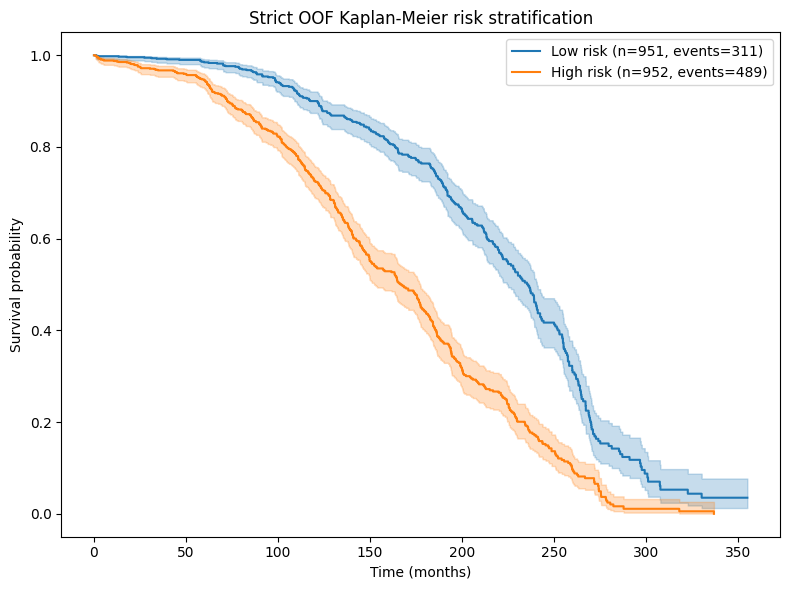

{'risk_threshold': 0.088258296251297, 'n_patients': 1903, 'n_high_risk': 952, 'n_low_risk': 951, 'high_risk_events': 489, 'low_risk_events': 311, 'logrank_statistic': 148.6449476827812, 'logrank_p_value': 3.428866734115164e-34, 'hazard_ratio': 2.3875208206838376, 'hazard_ratio_ci_lower_95': 2.0671572206029825, 'hazard_ratio_ci_upper_95': 2.7575336855781494, 'cox_p_value': 2.475543272039143e-32, 'lifelines_available': True}


,risk_threshold,n_patients,n_high_risk,n_low_risk,high_risk_events,low_risk_events,logrank_statistic,logrank_p_value,hazard_ratio,hazard_ratio_ci_lower_95,hazard_ratio_ci_upper_95,cox_p_value,lifelines_available
0,0.088258,1903,952,951,489,311,148.644948,3.428867e-34,2.387521,2.067157,2.757534,2.475543e-32,True


In [ ]:
# ============================================================
# Feature-selection stability and OOF Kaplan-Meier analysis
# ============================================================

def stability(
    tables: Sequence[pd.DataFrame],
    feature_column: str = "feature",
) -> pd.DataFrame:
    valid_tables = [
        table.copy()
        for table in tables
        if (
            isinstance(
                table,
                pd.DataFrame,
            )
            and not table.empty
        )
    ]

    output_columns = [
        feature_column,
        "selected_folds",
        "selection_frequency",
        "mean_score",
        "std_score",
        "mean_rank",
        "median_rank",
        "stable",
    ]

    if not valid_tables:
        return pd.DataFrame(
            columns=output_columns
        )

    combined = pd.concat(
        valid_tables,
        ignore_index=True,
        sort=False,
    )

    if feature_column not in combined.columns:
        raise KeyError(
            f"Missing required feature column: "
            f"{feature_column}"
        )

    if "fold" not in combined.columns:
        raise KeyError(
            "Feature-selection tables must contain "
            "a 'fold' column."
        )

    if "rank" not in combined.columns:
        combined["rank"] = np.nan

    if "score" not in combined.columns:
        combined["score"] = np.nan

    if "selected" in combined.columns:
        selected_mask = (
            combined[
                "selected"
            ]
            .fillna(False)
            .astype(bool)
        )

        combined = combined.loc[
            selected_mask
        ].copy()

    combined[
        feature_column
    ] = (
        combined[
            feature_column
        ]
        .astype("string")
        .str.strip()
    )

    combined = combined.loc[
        combined[
            feature_column
        ].notna()
        & combined[
            feature_column
        ].ne("")
        & combined[
            feature_column
        ].ne("nan")
    ].copy()

    if combined.empty:
        return pd.DataFrame(
            columns=output_columns
        )

    combined[
        "rank"
    ] = pd.to_numeric(
        combined["rank"],
        errors="coerce",
    )

    combined[
        "score"
    ] = pd.to_numeric(
        combined["score"],
        errors="coerce",
    )

    stability_table = (
        combined
        .groupby(
            feature_column,
            as_index=False,
        )
        .agg(
            selected_folds=(
                "fold",
                "nunique",
            ),
            mean_score=(
                "score",
                "mean",
            ),
            std_score=(
                "score",
                "std",
            ),
            mean_rank=(
                "rank",
                "mean",
            ),
            median_rank=(
                "rank",
                "median",
            ),
        )
    )

    actual_fold_count = max(
        len(fold_results),
        1,
    )

    stability_table[
        "selection_frequency"
    ] = (
        stability_table[
            "selected_folds"
        ]
        / actual_fold_count
    )

    stability_table[
        "stable"
    ] = (
        stability_table[
            "selection_frequency"
        ]
        >= float(
            CONFIG[
                "stable_feature_frequency"
            ]
        )
    )

    stability_table = (
        stability_table
        .sort_values(
            by=[
                "selection_frequency",
                "mean_rank",
                feature_column,
            ],
            ascending=[
                False,
                True,
                True,
            ],
            na_position="last",
        )
        .reset_index(
            drop=True
        )
    )

    return stability_table[
        output_columns
    ]


gene_stability = stability(
    [
        fold_result.genes
        for fold_result in fold_results
    ]
)

mutation_stability = stability(
    [
        fold_result.mutations
        for fold_result in fold_results
    ]
)

graph_gene_stability = stability(
    [
        fold_result.graph_genes
        for fold_result in fold_results
    ]
)


gene_stability.to_csv(
    CV / "gene_selection_stability.csv",
    index=False,
)

mutation_stability.to_csv(
    CV / "mutation_selection_stability.csv",
    index=False,
)

graph_gene_stability.to_csv(
    CV / "graph_gene_selection_stability.csv",
    index=False,
)


print(
    "Candidate prognostic features, not causal biomarkers."
)

display(
    gene_stability.head(20)
)

display(
    mutation_stability.head(20)
)

display(
    graph_gene_stability.head(20)
)


# ============================================================
# OOF Kaplan-Meier and univariable Cox analysis
# ============================================================

def km_analysis(
    predictions: pd.DataFrame,
    threshold: Optional[float] = None,
) -> Dict[str, Any]:
    required_columns = {
        "survival_time",
        "event",
        "risk_score",
    }

    missing_columns = sorted(
        required_columns.difference(
            predictions.columns
        )
    )

    if missing_columns:
        raise KeyError(
            "Predictions table is missing columns: "
            f"{missing_columns}"
        )

    analysis_predictions = (
        predictions[
            [
                "survival_time",
                "event",
                "risk_score",
            ]
        ]
        .copy()
    )

    analysis_predictions[
        "survival_time"
    ] = pd.to_numeric(
        analysis_predictions[
            "survival_time"
        ],
        errors="coerce",
    )

    analysis_predictions[
        "event"
    ] = pd.to_numeric(
        analysis_predictions[
            "event"
        ],
        errors="coerce",
    )

    analysis_predictions[
        "risk_score"
    ] = pd.to_numeric(
        analysis_predictions[
            "risk_score"
        ],
        errors="coerce",
    )

    analysis_predictions = (
        analysis_predictions
        .replace(
            [
                np.inf,
                -np.inf,
            ],
            np.nan,
        )
        .dropna()
        .reset_index(
            drop=True
        )
    )

    analysis_predictions = (
        analysis_predictions.loc[
            analysis_predictions[
                "survival_time"
            ] > 0
        ]
        .copy()
    )

    if analysis_predictions.empty:
        raise ValueError(
            "No valid observations are available "
            "for Kaplan-Meier analysis."
        )

    unique_events = set(
        analysis_predictions[
            "event"
        ]
        .astype(int)
        .unique()
        .tolist()
    )

    if not unique_events.issubset(
        {
            0,
            1,
        }
    ):
        raise ValueError(
            "The event column must contain only 0 and 1."
        )

    if threshold is None:
        threshold = float(
            analysis_predictions[
                "risk_score"
            ].median()
        )

    threshold = float(
        threshold
    )

    high_risk_mask = (
        analysis_predictions[
            "risk_score"
        ].to_numpy(
            dtype=np.float64
        )
        >= threshold
    )

    low_risk_mask = (
        ~high_risk_mask
    )

    result: Dict[
        str,
        Any,
    ] = {
        "risk_threshold": threshold,
        "n_patients": int(
            len(
                analysis_predictions
            )
        ),
        "n_high_risk": int(
            high_risk_mask.sum()
        ),
        "n_low_risk": int(
            low_risk_mask.sum()
        ),
        "high_risk_events": int(
            analysis_predictions.loc[
                high_risk_mask,
                "event",
            ].sum()
        ),
        "low_risk_events": int(
            analysis_predictions.loc[
                low_risk_mask,
                "event",
            ].sum()
        ),
        "logrank_statistic": np.nan,
        "logrank_p_value": np.nan,
        "hazard_ratio": np.nan,
        "hazard_ratio_ci_lower_95": np.nan,
        "hazard_ratio_ci_upper_95": np.nan,
        "cox_p_value": np.nan,
        "lifelines_available": bool(
            LIFELINES_AVAILABLE
        ),
    }

    if (
        high_risk_mask.sum() == 0
        or low_risk_mask.sum() == 0
    ):
        print(
            "[WARNING] Kaplan-Meier analysis skipped because "
            "one risk group is empty."
        )

        return result

    if not LIFELINES_AVAILABLE:
        print(
            "[WARNING] lifelines is unavailable. "
            "Kaplan-Meier, log-rank and Cox analyses were skipped."
        )

        return result

    plt.figure(
        figsize=(8, 6)
    )

    for label, group_mask in [
        (
            "Low risk",
            low_risk_mask,
        ),
        (
            "High risk",
            high_risk_mask,
        ),
    ]:
        group_size = int(
            group_mask.sum()
        )

        group_events = int(
            analysis_predictions.loc[
                group_mask,
                "event",
            ].sum()
        )

        km_estimator = KaplanMeierFitter(
            label=(
                f"{label} "
                f"(n={group_size}, "
                f"events={group_events})"
            )
        )

        km_estimator.fit(
            durations=(
                analysis_predictions.loc[
                    group_mask,
                    "survival_time",
                ]
            ),
            event_observed=(
                analysis_predictions.loc[
                    group_mask,
                    "event",
                ]
            ),
        )

        km_estimator.plot_survival_function(
            ci_show=True
        )

    plt.xlabel(
        "Time (months)"
    )

    plt.ylabel(
        "Survival probability"
    )

    plt.title(
        "Strict OOF Kaplan-Meier risk stratification"
    )

    plt.tight_layout()

    savefig(
        "kaplan_meier_oof_risk_groups.png"
    )

    logrank_result = logrank_test(
        durations_A=(
            analysis_predictions.loc[
                high_risk_mask,
                "survival_time",
            ]
        ),
        durations_B=(
            analysis_predictions.loc[
                low_risk_mask,
                "survival_time",
            ]
        ),
        event_observed_A=(
            analysis_predictions.loc[
                high_risk_mask,
                "event",
            ]
        ),
        event_observed_B=(
            analysis_predictions.loc[
                low_risk_mask,
                "event",
            ]
        ),
    )

    result[
        "logrank_statistic"
    ] = float(
        logrank_result
        .test_statistic
    )

    result[
        "logrank_p_value"
    ] = float(
        logrank_result
        .p_value
    )

    cox_frame = (
        analysis_predictions[
            [
                "survival_time",
                "event",
            ]
        ]
        .copy()
    )

    cox_frame[
        "high_risk"
    ] = high_risk_mask.astype(
        np.int64
    )

    if (
        cox_frame[
            "event"
        ].sum() > 0
    ):
        try:
            cox_model = CoxPHFitter()

            cox_model.fit(
                cox_frame,
                duration_col=(
                    "survival_time"
                ),
                event_col="event",
            )

            coefficient = float(
                cox_model.params_[
                    "high_risk"
                ]
            )

            confidence_interval = (
                cox_model
                .confidence_intervals_
                .loc[
                    "high_risk"
                ]
            )

            result[
                "hazard_ratio"
            ] = float(
                np.exp(
                    coefficient
                )
            )

            result[
                "hazard_ratio_ci_lower_95"
            ] = float(
                np.exp(
                    confidence_interval.iloc[
                        0
                    ]
                )
            )

            result[
                "hazard_ratio_ci_upper_95"
            ] = float(
                np.exp(
                    confidence_interval.iloc[
                        1
                    ]
                )
            )

            result[
                "cox_p_value"
            ] = float(
                cox_model.summary.loc[
                    "high_risk",
                    "p",
                ]
            )

        except Exception as error:
            result[
                "cox_error"
            ] = (
                f"{type(error).__name__}: "
                f"{error}"
            )

    return result


oof_risk_threshold = float(
    cv_predictions[
        "risk_score"
    ].median()
)


km_results = km_analysis(
    predictions=cv_predictions,
    threshold=oof_risk_threshold,
)


km_results_table = pd.DataFrame(
    [km_results]
)


km_results_table.to_csv(
    OUT / "kaplan_meier_results.csv",
    index=False,
)


print(
    km_results
)

display(
    km_results_table
)

## 25. Grouped survival calibration

## 26. Attention extraction and high-risk subgraph

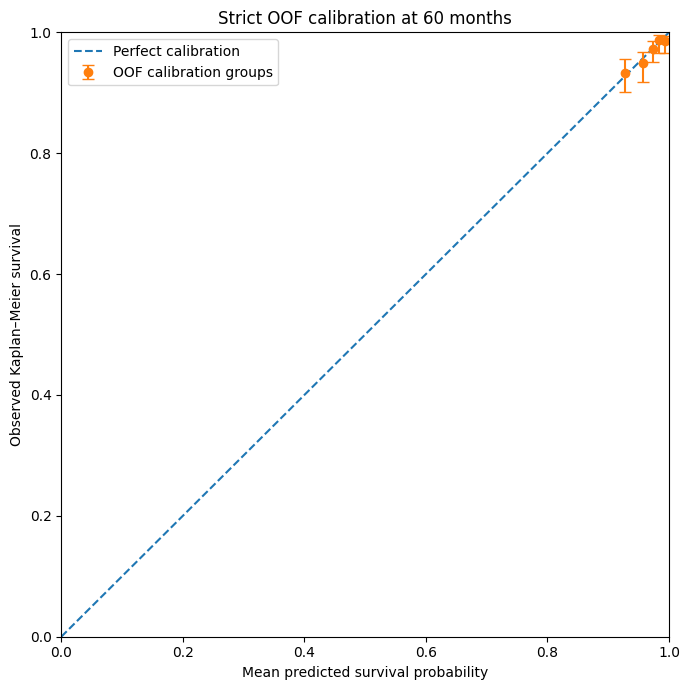

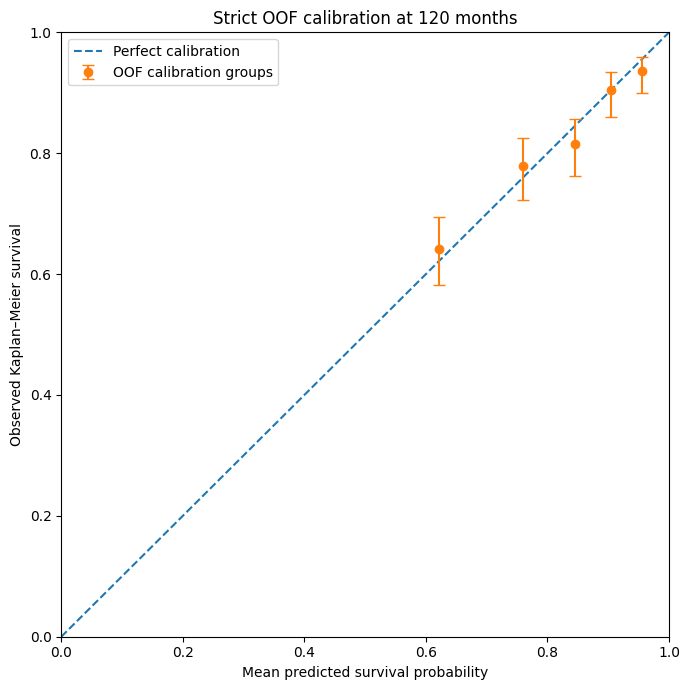

,horizon_months,n_groups,mean_absolute_calibration_error,weighted_absolute_calibration_error,maximum_absolute_calibration_error
0,60,5,0.005207,0.005206,0.009229
1,120,5,0.017847,0.017855,0.030777


,source_node,target_node,source_patient_id,target_patient_id,is_self_loop,attention_weight,attention_weight_max_head,attention_weight_std_heads,n_attention_heads,source_event,target_event,source_risk_score,target_risk_score,risk_score_difference,attention_head_1,attention_head_2,attention_head_3,attention_head_4,edge_attributes_aligned,clinical_similarity,expression_similarity,pathway_similarity,same_pam50,same_er_status,same_her2_status,mean_edge_similarity
19,4,4,8,8,True,1.0,1.0,0.0,4,0,0,0.965387,0.965387,0.0,1.0,1.0,1.0,1.0,True,1.0,1.0,1.0,1.0,1.0,1.0,1.0
38,8,8,28,28,True,1.0,1.0,0.0,4,0,0,0.211140,0.211140,0.0,1.0,1.0,1.0,1.0,True,1.0,1.0,1.0,1.0,1.0,1.0,1.0
39,9,9,35,35,True,1.0,1.0,0.0,4,0,0,-0.357942,-0.357942,0.0,1.0,1.0,1.0,1.0,True,1.0,1.0,1.0,1.0,1.0,1.0,1.0
40,10,10,36,36,True,1.0,1.0,0.0,4,0,0,0.858263,0.858263,0.0,1.0,1.0,1.0,1.0,True,1.0,1.0,1.0,1.0,1.0,1.0,1.0
46,13,13,46,46,True,1.0,1.0,0.0,4,0,0,1.350067,1.350067,0.0,1.0,1.0,1.0,1.0,True,1.0,1.0,1.0,1.0,1.0,1.0,1.0
97,22,22,66,66,True,1.0,1.0,0.0,4,1,1,0.825743,0.825743,0.0,1.0,1.0,1.0,1.0,True,1.0,1.0,1.0,1.0,1.0,1.0,1.0
129,29,29,97,97,True,1.0,1.0,0.0,4,1,1,0.347777,0.347777,0.0,1.0,1.0,1.0,1.0,True,1.0,1.0,1.0,1.0,1.0,1.0,1.0
134,31,31,101,101,True,1.0,1.0,0.0,4,1,1,1.472985,1.472985,0.0,1.0,1.0,1.0,1.0,True,1.0,1.0,1.0,1.0,1.0,1.0,1.0
135,32,32,102,102,True,1.0,1.0,0.0,4,0,0,0.052541,0.052541,0.0,1.0,1.0,1.0,1.0,True,1.0,1.0,1.0,1.0,1.0,1.0,1.0
149,36,36,109,109,True,1.0,1.0,0.0,4,0,0,0.272080,0.272080,0.0,1.0,1.0,1.0,1.0,True,1.0,1.0,1.0,1.0,1.0,1.0,1.0


Attention weights describe model information flow; they do not establish causality.


,source_node,target_node,source_patient_id,target_patient_id,is_self_loop,attention_weight,attention_weight_max_head,attention_weight_std_heads,n_attention_heads,source_event,target_event,source_risk_score,target_risk_score,risk_score_difference,attention_head_1,attention_head_2,attention_head_3,attention_head_4,edge_attributes_aligned,clinical_similarity,expression_similarity,pathway_similarity,same_pam50,same_er_status,same_her2_status,mean_edge_similarity
19,4,4,8,8,True,1.0,1.0,0.0,4,0,0,0.965387,0.965387,0.0,1.0,1.0,1.0,1.0,True,1.0,1.0,1.0,1.0,1.0,1.0,1.0
38,8,8,28,28,True,1.0,1.0,0.0,4,0,0,0.211140,0.211140,0.0,1.0,1.0,1.0,1.0,True,1.0,1.0,1.0,1.0,1.0,1.0,1.0
39,9,9,35,35,True,1.0,1.0,0.0,4,0,0,-0.357942,-0.357942,0.0,1.0,1.0,1.0,1.0,True,1.0,1.0,1.0,1.0,1.0,1.0,1.0
40,10,10,36,36,True,1.0,1.0,0.0,4,0,0,0.858263,0.858263,0.0,1.0,1.0,1.0,1.0,True,1.0,1.0,1.0,1.0,1.0,1.0,1.0
46,13,13,46,46,True,1.0,1.0,0.0,4,0,0,1.350067,1.350067,0.0,1.0,1.0,1.0,1.0,True,1.0,1.0,1.0,1.0,1.0,1.0,1.0
97,22,22,66,66,True,1.0,1.0,0.0,4,1,1,0.825743,0.825743,0.0,1.0,1.0,1.0,1.0,True,1.0,1.0,1.0,1.0,1.0,1.0,1.0
129,29,29,97,97,True,1.0,1.0,0.0,4,1,1,0.347777,0.347777,0.0,1.0,1.0,1.0,1.0,True,1.0,1.0,1.0,1.0,1.0,1.0,1.0
134,31,31,101,101,True,1.0,1.0,0.0,4,1,1,1.472985,1.472985,0.0,1.0,1.0,1.0,1.0,True,1.0,1.0,1.0,1.0,1.0,1.0,1.0
135,32,32,102,102,True,1.0,1.0,0.0,4,0,0,0.052541,0.052541,0.0,1.0,1.0,1.0,1.0,True,1.0,1.0,1.0,1.0,1.0,1.0,1.0
149,36,36,109,109,True,1.0,1.0,0.0,4,0,0,0.272080,0.272080,0.0,1.0,1.0,1.0,1.0,True,1.0,1.0,1.0,1.0,1.0,1.0,1.0


Attention weights describe model information flow; they do not establish causality or biomarker importance.


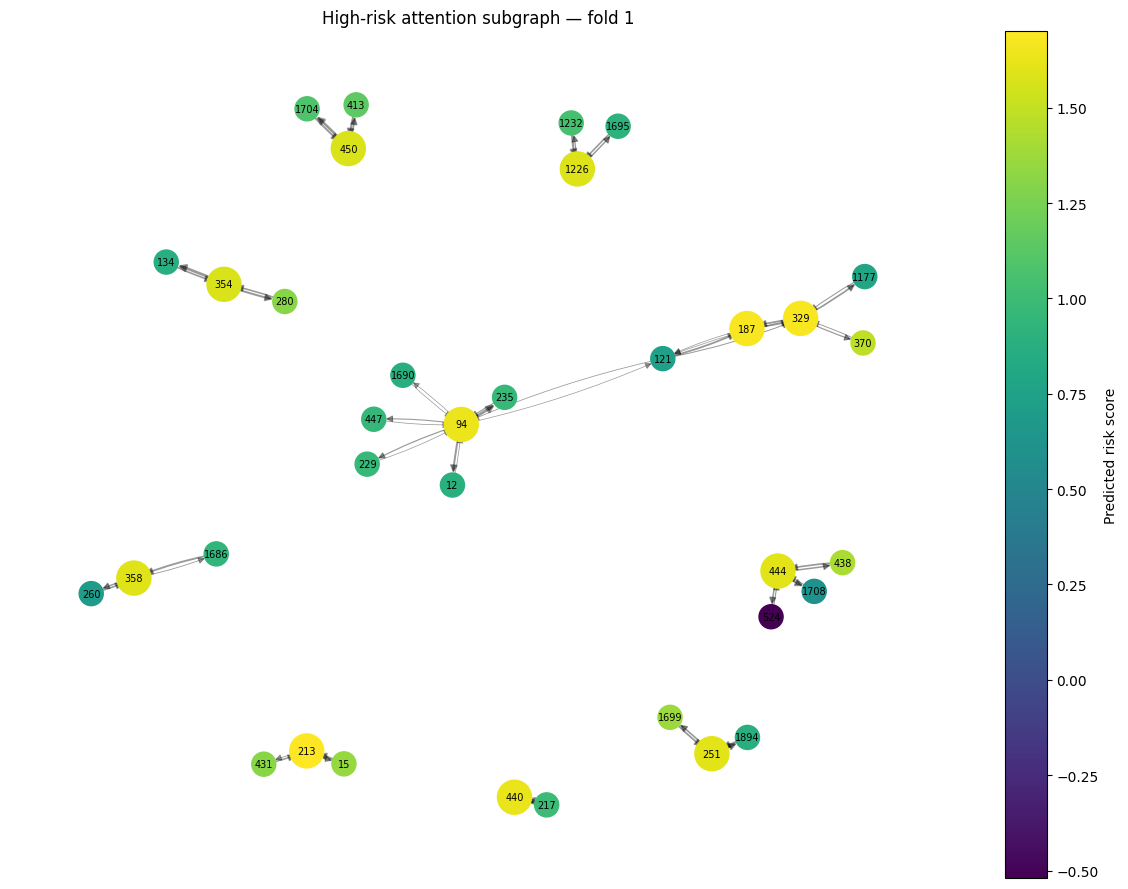

In [ ]:
# ============================================================
# OOF calibration, attention analysis and high-risk subgraph
# ============================================================

def calibration(
    predictions: pd.DataFrame,
    horizon: float,
    n_groups: int = 5,
) -> pd.DataFrame:
    horizon = float(
        horizon
    )

    horizon_key = int(
        round(horizon)
    )

    probability_column = (
        f"survival_probability_{horizon_key}m"
    )

    output_columns = [
        "horizon_months",
        "group",
        "n",
        "events",
        "predicted_survival",
        "observed_survival",
        "observed_ci_lower_95",
        "observed_ci_upper_95",
        "absolute_calibration_error",
    ]

    if not LIFELINES_AVAILABLE:
        print(
            f"[WARNING] Calibration at {horizon_key} months "
            "was skipped because lifelines is unavailable."
        )

        return pd.DataFrame(
            columns=output_columns
        )

    required_columns = {
        "survival_time",
        "event",
        probability_column,
    }

    missing_columns = sorted(
        required_columns.difference(
            predictions.columns
        )
    )

    if missing_columns:
        print(
            f"[WARNING] Calibration at {horizon_key} months "
            f"was skipped. Missing columns: {missing_columns}"
        )

        return pd.DataFrame(
            columns=output_columns
        )

    working = predictions[
        [
            "survival_time",
            "event",
            probability_column,
        ]
    ].copy()

    for column in working.columns:
        working[column] = pd.to_numeric(
            working[column],
            errors="coerce",
        )

    working = (
        working
        .replace(
            [
                np.inf,
                -np.inf,
            ],
            np.nan,
        )
        .dropna()
        .reset_index(
            drop=True
        )
    )

    working = working.loc[
        (working["survival_time"] > 0)
        & working["event"].isin(
            [
                0,
                1,
            ]
        )
        & working[
            probability_column
        ].between(
            0.0,
            1.0,
            inclusive="both",
        )
    ].copy()

    if working.empty:
        print(
            f"[WARNING] No valid observations for "
            f"calibration at {horizon_key} months."
        )

        return pd.DataFrame(
            columns=output_columns
        )

    unique_probability_count = int(
        working[
            probability_column
        ].nunique()
    )

    effective_groups = min(
        int(n_groups),
        unique_probability_count,
        len(working),
    )

    if effective_groups < 2:
        print(
            f"[WARNING] Insufficient probability variation for "
            f"calibration at {horizon_key} months."
        )

        return pd.DataFrame(
            columns=output_columns
        )

    try:
        working[
            "calibration_group"
        ] = pd.qcut(
            working[
                probability_column
            ],
            q=effective_groups,
            labels=False,
            duplicates="drop",
        )

    except ValueError as error:
        print(
            f"[WARNING] Calibration grouping failed at "
            f"{horizon_key} months: {error}"
        )

        return pd.DataFrame(
            columns=output_columns
        )

    working = working.dropna(
        subset=[
            "calibration_group",
        ]
    )

    working[
        "calibration_group"
    ] = (
        working[
            "calibration_group"
        ]
        .astype(int)
    )

    calibration_records: List[
        Dict[str, Any]
    ] = []

    for group_index, group_frame in working.groupby(
        "calibration_group",
        observed=True,
        sort=True,
    ):
        km_estimator = KaplanMeierFitter()

        km_estimator.fit(
            durations=group_frame[
                "survival_time"
            ],
            event_observed=group_frame[
                "event"
            ],
        )

        observed_survival = float(
            km_estimator.predict(
                horizon
            )
        )

        confidence_interval = (
            km_estimator
            .confidence_interval_survival_function_
        )

        eligible_times = (
            confidence_interval.index
            <= horizon
        )

        if eligible_times.any():
            confidence_row = (
                confidence_interval.loc[
                    eligible_times
                ]
                .iloc[-1]
            )

            observed_ci_lower = float(
                confidence_row.iloc[0]
            )

            observed_ci_upper = float(
                confidence_row.iloc[1]
            )

        else:
            observed_ci_lower = 1.0
            observed_ci_upper = 1.0

        predicted_survival = float(
            group_frame[
                probability_column
            ].mean()
        )

        calibration_records.append(
            {
                "horizon_months": horizon,
                "group": int(
                    group_index + 1
                ),
                "n": int(
                    len(group_frame)
                ),
                "events": int(
                    group_frame[
                        "event"
                    ].sum()
                ),
                "predicted_survival": (
                    predicted_survival
                ),
                "observed_survival": (
                    observed_survival
                ),
                "observed_ci_lower_95": (
                    observed_ci_lower
                ),
                "observed_ci_upper_95": (
                    observed_ci_upper
                ),
                "absolute_calibration_error": float(
                    abs(
                        predicted_survival
                        - observed_survival
                    )
                ),
            }
        )

    calibration_table = pd.DataFrame(
        calibration_records,
        columns=output_columns,
    )

    calibration_table.to_csv(
        OUT
        / f"calibration_{horizon_key}m.csv",
        index=False,
    )

    plt.figure(
        figsize=(7, 7)
    )

    plt.plot(
        [
            0,
            1,
        ],
        [
            0,
            1,
        ],
        linestyle="--",
        label="Perfect calibration",
    )

    if not calibration_table.empty:
        lower_error = (
            calibration_table[
                "observed_survival"
            ]
            - calibration_table[
                "observed_ci_lower_95"
            ]
        ).clip(
            lower=0.0
        )

        upper_error = (
            calibration_table[
                "observed_ci_upper_95"
            ]
            - calibration_table[
                "observed_survival"
            ]
        ).clip(
            lower=0.0
        )

        plt.errorbar(
            calibration_table[
                "predicted_survival"
            ],
            calibration_table[
                "observed_survival"
            ],
            yerr=np.vstack(
                [
                    lower_error,
                    upper_error,
                ]
            ),
            fmt="o",
            capsize=4,
            label="OOF calibration groups",
        )

    plt.xlim(
        0,
        1,
    )

    plt.ylim(
        0,
        1,
    )

    plt.xlabel(
        "Mean predicted survival probability"
    )

    plt.ylabel(
        "Observed Kaplan–Meier survival"
    )

    plt.title(
        f"Strict OOF calibration at "
        f"{horizon_key} months"
    )

    plt.legend()

    plt.tight_layout()

    savefig(
        f"calibration_{horizon_key}m.png"
    )

    return calibration_table


calibration_tables: Dict[
    int,
    pd.DataFrame,
] = {}


for horizon in CONFIG[
    "risk_horizons_months"
]:
    horizon_key = int(
        round(float(horizon))
    )

    calibration_tables[
        horizon_key
    ] = calibration(
        predictions=cv_predictions,
        horizon=float(horizon),
        n_groups=5,
    )


calibration_summary_records = []

for horizon_key, table in calibration_tables.items():
    if table.empty:
        continue

    calibration_summary_records.append(
        {
            "horizon_months": int(
                horizon_key
            ),
            "n_groups": int(
                len(table)
            ),
            "mean_absolute_calibration_error": float(
                table[
                    "absolute_calibration_error"
                ].mean()
            ),
            "weighted_absolute_calibration_error": float(
                np.average(
                    table[
                        "absolute_calibration_error"
                    ],
                    weights=table["n"],
                )
            ),
            "maximum_absolute_calibration_error": float(
                table[
                    "absolute_calibration_error"
                ].max()
            ),
        }
    )


calibration_summary = pd.DataFrame(
    calibration_summary_records
)


calibration_summary.to_csv(
    OUT / "calibration_summary.csv",
    index=False,
)


display(
    calibration_summary
)


# ============================================================
# Attention extraction compatible with positional GAT arguments
# ============================================================

def attention_table(
    model: nn.Module,
    data: Data,
    patient_frame: Optional[pd.DataFrame] = None,
    patient_identifier_column: Optional[str] = None,
) -> pd.DataFrame:
    model = model.to(
        DEVICE
    )

    data = data.to(
        DEVICE
    )

    model.eval()

    with torch.no_grad():
        model_output = model(
            data.x,
            data.edge_index,
            data.edge_attr,
            True,
        )

    if (
        not isinstance(
            model_output,
            tuple,
        )
        or len(model_output) < 2
    ):
        raise RuntimeError(
            "SurvivalGAT did not return attention weights. "
            "Its forward() method must return "
            "(risk_scores, (edge_index, attention_weights)) "
            "when the fourth positional argument is True."
        )

    risk_scores = model_output[0]

    attention_output = model_output[1]

    if (
        not isinstance(
            attention_output,
            tuple,
        )
        or len(attention_output) != 2
    ):
        raise RuntimeError(
            "The attention output must be "
            "(edge_index, attention_weights)."
        )

    returned_edge_index = (
        attention_output[0]
        .detach()
        .cpu()
        .numpy()
        .astype(np.int64)
    )

    raw_attention = (
        attention_output[1]
        .detach()
        .cpu()
        .numpy()
    )

    if raw_attention.ndim == 1:
        attention_by_head = (
            raw_attention.reshape(
                -1,
                1,
            )
        )

    elif raw_attention.ndim == 2:
        attention_by_head = (
            raw_attention
        )

    else:
        attention_by_head = (
            raw_attention.reshape(
                raw_attention.shape[0],
                -1,
            )
        )

    if (
        returned_edge_index.ndim != 2
        or returned_edge_index.shape[0] != 2
    ):
        raise RuntimeError(
            "Returned attention edge_index must have shape [2, E]."
        )

    if (
        attention_by_head.shape[0]
        != returned_edge_index.shape[1]
    ):
        raise RuntimeError(
            "The number of attention rows does not match "
            "the number of returned edges."
        )

    mean_attention = (
        attention_by_head.mean(
            axis=1
        )
    )

    maximum_attention = (
        attention_by_head.max(
            axis=1
        )
    )

    attention_standard_deviation = (
        attention_by_head.std(
            axis=1
        )
    )

    risk_numpy = (
        risk_scores
        .detach()
        .cpu()
        .numpy()
        .reshape(-1)
    )

    number_of_nodes = int(
        data.x.shape[0]
    )

    if patient_frame is None:
        patient_frame = analysis_df

    if len(patient_frame) != number_of_nodes:
        raise ValueError(
            "patient_frame must contain exactly one row per node."
        )

    if (
        patient_identifier_column is not None
        and patient_identifier_column
        in patient_frame.columns
    ):
        patient_ids = (
            patient_frame[
                patient_identifier_column
            ]
            .astype(str)
            .to_numpy()
        )

    else:
        patient_ids = np.arange(
            number_of_nodes
        ).astype(str)

    if hasattr(
        data,
        "event",
    ):
        event_values = (
            data.event
            .detach()
            .cpu()
            .numpy()
            .astype(np.int64)
        )

    else:
        event_values = np.full(
            number_of_nodes,
            -1,
            dtype=np.int64,
        )

    source_nodes = (
        returned_edge_index[0]
    )

    target_nodes = (
        returned_edge_index[1]
    )

    attention_frame = pd.DataFrame(
        {
            "source_node": source_nodes,
            "target_node": target_nodes,
            "source_patient_id": (
                patient_ids[
                    source_nodes
                ]
            ),
            "target_patient_id": (
                patient_ids[
                    target_nodes
                ]
            ),
            "is_self_loop": (
                source_nodes
                == target_nodes
            ),
            "attention_weight": (
                mean_attention
            ),
            "attention_weight_max_head": (
                maximum_attention
            ),
            "attention_weight_std_heads": (
                attention_standard_deviation
            ),
            "n_attention_heads": int(
                attention_by_head.shape[1]
            ),
            "source_event": (
                event_values[
                    source_nodes
                ]
            ),
            "target_event": (
                event_values[
                    target_nodes
                ]
            ),
            "source_risk_score": (
                risk_numpy[
                    source_nodes
                ]
            ),
            "target_risk_score": (
                risk_numpy[
                    target_nodes
                ]
            ),
            "risk_score_difference": (
                risk_numpy[
                    source_nodes
                ]
                - risk_numpy[
                    target_nodes
                ]
            ),
        }
    )

    for head_index in range(
        attention_by_head.shape[1]
    ):
        attention_frame[
            f"attention_head_{head_index + 1}"
        ] = attention_by_head[
            :,
            head_index,
        ]

    original_edge_index = (
        data.edge_index
        .detach()
        .cpu()
        .numpy()
        .astype(np.int64)
    )

    edge_attributes = (
        data.edge_attr
        .detach()
        .cpu()
        .numpy()
    )

    if edge_attributes.ndim == 1:
        edge_attributes = (
            edge_attributes.reshape(
                -1,
                1,
            )
        )

    edge_attributes_aligned = (
        returned_edge_index.shape
        == original_edge_index.shape
        and np.array_equal(
            returned_edge_index,
            original_edge_index,
        )
        and edge_attributes.shape[0]
        == returned_edge_index.shape[1]
    )

    attention_frame[
        "edge_attributes_aligned"
    ] = bool(
        edge_attributes_aligned
    )

    if edge_attributes_aligned:
        edge_feature_names = getattr(
            data,
            "edge_feature_names",
            None,
        )

        if edge_feature_names is None:
            edge_feature_names = [
                f"edge_feature_{index + 1}"
                for index in range(
                    edge_attributes.shape[1]
                )
            ]

        edge_feature_names = list(
            edge_feature_names
        )

        if (
            len(edge_feature_names)
            != edge_attributes.shape[1]
        ):
            edge_feature_names = [
                f"edge_feature_{index + 1}"
                for index in range(
                    edge_attributes.shape[1]
                )
            ]

        for feature_index, feature_name in enumerate(
            edge_feature_names
        ):
            attention_frame[
                feature_name
            ] = edge_attributes[
                :,
                feature_index,
            ]

        similarity_columns = [
            feature_name
            for feature_name in edge_feature_names
            if str(
                feature_name
            ).endswith(
                "_similarity"
            )
        ]

        if similarity_columns:
            attention_frame[
                "mean_edge_similarity"
            ] = (
                attention_frame[
                    similarity_columns
                ]
                .mean(
                    axis=1
                )
            )

    model.cpu()
    data.cpu()

    if DEVICE.type == "cuda":
        torch.cuda.empty_cache()

    return attention_frame


# ============================================================
# Extract and save fold-1 attention
# ============================================================

attention_weights = attention_table(
    model=fold_results[0].model,
    data=fold_results[0].data,
    patient_frame=analysis_df,
    patient_identifier_column=patient_id_col,
)


attention_weights.to_csv(
    OUT / "attention_weights_fold_1.csv",
    index=False,
)


display(
    attention_weights.nlargest(
        20,
        "attention_weight",
    )
)


print(
    "Attention weights describe model information flow; "
    "they do not establish causality."
)

# ============================================================
# Export first-fold attention for strict held-out interpretation
# ============================================================

attention_weights = attention_table(
    model=fold_results[0].model,
    data=fold_results[0].data,
    patient_frame=analysis_df,
    patient_identifier_column=patient_id_col,
)


attention_weights.to_csv(
    OUT / "attention_weights_fold_1.csv",
    index=False,
)


display(
    attention_weights.nlargest(
        20,
        "attention_weight",
    )
)


print(
    "Attention weights describe model information flow; "
    "they do not establish causality or biomarker importance."
)


# ============================================================
# High-risk attention subgraph
# ============================================================

non_self_attention = (
    attention_weights.loc[
        ~attention_weights[
            "is_self_loop"
        ]
    ]
    .copy()
)


risk_by_node = (
    attention_weights
    .groupby(
        "source_node"
    )[
        "source_risk_score"
    ]
    .first()
)


number_of_high_risk_nodes = min(
    15,
    len(risk_by_node),
)


high_risk_nodes = set(
    risk_by_node.nlargest(
        number_of_high_risk_nodes
    ).index.astype(int)
)


candidate_edges = (
    non_self_attention.loc[
        non_self_attention[
            "source_node"
        ].isin(
            high_risk_nodes
        )
        | non_self_attention[
            "target_node"
        ].isin(
            high_risk_nodes
        )
    ]
    .nlargest(
        80,
        "attention_weight",
    )
    .copy()
)


attention_graph = nx.DiGraph()


for edge_row in candidate_edges.itertuples(
    index=False
):
    source_node = int(
        edge_row.source_node
    )

    target_node = int(
        edge_row.target_node
    )

    edge_weight = float(
        edge_row.attention_weight
    )

    if attention_graph.has_edge(
        source_node,
        target_node,
    ):
        if (
            edge_weight
            > attention_graph[
                source_node
            ][
                target_node
            ][
                "weight"
            ]
        ):
            attention_graph[
                source_node
            ][
                target_node
            ][
                "weight"
            ] = edge_weight

    else:
        attention_graph.add_edge(
            source_node,
            target_node,
            weight=edge_weight,
        )


if attention_graph.number_of_nodes() > 0:
    plt.figure(
        figsize=(12, 9)
    )

    graph_positions = nx.spring_layout(
        attention_graph,
        seed=int(
            CONFIG["seed"]
        ),
        weight="weight",
    )

    node_risk_values = [
        float(
            risk_by_node.get(
                node,
                0.0,
            )
        )
        for node in attention_graph.nodes()
    ]

    node_sizes = [
        600
        if node in high_risk_nodes
        else 300
        for node in attention_graph.nodes()
    ]

    edge_widths = [
        max(
            0.5,
            4.0
            * float(
                edge_data[
                    "weight"
                ]
            ),
        )
        for _, _, edge_data
        in attention_graph.edges(
            data=True
        )
    ]

    node_collection = (
        nx.draw_networkx_nodes(
            attention_graph,
            graph_positions,
            node_size=node_sizes,
            node_color=node_risk_values,
            cmap="viridis",
        )
    )

    nx.draw_networkx_edges(
        attention_graph,
        graph_positions,
        width=edge_widths,
        alpha=0.40,
        arrows=True,
        arrowsize=10,
        connectionstyle=(
            "arc3,rad=0.05"
        ),
    )

    nx.draw_networkx_labels(
        attention_graph,
        graph_positions,
        font_size=7,
    )

    plt.colorbar(
        node_collection,
        label="Predicted risk score",
    )

    plt.axis(
        "off"
    )

    plt.title(
        "High-risk attention subgraph — fold 1"
    )

    plt.tight_layout()

    savefig(
        "high_risk_attention_subgraph.png"
    )

else:
    print(
        "[WARNING] No non-self attention edges were available "
        "for the high-risk subgraph."
    )

## 27. MLP baselines and ablation

## 28. Fit the final model

In [ ]:
# ============================================================
# MLP baselines, ablation study and final SurvivalGAT training
# ============================================================

class SurvivalMLP(nn.Module):
    def __init__(
        self,
        input_dim: int,
    ):
        super().__init__()

        if not isinstance(
            input_dim,
            int,
        ) or input_dim <= 0:
            raise ValueError(
                "input_dim must be a strictly positive integer."
            )

        hidden_dim = int(
            CONFIG["hidden_channels"]
        )

        dropout = float(
            CONFIG["dropout"]
        )

        if hidden_dim < 8:
            raise ValueError(
                "CONFIG['hidden_channels'] must be at least 8."
            )

        bottleneck_dim = max(
            hidden_dim // 2,
            8,
        )

        # ----------------------------------------------------
        # Initial feature projection
        # ----------------------------------------------------

        self.input_block = nn.Sequential(
            nn.LayerNorm(
                input_dim
            ),
            nn.Linear(
                input_dim,
                hidden_dim,
            ),
            nn.GELU(),
            nn.Dropout(
                dropout
            ),
        )

        # ----------------------------------------------------
        # Patient-specific feature gate
        # ----------------------------------------------------

        self.feature_gate = nn.Sequential(
            nn.Linear(
                hidden_dim,
                hidden_dim,
            ),
            nn.Sigmoid(),
        )

        # ----------------------------------------------------
        # Residual block 1
        # ----------------------------------------------------

        self.residual_block_1 = nn.Sequential(
            nn.LayerNorm(
                hidden_dim
            ),
            nn.Linear(
                hidden_dim,
                hidden_dim * 2,
            ),
            nn.GELU(),
            nn.Dropout(
                dropout
            ),
            nn.Linear(
                hidden_dim * 2,
                hidden_dim,
            ),
            nn.Dropout(
                dropout
            ),
        )

        # ----------------------------------------------------
        # Residual block 2
        # ----------------------------------------------------

        self.residual_block_2 = nn.Sequential(
            nn.LayerNorm(
                hidden_dim
            ),
            nn.Linear(
                hidden_dim,
                hidden_dim * 2,
            ),
            nn.GELU(),
            nn.Dropout(
                dropout
            ),
            nn.Linear(
                hidden_dim * 2,
                hidden_dim,
            ),
            nn.Dropout(
                dropout
            ),
        )

        # ----------------------------------------------------
        # Final survival-risk head
        # ----------------------------------------------------

        self.risk_head = nn.Sequential(
            nn.LayerNorm(
                hidden_dim
            ),
            nn.Linear(
                hidden_dim,
                bottleneck_dim,
            ),
            nn.GELU(),
            nn.Dropout(
                dropout
            ),
            nn.Linear(
                bottleneck_dim,
                1,
            ),
        )

        self.reset_parameters()

    def reset_parameters(
        self,
    ) -> None:
        for module in self.modules():
            if isinstance(
                module,
                nn.Linear,
            ):
                nn.init.xavier_uniform_(
                    module.weight
                )

                if module.bias is not None:
                    nn.init.zeros_(
                        module.bias
                    )

    def forward(
        self,
        x: torch.Tensor,
    ) -> torch.Tensor:
        if x.ndim != 2:
            raise ValueError(
                "SurvivalMLP expects a 2D tensor "
                "with shape [patients, features]."
            )

        # Initial patient representation
        hidden = self.input_block(
            x
        )

        # Feature-wise adaptive gating
        gate = self.feature_gate(
            hidden
        )

        hidden = hidden * (
            1.0 + gate
        )

        # Residual nonlinear transformations
        residual_1 = self.residual_block_1(
            hidden
        )

        hidden = hidden + residual_1

        residual_2 = self.residual_block_2(
            hidden
        )

        hidden = hidden + residual_2

        # Unbounded Cox risk score
        risk = self.risk_head(
            hidden
        )

        return risk.reshape(-1)

@dataclass
class MLPTrainResult:
    model: Any
    risk_scores: np.ndarray
    history: pd.DataFrame
    best_epoch: int
    best_validation_c_index: float


def train_mlp(
    X: np.ndarray,
    t: Sequence[float],
    e: Sequence[int],
    tr: Sequence[bool],
    va: Sequence[bool],
    name: str,
    max_epochs: int = 250,
    patience: int = 35,
) -> MLPTrainResult:
    seed_everything(
        CONFIG["seed"]
    )

    feature_matrix = np.asarray(
        X,
        dtype=np.float32,
    )

    times = np.asarray(
        t,
        dtype=np.float32,
    ).reshape(-1)

    events = np.asarray(
        e,
        dtype=np.float32,
    ).reshape(-1)

    train_mask = np.asarray(
        tr,
        dtype=bool,
    ).reshape(-1)

    validation_mask = np.asarray(
        va,
        dtype=bool,
    ).reshape(-1)

    if feature_matrix.ndim != 2:
        raise ValueError(
            "X must be a two-dimensional matrix."
        )

    n_patients = feature_matrix.shape[0]

    if not (
        len(times)
        == len(events)
        == len(train_mask)
        == len(validation_mask)
        == n_patients
    ):
        raise ValueError(
            "X, t, e, tr and va must contain the same rows."
        )

    if feature_matrix.shape[1] == 0:
        raise ValueError(
            f"{name} received an empty feature matrix."
        )

    if not np.isfinite(
        feature_matrix
    ).all():
        raise ValueError(
            f"{name} feature matrix contains non-finite values."
        )

    if not np.isfinite(
        times
    ).all() or np.any(times <= 0.0):
        raise ValueError(
            "Survival times must be finite and strictly positive."
        )

    if not set(
        np.unique(events).tolist()
    ).issubset({0.0, 1.0}):
        raise ValueError(
            "Events must contain only 0 and 1."
        )

    if np.any(
        train_mask & validation_mask
    ):
        raise ValueError(
            "Training and validation masks overlap."
        )

    if not train_mask.any():
        raise ValueError(
            "The MLP training mask is empty."
        )

    if not validation_mask.any():
        raise ValueError(
            "The MLP validation mask is empty."
        )

    if events[train_mask].sum() < 1:
        raise ValueError(
            "The MLP training split contains no event."
        )

    x_tensor = torch.as_tensor(
        feature_matrix,
        dtype=torch.float32,
        device=DEVICE,
    )

    time_tensor = torch.as_tensor(
        times,
        dtype=torch.float32,
        device=DEVICE,
    )

    event_tensor = torch.as_tensor(
        events,
        dtype=torch.float32,
        device=DEVICE,
    )

    train_mask_tensor = torch.as_tensor(
        train_mask,
        dtype=torch.bool,
        device=DEVICE,
    )

    model = SurvivalMLP(
        input_dim=feature_matrix.shape[1],
    ).to(DEVICE)

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=float(
            CONFIG["learning_rate"]
        ),
        weight_decay=float(
            CONFIG["weight_decay"]
        ),
    )

    scheduler = (
        torch.optim.lr_scheduler.ReduceLROnPlateau(
            optimizer,
            mode="max",
            factor=0.5,
            patience=max(
                8,
                patience // 4,
            ),
        )
    )

    scaler = make_grad_scaler()

    best_validation_c_index = -np.inf
    best_state = None
    best_epoch = 0
    waiting_epochs = 0

    history_records: List[
        Dict[str, Any]
    ] = []

    for epoch in range(
        1,
        max_epochs + 1,
    ):
        model.train()

        optimizer.zero_grad(
            set_to_none=True
        )

        with autocast_context():
            risk_scores = model(
                x_tensor
            )

            cox_component = cox_loss(
                risk=risk_scores,
                time=time_tensor,
                event=event_tensor,
                mask=train_mask_tensor,
            )

            if (
                CONFIG["survival_loss_type"]
                == "cox_plus_ranking"
                and float(
                    CONFIG[
                        "ranking_loss_weight"
                    ]
                ) > 0.0
            ):
                ranking_component = (
                    pairwise_ranking_loss(
                        risk=risk_scores,
                        time=time_tensor,
                        event=event_tensor,
                        mask=train_mask_tensor,
                    )
                )
            else:
                ranking_component = (
                    risk_scores.sum()
                    * 0.0
                )

            total_loss = (
                cox_component
                + float(
                    CONFIG[
                        "ranking_loss_weight"
                    ]
                )
                * ranking_component
            )

        if not torch.isfinite(
            total_loss
        ):
            raise FloatingPointError(
                f"{name} produced a non-finite loss "
                f"at epoch {epoch}."
            )

        scaler.scale(
            total_loss
        ).backward()

        scaler.unscale_(
            optimizer
        )

        gradient_norm = (
            torch.nn.utils.clip_grad_norm_(
                model.parameters(),
                max_norm=float(
                    CONFIG[
                        "gradient_clip_norm"
                    ]
                ),
            )
        )

        scaler.step(
            optimizer
        )

        scaler.update()

        model.eval()

        with torch.no_grad():
            all_risks = (
                model(x_tensor)
                .detach()
                .cpu()
                .numpy()
            )

        validation_c_index = cindex(
            times[validation_mask],
            events[
                validation_mask
            ].astype(int),
            all_risks[
                validation_mask
            ],
        )

        scheduler.step(
            validation_c_index
            if np.isfinite(
                validation_c_index
            )
            else -1e12
        )

        history_records.append(
            {
                "epoch": int(epoch),
                "training_loss": float(
                    total_loss
                    .detach()
                    .cpu()
                    .item()
                ),
                "cox_training_loss": float(
                    cox_component
                    .detach()
                    .cpu()
                    .item()
                ),
                "ranking_training_loss": float(
                    ranking_component
                    .detach()
                    .cpu()
                    .item()
                ),
                "validation_c_index": (
                    float(
                        validation_c_index
                    )
                    if np.isfinite(
                        validation_c_index
                    )
                    else np.nan
                ),
                "learning_rate": float(
                    optimizer.param_groups[
                        0
                    ]["lr"]
                ),
                "gradient_norm": float(
                    torch.as_tensor(
                        gradient_norm
                    )
                    .detach()
                    .cpu()
                    .item()
                ),
            }
        )

        if (
            np.isfinite(
                validation_c_index
            )
            and validation_c_index
            > best_validation_c_index
            + 1e-6
        ):
            best_validation_c_index = float(
                validation_c_index
            )

            best_state = copy.deepcopy(
                model.state_dict()
            )

            best_epoch = int(
                epoch
            )

            waiting_epochs = 0

        else:
            waiting_epochs += 1

        if (
            epoch == 1
            or epoch
            % int(
                CONFIG["print_every"]
            )
            == 0
        ):
            print(
                name,
                "epoch=",
                epoch,
                "loss=",
                round(
                    float(
                        total_loss
                        .detach()
                        .cpu()
                        .item()
                    ),
                    6,
                ),
                "val_c_index=",
                (
                    round(
                        float(
                            validation_c_index
                        ),
                        6,
                    )
                    if np.isfinite(
                        validation_c_index
                    )
                    else np.nan
                ),
            )

        if waiting_epochs >= patience:
            break

    if best_state is None:
        raise RuntimeError(
            f"{name} did not produce a valid "
            "validation checkpoint."
        )

    model.load_state_dict(
        best_state
    )

    model.eval()

    with torch.no_grad():
        final_risk_scores = (
            model(x_tensor)
            .detach()
            .cpu()
            .numpy()
            .astype(np.float64)
        )

    history = pd.DataFrame(
        history_records
    )

    history.to_csv(
        OUT
        / f"{name}_training_history.csv",
        index=False,
    )

    model = model.cpu()

    del x_tensor
    del time_tensor
    del event_tensor
    del train_mask_tensor

    if DEVICE.type == "cuda":
        torch.cuda.empty_cache()

    return MLPTrainResult(
        model=model,
        risk_scores=final_risk_scores,
        history=history,
        best_epoch=best_epoch,
        best_validation_c_index=float(
            best_validation_c_index
        ),
    )


# ============================================================
# MLP and GAT ablation study
# ============================================================

ablation_records: List[
    Dict[str, Any]
] = []


if CONFIG["run_ablation_study"]:
    horizons = np.asarray(
        CONFIG[
            "risk_horizons_months"
        ],
        dtype=np.float64,
    )

    for fold_number, fold_result in enumerate(
        fold_results,
        start=1,
    ):
        fold_data = fold_result.data

        train_mask = (
            fold_data.train_mask
            .numpy()
            .astype(bool)
        )

        validation_mask = (
            fold_data.val_mask
            .numpy()
            .astype(bool)
        )

        heldout_mask = (
            fold_data.test_mask
            .numpy()
            .astype(bool)
        )

        X_all = (
            fold_data.x
            .numpy()
            .astype(np.float32)
        )

        fold_times = (
            fold_data.survival_time
            .numpy()
            .astype(np.float64)
        )

        fold_events = (
            fold_data.event
            .numpy()
            .astype(np.int64)
        )

        clinical_start, clinical_end = (
            fold_result
            .preprocessor
            .modality_slices[
                "clinical"
            ]
        )

        X_clinical = X_all[
            :,
            clinical_start:clinical_end,
        ]

        mlp_experiments = [
            (
                "clinical_only_mlp",
                X_clinical,
            ),
            (
                "full_feature_mlp",
                X_all,
            ),
        ]

        for model_name, model_features in mlp_experiments:
            mlp_result = train_mlp(
                X=model_features,
                t=fold_times,
                e=fold_events,
                tr=train_mask,
                va=validation_mask,
                name=(
                    f"fold_{fold_number}_"
                    f"{model_name}"
                ),
                max_epochs=250,
                patience=35,
            )

            mlp_risk = (
                mlp_result.risk_scores
            )

            heldout_survival_probabilities = (
                cox_survival_probabilities_with_training_reference(
                    training_times=fold_times[
                        train_mask
                    ],
                    training_events=fold_events[
                        train_mask
                    ],
                    training_risks=mlp_risk[
                        train_mask
                    ],
                    evaluation_risks=mlp_risk[
                        heldout_mask
                    ],
                    horizons=horizons,
                )
            )

            mlp_metrics = {
                "fold": int(
                    fold_number
                ),
                "model": model_name,
                "n_train": int(
                    train_mask.sum()
                ),
                "n_validation": int(
                    validation_mask.sum()
                ),
                "n_heldout": int(
                    heldout_mask.sum()
                ),
                "heldout_events": int(
                    fold_events[
                        heldout_mask
                    ].sum()
                ),
                "c_index": cindex(
                    fold_times[
                        heldout_mask
                    ],
                    fold_events[
                        heldout_mask
                    ],
                    mlp_risk[
                        heldout_mask
                    ],
                ),
                "best_epoch": int(
                    mlp_result.best_epoch
                ),
                "best_validation_c_index": float(
                    mlp_result
                    .best_validation_c_index
                ),
            }

            mlp_time_metrics = td_metrics(
                trt=fold_times[
                    train_mask
                ],
                tre=fold_events[
                    train_mask
                ],
                tst=fold_times[
                    heldout_mask
                ],
                tse=fold_events[
                    heldout_mask
                ],
                r=mlp_risk[
                    heldout_mask
                ],
                sp=(
                    heldout_survival_probabilities
                ),
                h=horizons,
            )

            mlp_metrics.update(
                mlp_time_metrics
            )

            ablation_records.append(
                mlp_metrics
            )

        gat_record = {
            "fold": int(
                fold_number
            ),
            "model": (
                "full_survival_gat"
            ),
            "n_train": int(
                train_mask.sum()
            ),
            "n_validation": int(
                validation_mask.sum()
            ),
            "n_heldout": int(
                heldout_mask.sum()
            ),
            "heldout_events": int(
                fold_events[
                    heldout_mask
                ].sum()
            ),
            "c_index": fold_result.metrics[
                "heldout_c_index"
            ],
            "best_epoch": fold_result.metrics[
                "best_epoch"
            ],
            "best_validation_c_index": (
                fold_result.metrics[
                    "best_validation_c_index"
                ]
            ),
        }

        for horizon in horizons:
            horizon_key = int(
                round(float(horizon))
            )

            gat_record[
                f"auc_{horizon_key}m"
            ] = fold_result.metrics.get(
                f"auc_{horizon_key}m",
                np.nan,
            )

            gat_record[
                f"brier_{horizon_key}m"
            ] = fold_result.metrics.get(
                f"brier_{horizon_key}m",
                np.nan,
            )

        gat_record[
            "integrated_brier_score"
        ] = fold_result.metrics.get(
            "integrated_brier_score",
            np.nan,
        )

        ablation_records.append(
            gat_record
        )


ablation_results = pd.DataFrame(
    ablation_records
)


if not ablation_results.empty:
    aggregation_spec = {
        "mean_c_index": (
            "c_index",
            "mean",
        ),
        "std_c_index": (
            "c_index",
            "std",
        ),
    }

    for horizon in CONFIG[
        "risk_horizons_months"
    ]:
        horizon_key = int(
            round(float(horizon))
        )

        auc_column = (
            f"auc_{horizon_key}m"
        )

        brier_column = (
            f"brier_{horizon_key}m"
        )

        if auc_column in ablation_results.columns:
            aggregation_spec[
                f"mean_auc_{horizon_key}m"
            ] = (
                auc_column,
                "mean",
            )

            aggregation_spec[
                f"std_auc_{horizon_key}m"
            ] = (
                auc_column,
                "std",
            )

        if brier_column in ablation_results.columns:
            aggregation_spec[
                f"mean_brier_{horizon_key}m"
            ] = (
                brier_column,
                "mean",
            )

            aggregation_spec[
                f"std_brier_{horizon_key}m"
            ] = (
                brier_column,
                "std",
            )

    if (
        "integrated_brier_score"
        in ablation_results.columns
    ):
        aggregation_spec[
            "mean_integrated_brier_score"
        ] = (
            "integrated_brier_score",
            "mean",
        )

        aggregation_spec[
            "std_integrated_brier_score"
        ] = (
            "integrated_brier_score",
            "std",
        )

    ablation_summary = (
        ablation_results
        .groupby(
            "model",
            as_index=False,
        )
        .agg(
            **aggregation_spec
        )
    )

else:
    ablation_summary = pd.DataFrame()


ablation_results.to_csv(
    OUT / "ablation_results.csv",
    index=False,
)

ablation_summary.to_csv(
    OUT / "ablation_summary.csv",
    index=False,
)

display(
    ablation_summary
)


# ============================================================
# Final model: train/validation split for checkpoint selection
# ============================================================

all_indices = np.arange(
    len(analysis_df),
    dtype=np.int64,
)


final_train_indices, final_validation_indices = (
    train_test_split(
        all_indices,
        test_size=float(
            CONFIG[
                "validation_size_within_train"
            ]
        ),
        random_state=int(
            CONFIG["seed"]
        ),
        stratify=strata(
            times_all,
            events_all,
        ),
    )
)


final_training_frame = analysis_df.iloc[
    final_train_indices
]


final_preprocessor, _ = fit_preprocessor(
    train=final_training_frame,
    times=final_training_frame[
        "survival_time"
    ].to_numpy(
        dtype=np.float64
    ),
    events=final_training_frame[
        "event"
    ].to_numpy(
        dtype=np.int64
    ),
    top_k_node_genes=int(
        CONFIG[
            "top_k_node_genes"
        ]
    ),
    top_k_graph_genes=int(
        CONFIG[
            "top_k_graph_genes"
        ]
    ),
    coxnet_alpha=CONFIG.get(
        "cox_elastic_net_alpha"
    ),
)


final_matrices = transform_preprocessor(
    frame=analysis_df,
    artifact=final_preprocessor,
)


for matrix_name in [
    "X_node",
    "X_graph_clinical",
    "X_graph_expression",
    "X_graph_pathway",
]:
    validate(
        final_matrices[
            matrix_name
        ],
        len(analysis_df),
        matrix_name,
    )


(
    final_edge_index,
    final_edge_attr,
    final_edge_feature_names,
    final_graph_diagnostics,
) = build_multiview_graph(
    Xc=final_matrices[
        "X_graph_clinical"
    ],
    Xe=final_matrices[
        "X_graph_expression"
    ],
    Xp=final_matrices[
        "X_graph_pathway"
    ],
    events=events_all,
    metadata_frame=analysis_df,
)


(
    final_train_mask,
    final_validation_mask,
    final_test_mask,
) = masks(
    n=len(analysis_df),
    tr=final_train_indices,
    va=final_validation_indices,
    te=np.asarray(
        [],
        dtype=np.int64,
    ),
)


final_data = make_data(
    X=final_matrices[
        "X_node"
    ],
    ei=final_edge_index,
    ea=final_edge_attr,
    t=times_all.astype(
        np.float32
    ),
    e=events_all.astype(
        np.float32
    ),
    tr=final_train_mask,
    va=final_validation_mask,
    te=final_test_mask,
    edge_feature_names=(
        final_edge_feature_names
    ),
)


final_training = train_gat(
    data=final_data,
    name="final_model",
    max_epochs=int(
        CONFIG["max_epochs"]
    ),
    modality_slices=(
        final_preprocessor
        .modality_slices
    ),
)


final_model = final_training.model.to(
    DEVICE
)

final_device_data = final_data.to(
    DEVICE
)

final_model.eval()


with torch.no_grad():
    final_risk = (
        final_model(
            final_device_data.x,
            final_device_data.edge_index,
            final_device_data.edge_attr,
        )
        .detach()
        .cpu()
        .numpy()
    )


final_validation_c_index = cindex(
    times_all[
        final_validation_mask
    ],
    events_all[
        final_validation_mask
    ],
    final_risk[
        final_validation_mask
    ],
)


print(
    "Final validation C-index:",
    (
        f"{final_validation_c_index:.4f}"
        if np.isfinite(
            final_validation_c_index
        )
        else "NaN"
    ),
)


final_graph_diagnostics.to_csv(
    OUT
    / "final_graph_diagnostics.csv",
    index=False,
)


joblib.dump(
    final_preprocessor,
    ART
    / "final_preprocessor.joblib",
)


torch.save(
    {
        "state": copy.deepcopy(
            final_model.state_dict()
        ),
        "in_channels": int(
            final_data.x.shape[1]
        ),
        "edge_dim": int(
            final_data.edge_attr.shape[1]
        ),
        "edge_feature_names": (
            final_edge_feature_names
        ),
        "modality_slices": (
            final_preprocessor
            .modality_slices
        ),
        "hidden_channels": int(
            CONFIG[
                "hidden_channels"
            ]
        ),
        "gat_heads": int(
            CONFIG[
                "gat_heads"
            ]
        ),
        "dropout": float(
            CONFIG[
                "dropout"
            ]
        ),
        "residual_scale": float(
            CONFIG[
                "initial_residual_scale"
            ]
        ),
        "best_epoch": int(
            final_training.best_epoch
        ),
        "validation_c_index": (
            float(
                final_validation_c_index
            )
            if np.isfinite(
                final_validation_c_index
            )
            else None
        ),
    },
    CHECKPOINTS
    / "final_survival_gat_complete.pt",
)


final_model = final_model.cpu()
final_data = final_data.cpu()

if DEVICE.type == "cuda":
    torch.cuda.empty_cache()

fold_1_clinical_only_mlp epoch= 1 loss= 6.518376 val_c_index= 0.541065
fold_1_clinical_only_mlp epoch= 25 loss= 6.013957 val_c_index= 0.577629
fold_1_clinical_only_mlp epoch= 50 loss= 5.849031 val_c_index= 0.561789
fold_1_full_feature_mlp epoch= 1 loss= 6.393332 val_c_index= 0.485381
fold_1_full_feature_mlp epoch= 25 loss= 5.854056 val_c_index= 0.614472
fold_1_full_feature_mlp epoch= 50 loss= 5.735734 val_c_index= 0.641197
fold_1_full_feature_mlp epoch= 75 loss= 5.669324 val_c_index= 0.648734
fold_1_full_feature_mlp epoch= 100 loss= 5.57527 val_c_index= 0.654386
fold_1_full_feature_mlp epoch= 125 loss= 5.564272 val_c_index= 0.656758
fold_1_full_feature_mlp epoch= 150 loss= 5.537173 val_c_index= 0.659828
fold_1_full_feature_mlp epoch= 175 loss= 5.467921 val_c_index= 0.661573
fold_1_full_feature_mlp epoch= 200 loss= 5.535061 val_c_index= 0.661503
fold_2_clinical_only_mlp epoch= 1 loss= 6.492961 val_c_index= 0.489601
fold_2_clinical_only_mlp epoch= 25 loss= 6.030443 val_c_index= 0.541808


,model,mean_c_index,std_c_index,mean_auc_60m,std_auc_60m,mean_brier_60m,std_brier_60m,mean_auc_120m,std_auc_120m,mean_brier_120m,std_brier_120m,mean_integrated_brier_score,std_integrated_brier_score
0,clinical_only_mlp,0.570598,0.036308,0.500900,0.154653,0.033283,0.002480,0.546183,0.043831,0.151858,0.005963,0.092571,0.002940
1,full_feature_mlp,0.696338,0.028660,0.682721,0.047004,0.032852,0.002487,0.723061,0.060149,0.137145,0.013460,0.084998,0.006025
2,full_survival_gat,0.677249,0.031151,0.669767,0.038586,0.033027,0.002458,0.694807,0.061465,0.141669,0.007087,0.087348,0.003353


final_model epoch= 1 total_loss= 7.078151 val_loss= 4.735793 val_c_index= 0.568909
final_model epoch= 25 total_loss= 6.363406 val_loss= 4.528122 val_c_index= 0.615994
final_model epoch= 50 total_loss= 6.174388 val_loss= 4.505562 val_c_index= 0.627765
final_model epoch= 75 total_loss= 6.040725 val_loss= 4.484994 val_c_index= 0.636926
final_model epoch= 100 total_loss= 5.947189 val_loss= 4.488623 val_c_index= 0.633536
Final validation C-index: 0.6369


## 29. Save predictions and feature metadata

## 30. Save all deployable artifacts

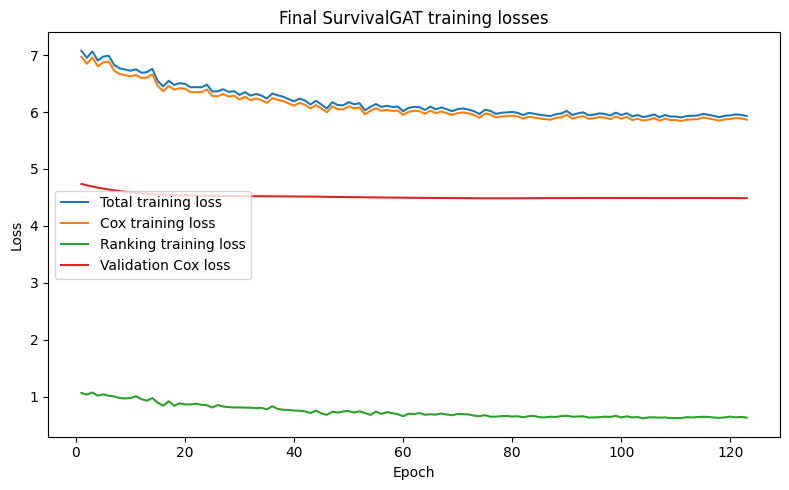

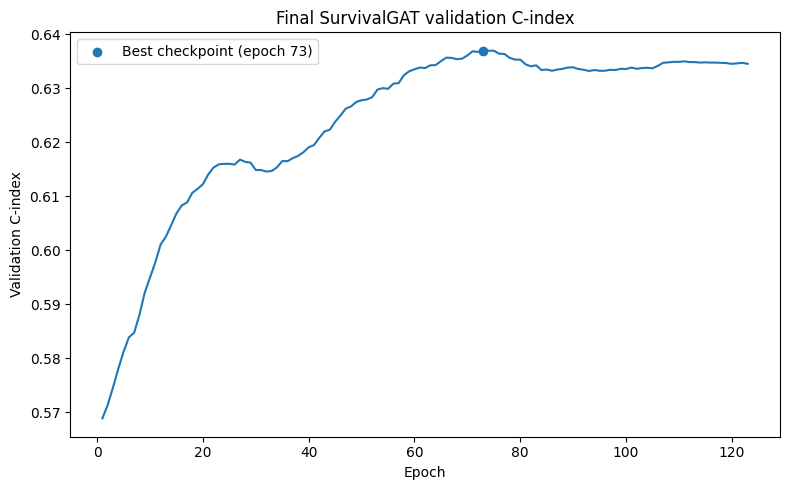

Final artifacts saved successfully.
Predictions: /kaggle/working/gat_survival_results/predictions.csv
Model: /kaggle/working/gat_survival_results/artifacts/final_survival_gat.pt
Preprocessor: /kaggle/working/gat_survival_results/artifacts/final_preprocessor.joblib


In [ ]:
# ============================================================
# Final predictions, survival probabilities, artifacts and plots
# ============================================================

all_indices = np.arange(
    len(analysis_df),
    dtype=np.int64,
)

if patient_id_col is not None:
    patient_ids = (
        analysis_df[
            patient_id_col
        ]
        .astype(str)
        .to_numpy()
    )
else:
    patient_ids = all_indices.astype(
        str
    )


def mask_to_numpy(
    mask: Any,
) -> np.ndarray:
    if isinstance(
        mask,
        torch.Tensor,
    ):
        return (
            mask
            .detach()
            .cpu()
            .numpy()
            .astype(bool)
        )

    return np.asarray(
        mask,
        dtype=bool,
    )


final_train_mask_numpy = mask_to_numpy(
    final_train_mask
)

final_validation_mask_numpy = mask_to_numpy(
    final_validation_mask
)


if (
    len(final_risk)
    != len(analysis_df)
):
    raise RuntimeError(
        "final_risk does not contain one score per patient."
    )


if not np.isfinite(
    final_risk
).all():
    raise ValueError(
        "Final risk scores contain NaN or infinite values."
    )


risk_horizons = np.asarray(
    CONFIG[
        "risk_horizons_months"
    ],
    dtype=np.float64,
)


final_survival_probabilities = (
    cox_survival_probabilities_with_training_reference(
        training_times=times_all[
            final_train_mask_numpy
        ],
        training_events=events_all[
            final_train_mask_numpy
        ],
        training_risks=final_risk[
            final_train_mask_numpy
        ],
        evaluation_risks=final_risk,
        horizons=risk_horizons,
    )
)


# ============================================================
# Breslow reference artifacts using the same training offset
# ============================================================

final_training_risk_offset = float(
    np.max(
        final_risk[
            final_train_mask_numpy
        ]
    )
)

centered_final_training_risk = (
    final_risk[
        final_train_mask_numpy
    ]
    - final_training_risk_offset
)

(
    final_breslow_event_times,
    final_breslow_cumulative_hazard,
) = breslow(
    times_all[
        final_train_mask_numpy
    ],
    events_all[
        final_train_mask_numpy
    ],
    centered_final_training_risk,
)


# ============================================================
# Final prediction table
# ============================================================

final_split_labels = np.full(
    len(analysis_df),
    "validation",
    dtype=object,
)

final_split_labels[
    final_train_mask_numpy
] = "train"


final_predictions = pd.DataFrame(
    {
        "row_index": all_indices,
        "original_row_index": (
            analysis_df[
                "original_row_index"
            ].to_numpy()
        ),
        "patient_id": patient_ids,
        "survival_time": times_all,
        "event": events_all,
        "risk_score": final_risk,
        "split": final_split_labels,
    }
)


for horizon_index, horizon in enumerate(
    risk_horizons
):
    horizon_key = int(
        round(float(horizon))
    )

    final_predictions[
        f"survival_probability_{horizon_key}m"
    ] = final_survival_probabilities[
        :,
        horizon_index,
    ]


final_predictions.to_csv(
    OUT / "predictions.csv",
    index=False,
)


final_predictions[
    [
        "patient_id",
        "risk_score",
        "split",
    ]
].to_csv(
    OUT / "risk_scores.csv",
    index=False,
)


# ============================================================
# Feature metadata
# ============================================================

pd.DataFrame(
    {
        "node_feature_name": (
            final_preprocessor
            .node_names
        )
    }
).to_csv(
    ART / "node_feature_names.csv",
    index=False,
)


pd.DataFrame(
    {
        "graph_feature_name": (
            final_preprocessor
            .graph_names
        )
    }
).to_csv(
    ART / "graph_feature_names.csv",
    index=False,
)


pd.DataFrame(
    {
        "edge_feature_name": (
            final_edge_feature_names
        )
    }
).to_csv(
    ART / "edge_feature_names.csv",
    index=False,
)


pd.DataFrame(
    {
        "selected_gene": (
            final_preprocessor
            .expr
            .names
        )
    }
).to_csv(
    ART / "selected_genes.csv",
    index=False,
)


pd.DataFrame(
    {
        "selected_graph_gene": (
            final_preprocessor
            .graph_expr
            .names
        )
    }
).to_csv(
    ART / "selected_graph_genes.csv",
    index=False,
)


pd.DataFrame(
    {
        "selected_mutation": (
            final_preprocessor
            .mutation
            .columns
        )
    }
).to_csv(
    ART / "selected_mutations.csv",
    index=False,
)


final_preprocessor.pathway_metadata.to_csv(
    ART / "pathway_scores_metadata.csv",
    index=False,
)


final_graph_diagnostics.to_csv(
    OUT / "final_graph_diagnostics.csv",
    index=False,
)


# ============================================================
# Save preprocessing and graph artifacts
# ============================================================

joblib.dump(
    final_preprocessor,
    ART / "preprocessors.joblib",
)


joblib.dump(
    final_preprocessor,
    ART / "final_preprocessor.joblib",
)


np.save(
    ART / "reference_X_node.npy",
    final_matrices[
        "X_node"
    ],
)


reference_graph_matrix = np.concatenate(
    [
        final_matrices[
            "X_graph_clinical"
        ],
        final_matrices[
            "X_graph_expression"
        ],
        final_matrices[
            "X_graph_pathway"
        ],
    ],
    axis=1,
)


np.save(
    ART / "reference_X_graph.npy",
    reference_graph_matrix,
)


np.save(
    ART / "reference_X_graph_clinical.npy",
    final_matrices[
        "X_graph_clinical"
    ],
)


np.save(
    ART / "reference_X_graph_expression.npy",
    final_matrices[
        "X_graph_expression"
    ],
)


np.save(
    ART / "reference_X_graph_pathway.npy",
    final_matrices[
        "X_graph_pathway"
    ],
)


np.save(
    ART / "edge_index.npy",
    final_edge_index,
)


np.save(
    ART / "edge_attr.npy",
    final_edge_attr,
)


np.save(
    ART / "reference_risk_scores.npy",
    final_risk,
)


np.save(
    ART / "breslow_event_times.npy",
    final_breslow_event_times,
)


np.save(
    ART / "breslow_cumulative_hazard.npy",
    final_breslow_cumulative_hazard,
)


np.save(
    ART / "breslow_risk_offset.npy",
    np.asarray(
        [
            final_training_risk_offset
        ],
        dtype=np.float64,
    ),
)


patient_metadata_columns = [
    column
    for column in [
        patient_id_col,
        "original_row_index",
        "survival_time",
        "event",
    ]
    if (
        column is not None
        and column
        in analysis_df.columns
    )
]


analysis_df[
    patient_metadata_columns
].to_csv(
    ART / "patient_metadata.csv",
    index=False,
)


# ============================================================
# Save complete final model checkpoint
# ============================================================

final_model_cpu = (
    final_model
    .cpu()
    .eval()
)


final_model_checkpoint = {
    "model_state_dict": copy.deepcopy(
        final_model_cpu.state_dict()
    ),
    "in_channels": int(
        final_matrices[
            "X_node"
        ].shape[1]
    ),
    "edge_dim": int(
        final_edge_attr.shape[1]
    ),
    "edge_feature_names": list(
        final_edge_feature_names
    ),
    "modality_slices": (
        final_preprocessor
        .modality_slices
    ),
    "hidden_channels": int(
        CONFIG[
            "hidden_channels"
        ]
    ),
    "heads": int(
        CONFIG[
            "gat_heads"
        ]
    ),
    "dropout": float(
        CONFIG[
            "dropout"
        ]
    ),
    "initial_residual_scale": float(
        CONFIG[
            "initial_residual_scale"
        ]
    ),
    "best_epoch": int(
        final_training.best_epoch
    ),
    "best_validation_c_index": float(
        final_training.best_c
    ),
    "training_risk_offset": float(
        final_training_risk_offset
    ),
    "risk_horizons_months": (
        risk_horizons.tolist()
    ),
    "config": copy.deepcopy(
        CONFIG
    ),
}


torch.save(
    final_model_checkpoint,
    ART / "final_survival_gat.pt",
)


torch.save(
    final_model_checkpoint,
    CHECKPOINTS
    / "final_survival_gat_complete.pt",
)


# ============================================================
# Save training history
# ============================================================

final_training_history = (
    final_training
    .history
    .copy()
)


final_training_history.to_csv(
    OUT / "training_history.csv",
    index=False,
)


# ============================================================
# Final training-loss plot
# ============================================================

plt.figure(
    figsize=(8, 5)
)


if (
    "total_training_loss"
    in final_training_history.columns
):
    plt.plot(
        final_training_history[
            "epoch"
        ],
        final_training_history[
            "total_training_loss"
        ],
        label="Total training loss",
    )


if (
    "cox_training_loss"
    in final_training_history.columns
):
    plt.plot(
        final_training_history[
            "epoch"
        ],
        final_training_history[
            "cox_training_loss"
        ],
        label="Cox training loss",
    )


if (
    "ranking_training_loss"
    in final_training_history.columns
):
    plt.plot(
        final_training_history[
            "epoch"
        ],
        final_training_history[
            "ranking_training_loss"
        ],
        label="Ranking training loss",
    )


if (
    "validation_loss"
    in final_training_history.columns
):
    plt.plot(
        final_training_history[
            "epoch"
        ],
        final_training_history[
            "validation_loss"
        ],
        label="Validation Cox loss",
    )


plt.xlabel(
    "Epoch"
)

plt.ylabel(
    "Loss"
)

plt.title(
    "Final SurvivalGAT training losses"
)

plt.legend()

plt.tight_layout()

savefig(
    "final_training_loss.png"
)


# ============================================================
# Final validation C-index plot
# ============================================================

plt.figure(
    figsize=(8, 5)
)

plt.plot(
    final_training_history[
        "epoch"
    ],
    final_training_history[
        "validation_c_index"
    ],
)

if (
    final_training.best_epoch
    in final_training_history[
        "epoch"
    ].values
):
    best_history_row = (
        final_training_history.loc[
            final_training_history[
                "epoch"
            ]
            == final_training.best_epoch
        ]
        .iloc[0]
    )

    if np.isfinite(
        best_history_row[
            "validation_c_index"
        ]
    ):
        plt.scatter(
            [
                final_training.best_epoch
            ],
            [
                best_history_row[
                    "validation_c_index"
                ]
            ],
            label=(
                "Best checkpoint "
                f"(epoch {final_training.best_epoch})"
            ),
        )

        plt.legend()


plt.xlabel(
    "Epoch"
)

plt.ylabel(
    "Validation C-index"
)

plt.title(
    "Final SurvivalGAT validation C-index"
)

plt.tight_layout()

savefig(
    "final_validation_c_index.png"
)


print(
    "Final artifacts saved successfully."
)

print(
    "Predictions:",
    OUT / "predictions.csv",
)

print(
    "Model:",
    ART / "final_survival_gat.pt",
)

print(
    "Preprocessor:",
    ART / "final_preprocessor.joblib",
)

## 31. Final attention export

## 32. Artifact reload test

In [ ]:
# ============================================================
# Attention export and complete reload consistency test
# ============================================================

final_model_for_attention = (
    final_model
    .cpu()
    .eval()
)

final_data_for_attention = (
    final_data
    .cpu()
)


final_attention = attention_table(
    final_model_for_attention,
    final_data_for_attention,
)


if not isinstance(
    final_attention,
    pd.DataFrame,
):
    raise TypeError(
        "attention_table() must return a pandas DataFrame."
    )


required_attention_columns = {
    "attention_weight",
}

missing_attention_columns = (
    required_attention_columns
    - set(final_attention.columns)
)

if missing_attention_columns:
    raise KeyError(
        "Attention table is missing columns: "
        f"{sorted(missing_attention_columns)}"
    )


final_attention.to_csv(
    OUT / "attention_weights.csv",
    index=False,
)


display(
    final_attention.nlargest(
        20,
        "attention_weight",
    )
)


# ============================================================
# Reload saved preprocessor, graph artifacts and model
# ============================================================

reloaded_preprocessor = joblib.load(
    ART / "preprocessors.joblib"
)


try:
    checkpoint = torch.load(
        ART / "final_survival_gat.pt",
        map_location=DEVICE,
        weights_only=False,
    )
except TypeError:
    checkpoint = torch.load(
        ART / "final_survival_gat.pt",
        map_location=DEVICE,
    )


reference_X_node = np.load(
    ART / "reference_X_node.npy"
).astype(
    np.float32
)


reference_edge_index = np.load(
    ART / "edge_index.npy"
).astype(
    np.int64
)


reference_edge_attr = np.load(
    ART / "edge_attr.npy"
).astype(
    np.float32
)


reference_risk_scores = np.load(
    ART / "reference_risk_scores.npy"
).astype(
    np.float64
)


# ============================================================
# Validate saved artifacts before rebuilding the model
# ============================================================

if reference_X_node.ndim != 2:
    raise ValueError(
        "reference_X_node.npy must be a 2D matrix."
    )


if (
    reference_edge_index.ndim != 2
    or reference_edge_index.shape[0] != 2
):
    raise ValueError(
        "edge_index.npy must have shape [2, number_of_edges]."
    )


if reference_edge_attr.ndim == 1:
    reference_edge_attr = (
        reference_edge_attr
        .reshape(-1, 1)
    )


if reference_edge_attr.ndim != 2:
    raise ValueError(
        "edge_attr.npy must be a 2D matrix."
    )


if (
    reference_edge_attr.shape[0]
    != reference_edge_index.shape[1]
):
    raise ValueError(
        "edge_attr rows must match the number of graph edges."
    )


if (
    reference_X_node.shape[0]
    != len(reference_risk_scores)
):
    raise ValueError(
        "The number of saved patients does not match "
        "the number of reference risk scores."
    )


if not np.isfinite(
    reference_X_node
).all():
    raise ValueError(
        "reference_X_node contains non-finite values."
    )


if not np.isfinite(
    reference_edge_attr
).all():
    raise ValueError(
        "reference_edge_attr contains non-finite values."
    )


if not np.isfinite(
    reference_risk_scores
).all():
    raise ValueError(
        "reference_risk_scores contains non-finite values."
    )


if int(
    checkpoint["in_channels"]
) != reference_X_node.shape[1]:
    raise RuntimeError(
        "Checkpoint in_channels does not match "
        "reference_X_node."
    )


if int(
    checkpoint["edge_dim"]
) != reference_edge_attr.shape[1]:
    raise RuntimeError(
        "Checkpoint edge_dim does not match "
        "reference_edge_attr."
    )


if (
    len(
        reloaded_preprocessor.node_names
    )
    != reference_X_node.shape[1]
):
    raise RuntimeError(
        "The saved preprocessor node feature names "
        "do not match reference_X_node."
    )


checkpoint_edge_feature_names = (
    checkpoint.get(
        "edge_feature_names",
        [],
    )
)


if (
    checkpoint_edge_feature_names
    and len(
        checkpoint_edge_feature_names
    )
    != reference_edge_attr.shape[1]
):
    raise RuntimeError(
        "The number of saved edge feature names "
        "does not match edge_attr width."
    )


# ============================================================
# Rebuild the exact SurvivalGAT architecture
# ============================================================

reloaded_model = SurvivalGAT(
    in_channels=int(
        checkpoint["in_channels"]
    ),
    hidden=int(
        checkpoint["hidden_channels"]
    ),
    heads=int(
        checkpoint["heads"]
    ),
    dropout=float(
        checkpoint["dropout"]
    ),
    residual_scale=float(
        checkpoint[
            "initial_residual_scale"
        ]
    ),
    edge_dim=int(
        checkpoint["edge_dim"]
    ),
    modality_slices=checkpoint.get(
        "modality_slices"
    ),
).to(
    DEVICE
)


reloaded_model.load_state_dict(
    checkpoint[
        "model_state_dict"
    ]
)


reloaded_model.eval()


# ============================================================
# Reproduce risk scores from saved artifacts
# ============================================================

reference_X_tensor = torch.as_tensor(
    reference_X_node,
    dtype=torch.float32,
    device=DEVICE,
)


reference_edge_index_tensor = (
    torch.as_tensor(
        reference_edge_index,
        dtype=torch.long,
        device=DEVICE,
    )
)


reference_edge_attr_tensor = (
    torch.as_tensor(
        reference_edge_attr,
        dtype=torch.float32,
        device=DEVICE,
    )
)


with torch.no_grad():
    reloaded_risk_scores = (
        reloaded_model(
            reference_X_tensor,
            reference_edge_index_tensor,
            reference_edge_attr_tensor,
        )
        .detach()
        .cpu()
        .numpy()
        .astype(np.float64)
    )


if reloaded_risk_scores.shape != reference_risk_scores.shape:
    raise RuntimeError(
        "Reloaded and reference risk scores "
        "have different shapes."
    )


maximum_absolute_difference = float(
    np.max(
        np.abs(
            reloaded_risk_scores
            - reference_risk_scores
        )
    )
)


if not np.allclose(
    reloaded_risk_scores,
    reference_risk_scores,
    rtol=1e-5,
    atol=1e-6,
):
    raise AssertionError(
        "Reloaded model predictions do not match "
        "the saved reference predictions. "
        f"Maximum absolute difference: "
        f"{maximum_absolute_difference:.10f}"
    )


print(
    "Reload test passed."
)

print(
    "Maximum absolute difference:",
    maximum_absolute_difference,
)

print(
    "Node feature count:",
    reference_X_node.shape[1],
)

print(
    "Edge feature count:",
    reference_edge_attr.shape[1],
)

print(
    "Number of graph edges:",
    reference_edge_index.shape[1],
)


reloaded_model = (
    reloaded_model
    .cpu()
)


del reference_X_tensor
del reference_edge_index_tensor
del reference_edge_attr_tensor


if DEVICE.type == "cuda":
    torch.cuda.empty_cache()

,source_node,target_node,source_patient_id,target_patient_id,edge_similarity,attention_weight,source_event,target_event,source_risk_score,target_risk_score
22,4,4,8,8,NaN,1.0,0,0,0.617256,0.617256
42,8,8,28,28,NaN,1.0,0,0,0.329679,0.329679
43,9,9,35,35,NaN,1.0,0,0,-0.184269,-0.184269
44,10,10,36,36,NaN,1.0,0,0,0.675219,0.675219
51,13,13,46,46,NaN,1.0,0,0,0.743070,0.743070
99,22,22,66,66,NaN,1.0,1,1,0.519709,0.519709
132,29,29,97,97,NaN,1.0,1,1,0.145230,0.145230
152,36,36,109,109,NaN,1.0,0,0,0.113270,0.113270
156,38,38,112,112,NaN,1.0,0,0,0.191212,0.191212
157,39,39,113,113,NaN,1.0,1,1,0.636718,0.636718


Reload test passed.
Maximum absolute difference: 0.0
Node feature count: 188
Edge feature count: 6
Number of graph edges: 4879


## 33. Artifact manifest

## 34. Secondary cancer-specific analysis availability

In [ ]:
# ============================================================
# Artifact manifest and cancer-specific endpoint audit
# ============================================================

manifest_records: List[
    Dict[str, Any]
] = []


for artifact_path in sorted(
    OUT.rglob("*")
):
    if not artifact_path.is_file():
        continue

    try:
        relative_path = str(
            artifact_path.relative_to(
                OUT
            )
        )

        file_size = int(
            artifact_path
            .stat()
            .st_size
        )

        modified_time = pd.Timestamp(
            artifact_path
            .stat()
            .st_mtime,
            unit="s",
        )

        manifest_records.append(
            {
                "relative_path": relative_path,
                "file_name": (
                    artifact_path.name
                ),
                "parent_directory": str(
                    artifact_path
                    .parent
                    .relative_to(
                        OUT
                    )
                ),
                "size_bytes": file_size,
                "size_kb": (
                    file_size / 1024.0
                ),
                "suffix": (
                    artifact_path
                    .suffix
                    .lower()
                ),
                "modified_time": (
                    modified_time
                ),
            }
        )

    except OSError as error:
        print(
            "[WARNING] Could not inspect artifact:",
            artifact_path,
            error,
        )


manifest = pd.DataFrame(
    manifest_records,
    columns=[
        "relative_path",
        "file_name",
        "parent_directory",
        "size_bytes",
        "size_kb",
        "suffix",
        "modified_time",
    ],
)


if not manifest.empty:
    manifest = (
        manifest
        .sort_values(
            [
                "parent_directory",
                "relative_path",
            ]
        )
        .reset_index(
            drop=True
        )
    )


manifest_path = (
    OUT / "artifact_manifest.csv"
)


manifest.to_csv(
    manifest_path,
    index=False,
)


manifest_summary = pd.DataFrame(
    [
        {
            "n_files": int(
                len(manifest)
            ),
            "total_size_bytes": int(
                manifest[
                    "size_bytes"
                ].sum()
            )
            if not manifest.empty
            else 0,
            "total_size_mb": float(
                manifest[
                    "size_bytes"
                ].sum()
                / (
                    1024.0 ** 2
                )
            )
            if not manifest.empty
            else 0.0,
            "output_directory": str(
                OUT
            ),
        }
    ]
)


manifest_summary.to_csv(
    OUT / "artifact_manifest_summary.csv",
    index=False,
)


display(
    manifest
)

display(
    manifest_summary
)


# ============================================================
# Cancer-specific endpoint audit
# ============================================================

cancer_specific_audit: Dict[
    str,
    Any
] = {
    "cancer_specific_event_column_detected": (
        cancer_event_col
        is not None
    ),
    "source_column": (
        cancer_event_col
    ),
    "primary_endpoint": (
        "overall_survival"
    ),
    "analysis_performed": False,
}


if cancer_event_col is None:
    print(
        "No reliable cancer-specific event column was detected."
    )

    print(
        "No cancer-specific outcomes were inferred or invented."
    )

    print(
        "Overall survival remains the primary endpoint."
    )

else:
    if (
        "cancer_specific_event"
        not in analysis_df.columns
    ):
        raise KeyError(
            "A cancer-specific event source column was detected, "
            "but analysis_df does not contain "
            "'cancer_specific_event'."
        )

    cancer_specific_events = pd.to_numeric(
        analysis_df[
            "cancer_specific_event"
        ],
        errors="coerce",
    )

    valid_cancer_specific_events = (
        cancer_specific_events.dropna()
    )

    unexpected_values = sorted(
        set(
            valid_cancer_specific_events
            .unique()
            .tolist()
        )
        - {
            0,
            1,
            0.0,
            1.0,
        }
    )

    if unexpected_values:
        raise ValueError(
            "cancer_specific_event contains unexpected values: "
            f"{unexpected_values}"
        )

    event_counts = (
        cancer_specific_events
        .value_counts(
            dropna=False
        )
        .rename_axis(
            "cancer_specific_event"
        )
        .reset_index(
            name="count"
        )
    )

    n_available = int(
        cancer_specific_events
        .notna()
        .sum()
    )

    n_missing = int(
        cancer_specific_events
        .isna()
        .sum()
    )

    n_cancer_specific_events = int(
        (
            cancer_specific_events
            == 1
        ).sum()
    )

    n_no_cancer_specific_event = int(
        (
            cancer_specific_events
            == 0
        ).sum()
    )

    cancer_specific_audit.update(
        {
            "analysis_performed": True,
            "n_patients": int(
                len(analysis_df)
            ),
            "n_available": n_available,
            "n_missing": n_missing,
            "n_cancer_specific_events": (
                n_cancer_specific_events
            ),
            "n_without_cancer_specific_event": (
                n_no_cancer_specific_event
            ),
            "event_rate_among_available": (
                float(
                    n_cancer_specific_events
                    / n_available
                )
                if n_available > 0
                else np.nan
            ),
        }
    )

    event_counts.to_csv(
        OUT
        / "cancer_specific_event_counts.csv",
        index=False,
    )

    print(
        "Cancer-specific event source column:",
        cancer_event_col,
    )

    display(
        event_counts
    )

    print(
        "Cancer-specific events:",
        n_cancer_specific_events,
    )

    print(
        "Available cancer-specific labels:",
        n_available,
    )

    print(
        "Missing cancer-specific labels:",
        n_missing,
    )

    print(
        "Overall survival remains the primary endpoint."
    )

    print(
        "For a future cause-specific Cox analysis, "
        "deaths from other causes should generally be censored "
        "at their observed death time."
    )

    print(
        "For cumulative-incidence estimation, competing-risk "
        "methods such as Fine-Gray or Aalen-Johansen are required."
    )


cancer_specific_audit_path = (
    OUT
    / "cancer_specific_endpoint_audit.json"
)


with cancer_specific_audit_path.open(
    mode="w",
    encoding="utf-8",
) as file:
    json.dump(
        cancer_specific_audit,
        file,
        indent=2,
        ensure_ascii=False,
        default=lambda value: (
            None
            if pd.isna(value)
            else value
        ),
    )


print(
    "Artifact manifest saved to:",
    manifest_path,
)

print(
    "Cancer-specific endpoint audit saved to:",
    cancer_specific_audit_path,
)

,relative_path,file_name,parent_directory,size_bytes,size_kb,suffix,modified_time
0,ablation_results.csv,ablation_results.csv,.,3200,3.125000,.csv,2026-07-14 12:03:17.082392454
1,ablation_summary.csv,ablation_summary.csv,.,975,0.952148,.csv,2026-07-14 12:03:17.082392454
2,artifact_manifest.csv,artifact_manifest.csv,.,2934,2.865234,.csv,2026-07-14 10:19:40.415810347
3,attention_weights.csv,attention_weights.csv,.,268621,262.325195,.csv,2026-07-14 12:06:31.145830870
4,calibration_120m.csv,calibration_120m.csv,.,245,0.239258,.csv,2026-07-14 10:18:31.680634260
...,...,...,...,...,...,...,...
89,plots/eda_tumor_size.png,eda_tumor_size.png,plots,28448,27.781250,.png,2026-07-14 11:26:47.751664400
90,plots/final_training_loss.png,final_training_loss.png,plots,84541,82.559570,.png,2026-07-14 12:05:58.585905075
91,plots/final_validation_c_index.png,final_validation_c_index.png,plots,70893,69.231445,.png,2026-07-14 12:05:59.004942656
92,plots/high_risk_attention_subgraph.png,high_risk_attention_subgraph.png,plots,433164,423.011719,.png,2026-07-14 10:18:33.498797655


,n_files,total_size_bytes,total_size_mb,output_directory
0,94,6538531,6.235629,/kaggle/working/gat_survival_results


Cancer-specific event source column: death_from_cancer


,cancer_specific_event,count
0,0.0,1280
1,1.0,622
2,NaN,1


Cancer-specific events: 622
Available cancer-specific labels: 1902
Missing cancer-specific labels: 1
Overall survival remains the primary endpoint.
For a future cause-specific Cox analysis, deaths from other causes should generally be censored at their observed death time.
For cumulative-incidence estimation, competing-risk methods such as Fine-Gray or Aalen-Johansen are required.
Artifact manifest saved to: /kaggle/working/gat_survival_results/artifact_manifest.csv
Cancer-specific endpoint audit saved to: /kaggle/working/gat_survival_results/cancer_specific_endpoint_audit.json


## 35. Final Scientific Conclusion

**OncoGraph-Surv** should be considered a research prototype for multimodal survival-risk stratification rather than a clinically deployable prediction system.

Using clinical, transcriptomic, mutation, copy-number and pathway-level information from the retrospective METABRIC cohort, the workflow demonstrated that multimodal molecular features provide meaningful prognostic information beyond conventional clinical variables. The updated residual gated SurvivalGAT achieved a strict out-of-fold C-index of **0.6783**, showing moderate and relatively stable discrimination across cross-validation folds.

The ablation study remains essential for interpreting these results. The graph-based model outperformed the clinical-only baseline, confirming the value of multimodal integration. However, the full-feature MLP remained stronger than the current GAT configuration, indicating that most of the predictive signal is presently derived from patient-level features rather than from patient–patient message passing. The patient graph therefore contains potentially useful information, but its topology, similarity definition and graph-learning strategy require further optimization.

The reported out-of-fold metrics provide an estimate of internal generalization within METABRIC only. Because METABRIC is a retrospective cohort, the model must be evaluated on an independent external breast cancer cohort before any claim of clinical validity can be made. Differences in patient populations, expression platforms, preprocessing methods, treatment practices and follow-up distributions may substantially affect performance.

The predicted absolute survival probabilities are derived from a training-based Breslow baseline-hazard estimate. Although discrimination may remain acceptable, these probabilities may require recalibration before being transferred to another cohort or clinical setting. Calibration, Brier scores and time-dependent AUC should therefore be reassessed independently at each clinically relevant horizon.

Selected genes, mutations, CNA variables and pathways should be interpreted only as **candidate prognostic features associated with the model outcome**. Their repeated selection across folds may support robustness, but it does not establish biological causality, functional relevance or therapeutic actionability. Independent statistical validation and experimental investigation would be required before considering them validated biomarkers.

Similarly, attention coefficients describe how the trained neural network distributes information across patient–patient edges. They are model-specific quantities and must not be interpreted as causal relationships, biological interactions or direct measures of feature importance.

Any unexpectedly high discrimination result, particularly a large increase in time-dependent AUC or C-index, should trigger a renewed leakage audit. This audit should verify outcome-column exclusion, fold-specific preprocessing, survival-aware feature selection, graph construction, normalization, threshold selection and checkpoint selection.

The current findings support the feasibility of combining multimodal breast cancer data with censoring-aware graph learning. However, the most scientifically appropriate conclusion is that the graph provides useful modeling capacity but has not yet demonstrated superiority over a strong feature-matched multimodal MLP.

Future work should prioritize:

* systematic graph-topology optimization;
* modality-specific graph ablations;
* transfer learning from a strong multimodal encoder;
* progressive fine-tuning of the graph branch;
* robustness analysis across random seeds;
* external cohort validation;
* independent calibration assessment;
* subgroup and fairness analysis;
* comparison with established Cox and survival-ensemble baselines.

Until these steps are completed, the model should be used for methodological research and hypothesis generation only, not for clinical decision-making, diagnosis, treatment selection or individual patient counseling.
